# Default-Rate Driver Scan — Exploratory Data Analysis
### Flagship PD Model Project · Stage 1 (EDA)

> **Objective.** Identify and evidence the primary drivers of loan default in the Home Credit application data, and translate those findings into binning decisions (WOE / IV) that feed the downstream PD scorecard.

| Field | Detail |
|---|---|
| **Project** | Flagship PD Model — Project 1: Default-Rate Driver Scan |
| **Stage** | Stage 1 — Exploratory Data Analysis |
| **Dataset** | Home Credit Default Risk — `application_train` (primary table) |
| **Target** | `TARGET` (1 = default / serious delinquency, 0 = repaid) |
| **Author** | *&lt;your name&gt;* |
| **Date started / last updated** | *&lt;YYYY-MM-DD&gt;* / *&lt;YYYY-MM-DD&gt;* |
| **Notebook version** | *&lt;v0.x — draft&gt;* |

**Reading guide — the E / O / D convention.** Each analysis block is written as three linked notes so a reviewer can follow the reasoning end to end:
- **Explanation** — the hypothesis / business rationale *before* looking at the data (what we expect and why).
- **Observation** — what the data actually showed, read straight off the output above.
- **Decision** — the action taken and its justification (binning strategy, keep / drop, treatment carried into Section 5).

**Reproducibility.** *(placeholder — record Python version, key library versions, random seed(s), the data snapshot/date, and any manual steps needed to re-run this notebook top-to-bottom.)*


## Contents

- **Project Setup** — environment & imports, display settings, style guide, data loading
- **1. First Look** — data shape, class imbalance, description lookup reference
- **2. Data Quality & Missingness** — statistical subsets · thematic subsets · missingness assessment · cardinality assessment
- **3. Feature Analysis** — per-family univariate + bivariate scan (External Scores · Loan Financials · Age & Employment · Demographics · Other Numericals)
- **4. Feature Engineering** — candidate credit ratios · bivariate sanity check
- **5. WOE / IV Computation** — split & binning inputs · WOE/IV helper · IV ranking · top drivers · WOE encoding · optbinning cross-check
- **6. Findings Summary** — consolidated drivers and data-quality conclusions
- **7. Next Steps** — actions carried into modelling
- **8. Assumptions, Limitations & Data Lineage** — caveats and reproducibility record

*(placeholder — once section numbering is final, these can be converted to in-notebook anchor links.)*


# Project Setup

## Environment and Imports

In [1]:
# ════════════════════════════════
# Environment Setup
# ════════════════════════════════

# ── Standard Library ────────────────────
import os
import sys
import warnings
import math


# ── Data ──────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from matplotlib import cm, colors

# ── Machine Learning (only needed once you start modelling) ──
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Jupyter ───────────────────────
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display




def find_repo_root(start, repo_name='CreditRiskLearning'):
    path = os.path.abspath(start)
    while True:
        if os.path.basename(path) == repo_name:
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(f"Could not find repo root: {repo_name}")
        path = parent


repo_root = find_repo_root(os.getcwd())
sys.path.append(os.path.join(repo_root, 'Core Resources'))
sys.path.append(os.path.join(repo_root, 'Core Resources', 'Scripts'))

from python_style_util import (
    palette, fonts, sizes,
    p, f, s,
    C, Shade, Size,
    set_style,
    gradient, traffic_light, diverging, diverging_cmap,
    multi_series, binary_palette,
    chart_title, annotate, style_df,
    show_palette, show_fonts, show_tokens, show_colormaps, show_style_guide,
)
import evaluation_utils as eu
import missingno as msno        # missingness assessment functions

# ── Project toolkit (Core Resources/credit_utils) ──────────────
# Auto-reload so edits to the util modules appear without a kernel restart.
%load_ext autoreload
%autoreload 2

# Namespaced import: reach any function as module.func (e.g. eda.histogram_per_group).
# Functions we add to these modules later are picked up here automatically.
from credit_utils import eda, quality, woe, stats, style

# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Display Settings

In [2]:
# --- Pandas ---
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places on floats
pd.set_option('display.max_columns', None)              # show all columns
pd.set_option('display.max_rows', 100)                  # show up to 100 rows
pd.set_option('display.width', None)                    # don't wrap wide dataframes
pd.set_option('display.colheader_justify', 'left')      # left-align column headers
pd.set_option('display.precision', 4)                   # decimal precision for describe()
pd.set_option('display.large_repr', 'truncate')         # truncate instead of summary for large dfs

# --- NumPy ---
np.set_printoptions(
    precision=4,        # decimal places
    suppress=True,      # no scientific notation
    linewidth=120,      # wrap width
    threshold=1000,     # show up to 1000 elements before summarising with ...
    edgeitems=5,        # show 5 items at each end when it does summarise
)

# --- Matplotlib ---
%matplotlib inline
plt.rcParams['figure.dpi'] = 120             # sharper figures
plt.rcParams['savefig.dpi'] = 150            # higher res when saving
plt.rcParams['savefig.bbox'] = 'tight'       # no clipped labels when saving
plt.rcParams['savefig.facecolor'] = 'white'  # white background on saved figures

# --- Jupyter ---
InteractiveShell.ast_node_interactivity = 'all'  # print every expression, not just the last

# --- Warnings ---
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# --- Style ---
set_style()

## Style Guide

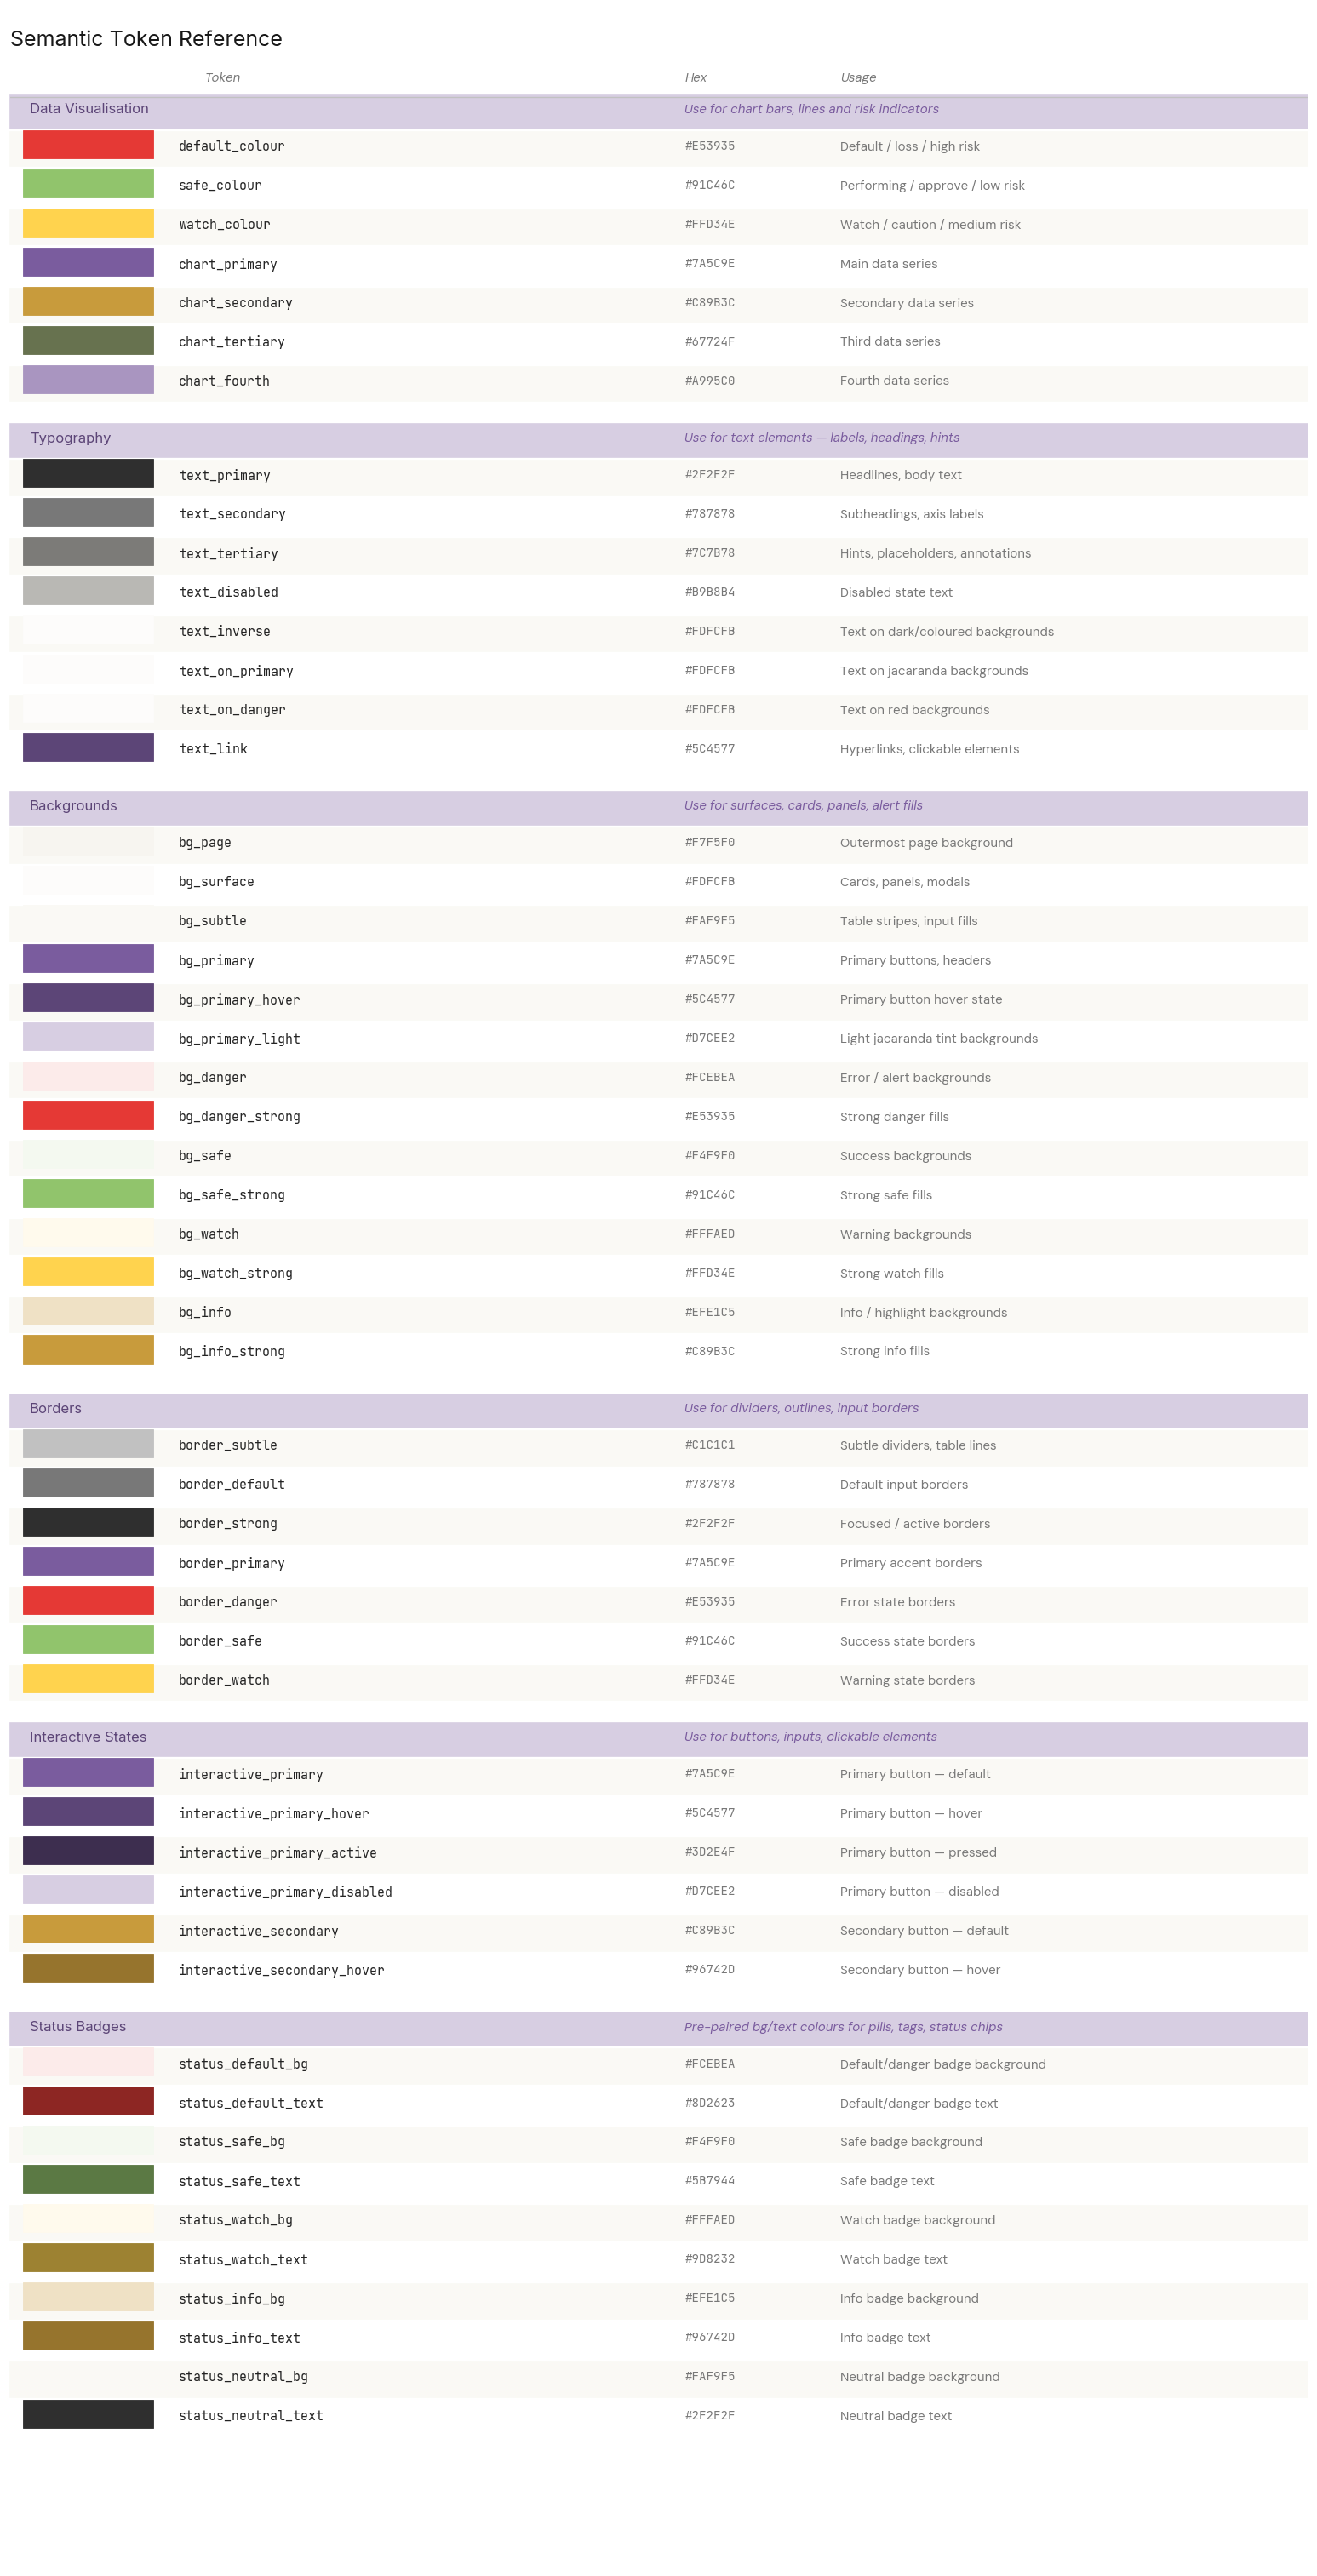

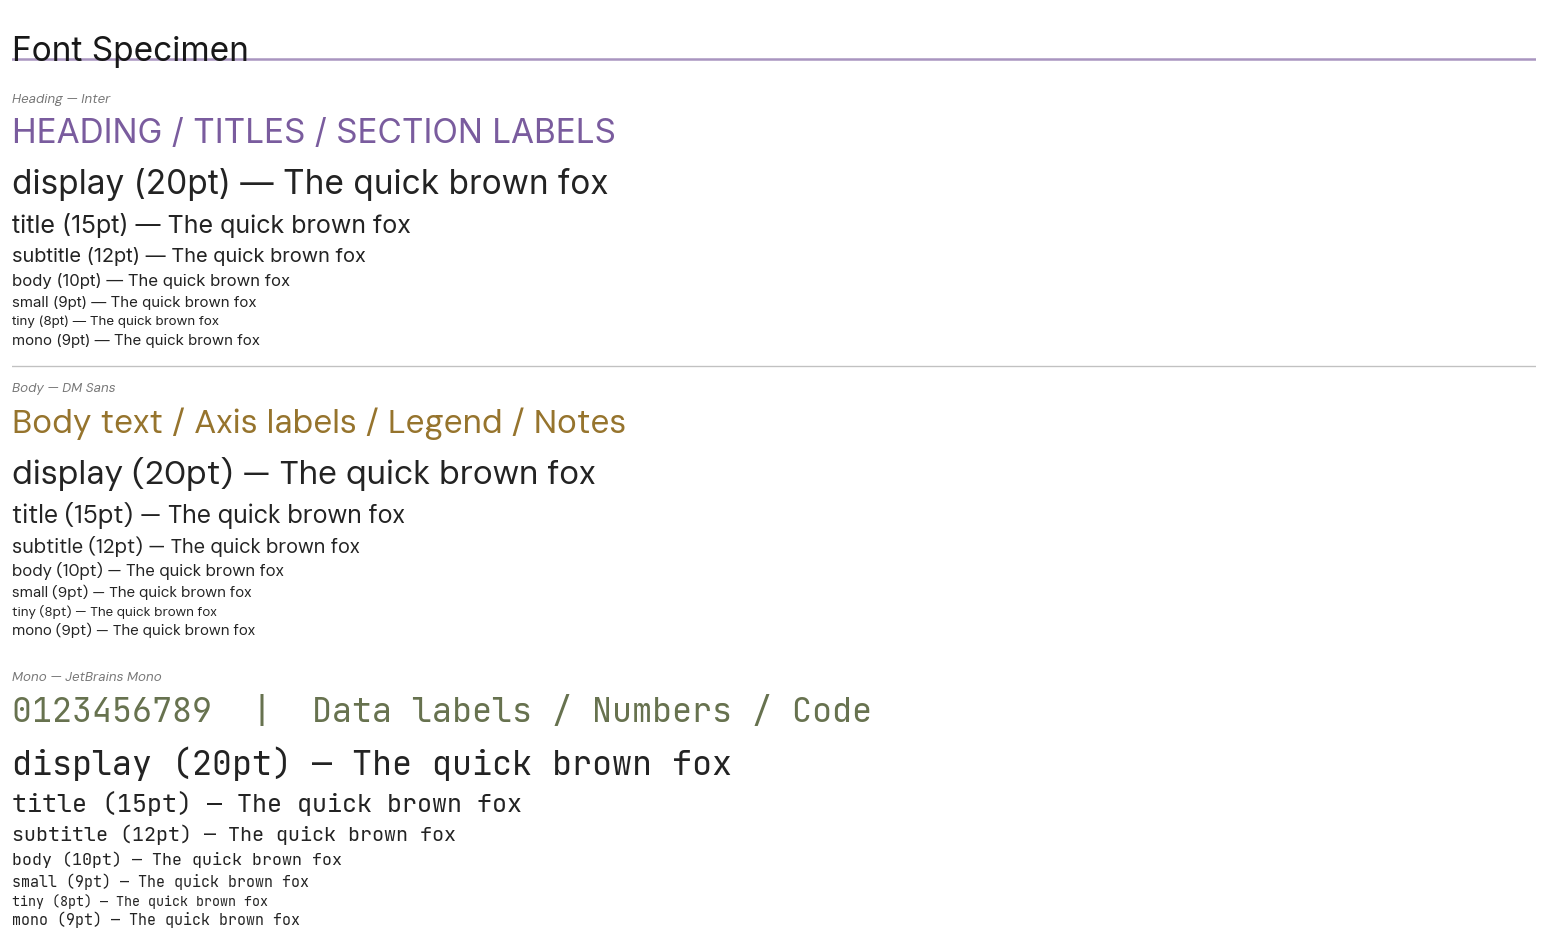

In [3]:
# Quick visual reference for the project's colour tokens and fonts
show_tokens()
show_fonts()

## Data Loading

In [4]:
# repo_root is defined in the Environment cell above.
# Point DATA_PATH at your dataset inside the Datasets folder.
DATA_PATH = os.path.join(repo_root, 'Datasets', 'Home Credit Default Risk', 'application_train.csv')

df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns from {DATA_PATH}")
df.head()

desc = pd.read_csv('../../../Datasets/Home Credit Default Risk/HomeCredit_columns_description.csv', sep=',', encoding='cp1252')

Loaded 307,511 rows × 122 columns from c:\Dev\CreditRiskLearning\Datasets\Home Credit Default Risk\application_train.csv


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.0

# Project Body

## 1. First Look

### Data Shape

**Explanation:** Expecting large dataset with significant breadth and volume 

In [5]:
df.shape

(307511, 122)

**Observation:** 300k+ Rows and 122 Columns. 

**Decision:** Will need to split into statistical categories and potentially similar buckets (i.e. applicant data, security data, social data) for further assessment as attempting look at this number of columns as a whole group will make it difficult to draw tangible conclusions.

### Class Imbalance

**Explanation:** Typically defaulters are a very small percentage of a mortgage loan book as the financial health of bank is reliant on this percentage staying low given the huge losses taken upon mortgage default.

In [6]:
# Percentage distribution

df["TARGET"].value_counts(normalize=True)

# Raw value counts

df['TARGET'].value_counts(dropna=False) 

TARGET
0   0.92
1   0.08
Name: proportion, dtype: float64

TARGET
0    282686
1     24825
Name: count, dtype: int64

**Observation:** 92% Non Defaulters vs 8% Defaulters

**Decision:** Non-Defaulters make up a large portion of the loan book as expected. An 8% default rate is high relative to a prime mortgage book, but this is Home Credit — a consumer-finance lender serving thin-file / underbanked borrowers — so ~8% is roughly the expected base rate for this segment rather than a sign of distress. It reflects the lender deliberately pricing in a riskier target market through rates/fees, and there are likely addressable applicant segments driving the rate, which this driver scan aims to surface.

No resampling will occur as this is purely a screening exercise, not model training. WOE/IV are computed on the full distribution, so class imbalance is a constraint to respect.

### Description Lookup Reference

A quick reference lookup for the description of what each of the columns represent. Useful in initial stages when assessing business relevance of each feature for unviariate analysis and feature selection.

In [7]:
# Filter to the application table first (Row repeats across the 7 source tables,
# so filtering before indexing avoids ambiguous/duplicate matches)
desc_app = desc[desc['Table'] == 'application_{train|test}.csv'].set_index('Row')

description_index = {}

for column in df.columns:
    if column in desc_app.index:
        description_index[column] = desc_app.loc[column, 'Description']
        
        
description_index['NAME_CONTRACT_TYPE']

'Identification if loan is cash or revolving'

## 2. Data Quality and Missingness

**Explanation:** Expecting large portion of data to be missing for various reasons, such as length of employment missing due to an applicant potentially being unemployed (MNAR). These types of missingness relationship will be established across variables by looking at cross-validation.

### 2.1 Statistical Subsets

Splitting data up into continuous, discrete, nominal, ordinal and binary subsets.

In [8]:
statistical_type_index = {}

nunique_counts = df.nunique()

for column in df.columns:
    
    n_unique = nunique_counts[column]
    
    dtype = df[column].dtype
    
    if n_unique == 2:
        statistical_type_index[column] = 'binary'
        
    elif n_unique > 50 and dtype in ['float64', 'int64']:
        statistical_type_index[column] = 'continuous'
    
    else:
        statistical_type_index[column] = 'needs review'
    
review_cols = [col for col, label in statistical_type_index.items() if label == 'needs review']

for col in review_cols:
    print(col, df[col].unique()[:10], description_index.get(col))
    

CODE_GENDER <ArrowStringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str Gender of the client
CNT_CHILDREN [0 1 2 3 4 7 5 6 8 9] Number of children the client has
NAME_TYPE_SUITE <ArrowStringArray>
[  'Unaccompanied',          'Family', 'Spouse, partner',        'Children',
         'Other_A',               nan,         'Other_B', 'Group of people']
Length: 8, dtype: str Who was accompanying client when he was applying for the loan
NAME_INCOME_TYPE <ArrowStringArray>
[             'Working',        'State servant', 'Commercial associate',
            'Pensioner',           'Unemployed',              'Student',
          'Businessman',      'Maternity leave']
Length: 8, dtype: str Clients income type (businessman, working, maternity leave,ï¿½)
NAME_EDUCATION_TYPE <ArrowStringArray>
['Secondary / secondary special',              'Higher education',
             'Incomplete higher',               'Lower secondary',
               'Academic degree']
Length: 5, dtype: str Level of highest edu

In [ ]:
# Fix up SK_ID_CURR - add as an 'id' column

statistical_type_index.update(dict.fromkeys(['SK_ID_CURR'], 'id'))

# CODE_GENDER

statistical_type_index.update(dict.fromkeys(['CODE_GENDER'], 'binary'))

# CNT_CHILDREN

statistical_type_index.update(dict.fromkeys(['CNT_CHILDREN'], 'discrete'))

# NAME_TYPE_SUITE

statistical_type_index.update(dict.fromkeys(['NAME_TYPE_SUITE'], 'categorical'))

# NAME_INCOME_TYPE

statistical_type_index.update(dict.fromkeys(['NAME_INCOME_TYPE'], 'categorical'))

# NAME_EDUCATION_TYPE

statistical_type_index.update(dict.fromkeys(['NAME_EDUCATION_TYPE'], 'categorical'))

# NAME_FAMILY_STATUS

statistical_type_index.update(dict.fromkeys(['NAME_FAMILY_STATUS'], 'categorical'))

# NAME_HOUSING_TYPE

statistical_type_index.update(dict.fromkeys(['NAME_HOUSING_TYPE'], 'categorical'))

# OCCUPATION_TYPE

statistical_type_index.update(dict.fromkeys(['OCCUPATION_TYPE'], 'categorical'))

# CNT_FAM_MEMBERS

statistical_type_index.update(dict.fromkeys(['CNT_FAM_MEMBERS'], 'discrete'))

# REGION_RATING_CLIENT

statistical_type_index.update(dict.fromkeys(['REGION_RATING_CLIENT'], 'ordinal'))

# REGION_RATING_CLIENT_W_CITY

statistical_type_index.update(dict.fromkeys(['REGION_RATING_CLIENT_W_CITY'], 'ordinal'))

# WEEKDAY_APPR_PROCESS_START

statistical_type_index.update(dict.fromkeys(['WEEKDAY_APPR_PROCESS_START'], 'categorical'))

# HOUR_APPR_PROCESS_START

statistical_type_index.update(dict.fromkeys(['HOUR_APPR_PROCESS_START'], 'categorical'))

# ORGANIZATION_TYPE

statistical_type_index.update(dict.fromkeys(['ORGANIZATION_TYPE'], 'categorical'))

# ELEVATORS_MODE

statistical_type_index.update(dict.fromkeys(['ELEVATORS_MODE'], 'continuous'))

# ENTRANCES_MODE	

statistical_type_index.update(dict.fromkeys(['ENTRANCES_MODE'], 'continuous'))

# FLOORSMAX_MODE

statistical_type_index.update(dict.fromkeys(['FLOORSMAX_MODE'], 'continuous'))

# FLOORSMIN_MODE

statistical_type_index.update(dict.fromkeys(['FLOORSMIN_MODE'], 'continuous'))

# ELEVATORS_MEDI	

statistical_type_index.update(dict.fromkeys(['ELEVATORS_MEDI'], 'continuous'))

# ENTRANCES_MEDI

statistical_type_index.update(dict.fromkeys(['ENTRANCES_MEDI'], 'continuous'))

# FLOORSMAX_MEDI

statistical_type_index.update(dict.fromkeys(['FLOORSMAX_MEDI'], 'continuous'))

# FLOORSMIN_MEDI

statistical_type_index.update(dict.fromkeys(['FLOORSMIN_MEDI'], 'continuous'))

# FONDKAPREMONT_MODE

statistical_type_index.update(dict.fromkeys(['FONDKAPREMONT_MODE'], 'categorical'))

# HOUSETYPE_MODE

statistical_type_index.update(dict.fromkeys(['HOUSETYPE_MODE'], 'categorical'))

# WALLSMATERIAL_MODE

statistical_type_index.update(dict.fromkeys(['WALLSMATERIAL_MODE'], 'categorical'))

# OBS_30_CNT_SOCIAL_CIRCLE

statistical_type_index.update(dict.fromkeys(['OBS_30_CNT_SOCIAL_CIRCLE'], 'discrete'))

# DEF_30_CNT_SOCIAL_CIRCLE

statistical_type_index.update(dict.fromkeys(['DEF_30_CNT_SOCIAL_CIRCLE'], 'discrete'))

# OBS_60_CNT_SOCIAL_CIRCLE

statistical_type_index.update(dict.fromkeys(['OBS_60_CNT_SOCIAL_CIRCLE'], 'discrete'))

# DEF_60_CNT_SOCIAL_CIRCLE

statistical_type_index.update(dict.fromkeys(['DEF_60_CNT_SOCIAL_CIRCLE'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_HOUR

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_HOUR'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_DAY	

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_DAY'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_WEEK

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_WEEK'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_MON

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_MON'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_QRT

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_QRT'], 'discrete'))

# AMT_REQ_CREDIT_BUREAU_YEAR

statistical_type_index.update(dict.fromkeys(['AMT_REQ_CREDIT_BUREAU_YEAR'], 'discrete'))


In [10]:
# Inverting statistical reference lookup so that columns can be called easier - e.g. df[cols_by_type['discrete']]

from collections import defaultdict

cols_by_type = defaultdict(list)
for col, t in statistical_type_index.items():
    cols_by_type[t].append(col)

In [11]:
# Statistical Type Dictionary Lookup

df[cols_by_type['discrete']]

,CNT_CHILDREN,CNT_FAM_MEMBERS,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,0,1.00,2.00,2.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,1.00
1,0,2.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0,2.00,2.00,0.00,2.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,1.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN
307507,0,1.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN
307508,0,1.00,6.00,0.00,6.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00
307509,0,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [12]:
# Sanity check that all the columns have been assigned statistical types
# Written by AI

assert set(df.columns) == set(statistical_type_index), \
    set(df.columns) ^ set(statistical_type_index)

valid = {'binary','discrete','continuous','categorical','ordinal', 'id'}
bad = {c: t for c, t in statistical_type_index.items() if t not in valid}
assert not bad, bad          # this would have caught 'cateogrical'

df.shape
len(statistical_type_index)

(307511, 122)

122

### 2.2 Thematic Subsets

Due to the width of the dataset and the size of some of the statistical subsets the data will also be split into thematic subsets. These are based on the qualitative nature of the data (i.e. loan data, credit bureau data, security data etc..)

In [13]:
# Written by AI

# --- Build thematic index -------------------------------------------------
# Group all 122 columns into business themes so the target scan, block drop
# decisions, and the stakeholder narrative can work a family at a time.
# Explicit lists handle the irregular core columns; regex rules handle the
# large regular families (building stats, doc flags, bureau enquiries, ...).
# The coverage check at the end guarantees nothing is silently dropped.

import re

thematic_type_index = {}

# 1) Explicit assignments for the irregular, high-value core columns.
explicit_themes = {
    'id_target':          ['SK_ID_CURR', 'TARGET'],
    'external_scores':    ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'],
    'loan_financials':    ['NAME_CONTRACT_TYPE', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
                           'AMT_ANNUITY', 'AMT_GOODS_PRICE'],
    'demographics':       ['CODE_GENDER', 'DAYS_BIRTH', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
                           'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE',
                           'NAME_TYPE_SUITE'],
    'employment':         ['NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
                           'DAYS_EMPLOYED'],
    'assets':             ['FLAG_OWN_CAR', 'OWN_CAR_AGE', 'FLAG_OWN_REALTY'],
    'contact':            ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                           'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL'],
    'client_timeline':    ['DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE'],
    'application_timing': ['WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START'],
}
for theme, cols in explicit_themes.items():
    for c in cols:
        if c in df.columns:
            thematic_type_index[c] = theme

# 2) Regex rules for the large regular families. Applied only to columns not
#    already claimed above; first matching rule wins.
pattern_rules = [
    ('document_flags',   r'^FLAG_DOCUMENT_\d+$'),
    ('bureau_enquiries', r'^AMT_REQ_CREDIT_BUREAU_'),
    ('social_circle',    r'_CNT_SOCIAL_CIRCLE$'),
    ('region',           r'^(REGION_|REG_|LIVE_)'),
    ('building_stats',   r'(_AVG|_MODE|_MEDI)$'),
]
for col in df.columns:
    if col in thematic_type_index:
        continue
    for theme, pattern in pattern_rules:
        if re.search(pattern, col):
            thematic_type_index[col] = theme
            break

# 3) Coverage check — print anything unassigned so it can be added above,
#    rather than letting it vanish from the scan.
unassigned = [c for c in df.columns if c not in thematic_type_index]
print(f"Assigned {len(thematic_type_index)}/{len(df.columns)} columns across "
      f"{len(set(thematic_type_index.values()))} themes")
if unassigned:
    print("\nUNASSIGNED (add to explicit_themes above):")
    for c in unassigned:
        print(f"  {c:32s} nunique={df[c].nunique():>4}  {description_index.get(c, '')}")


Assigned 122/122 columns across 14 themes


In [14]:
# Written by AI

# Invert to theme -> [columns] for block-wise access,
# e.g. df[cols_by_theme['external_scores']]  or  df[cols_by_theme['building_stats']]
from collections import defaultdict

cols_by_theme = defaultdict(list)
for col, theme in thematic_type_index.items():
    cols_by_theme[theme].append(col)

# Size overview, largest theme first
for theme in sorted(cols_by_theme, key=lambda t: -len(cols_by_theme[t])):
    members = cols_by_theme[theme]
    print(f"{theme:20s} {len(members):3d}   e.g. {members[:3]}")


building_stats        47   e.g. ['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG']
document_flags        20   e.g. ['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4']
region                 9   e.g. ['REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']
demographics           8   e.g. ['CODE_GENDER', 'DAYS_BIRTH', 'CNT_CHILDREN']
contact                6   e.g. ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE']
bureau_enquiries       6   e.g. ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK']
loan_financials        5   e.g. ['NAME_CONTRACT_TYPE', 'AMT_INCOME_TOTAL', 'AMT_CREDIT']
employment             4   e.g. ['NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
social_circle          4   e.g. ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE']
external_scores        3   e.g. ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
assets                 3  

These subsets can now be called via the inverse dictionary created here via: 

<span style="font-size:20px"> **df[cols_by_theme['subset_name']]**</span>

### 2.3 Missingness Assessment

#### Data Flagging (DAYS_EMPLOYED)

**DAYS_EMPLOYED**

The value '365243' within the DAYS_EMPLOYED column is technically a null value disguised as real entry. This value must be flagged and replaced with 'NaN' before proceeding with the missingness assessment.

**CODE_GENDER**

The value 'XNA' functions in the same way as the '365243' value in DAYS_EMPLOYED and must be handled the same way.

In [15]:
# DAYS_EMPLOYED

df['DAYS_EMPLOYED_SENTINEL'] = df['DAYS_EMPLOYED'] == 365243

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

df['DAYS_EMPLOYED'].value_counts(dropna=False)

# CODE_GENDER

df = df[df['CODE_GENDER'] != 'XNA']

df['CODE_GENDER'].value_counts(dropna=False)

C:\Users\evanr\AppData\Local\Temp\ipykernel_30960\1590780981.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DAYS_EMPLOYED_SENTINEL'] = df['DAYS_EMPLOYED'] == 365243


DAYS_EMPLOYED
NaN          55374
-200.00        156
-224.00        152
-199.00        151
-230.00        151
             ...  
-12316.00        1
-11100.00        1
-12971.00        1
-11084.00        1
-8694.00         1
Name: count, Length: 12574, dtype: int64

CODE_GENDER
F    202448
M    105059
Name: count, dtype: int64

**Decision**: Flagged with a sentinel/boolean mask for the DAYS_EMPLOYED column and replaced with 'NaN'.

For the CODE_GENDER columns there were only 4 XNA values so ultimately decided to drop the rows and forgo a sentinel column.

#### Overall Missingness Percentage (Ranked)

Visualisation of Missingness for Columns with > 5% of data missing. Does not account for incorrect missing entries. 

**Explanation:** There are columns with a majority of data missing that require further analysis to determine nature of their missingness and whether they can still be used as features for training various models.

<Figure size 2088x2088 with 0 Axes>

Text(0.0, 1.0, 'Missingness Percentage for Columns With More than 5% of Data Missing')

Text(0.5, 0, 'Percentage Missing')

Text(0, 0.5, 'Column')

[Text(5, 0, '0.70%'),
 Text(5, 0, '0.70%'),
 Text(5, 0, '0.70%'),
 Text(5, 0, '0.69%'),
 Text(5, 0, '0.69%'),
 Text(5, 0, '0.69%'),
 Text(5, 0, '0.68%'),
 Text(5, 0, '0.68%'),
 Text(5, 0, '0.68%'),
 Text(5, 0, '0.68%'),
 Text(5, 0, '0.68%'),
 Text(5, 0, '0.68%'),
 Text(5, 0, '0.68%'),
 Text(5, 0, '0.66%'),
 Text(5, 0, '0.66%'),
 Text(5, 0, '0.66%'),
 Text(5, 0, '0.66%'),
 Text(5, 0, '0.59%'),
 Text(5, 0, '0.59%'),
 Text(5, 0, '0.59%'),
 Text(5, 0, '0.59%'),
 Text(5, 0, '0.59%'),
 Text(5, 0, '0.59%'),
 Text(5, 0, '0.56%'),
 Text(5, 0, '0.55%'),
 Text(5, 0, '0.55%'),
 Text(5, 0, '0.55%'),
 Text(5, 0, '0.53%'),
 Text(5, 0, '0.53%'),
 Text(5, 0, '0.53%'),
 Text(5, 0, '0.51%'),
 Text(5, 0, '0.51%'),
 Text(5, 0, '0.51%'),
 Text(5, 0, '0.51%'),
 Text(5, 0, '0.50%'),
 Text(5, 0, '0.50%'),
 Text(5, 0, '0.50%'),
 Text(5, 0, '0.50%'),
 Text(5, 0, '0.50%'),
 Text(5, 0, '0.50%'),
 Text(5, 0, '0.50%'),
 Text(5, 0, '0.50%'),
 Text(5, 0, '0.50%'),
 Text(5, 0, '0.50%'),
 Text(5, 0, '0.49%'),
 Text(5, 0

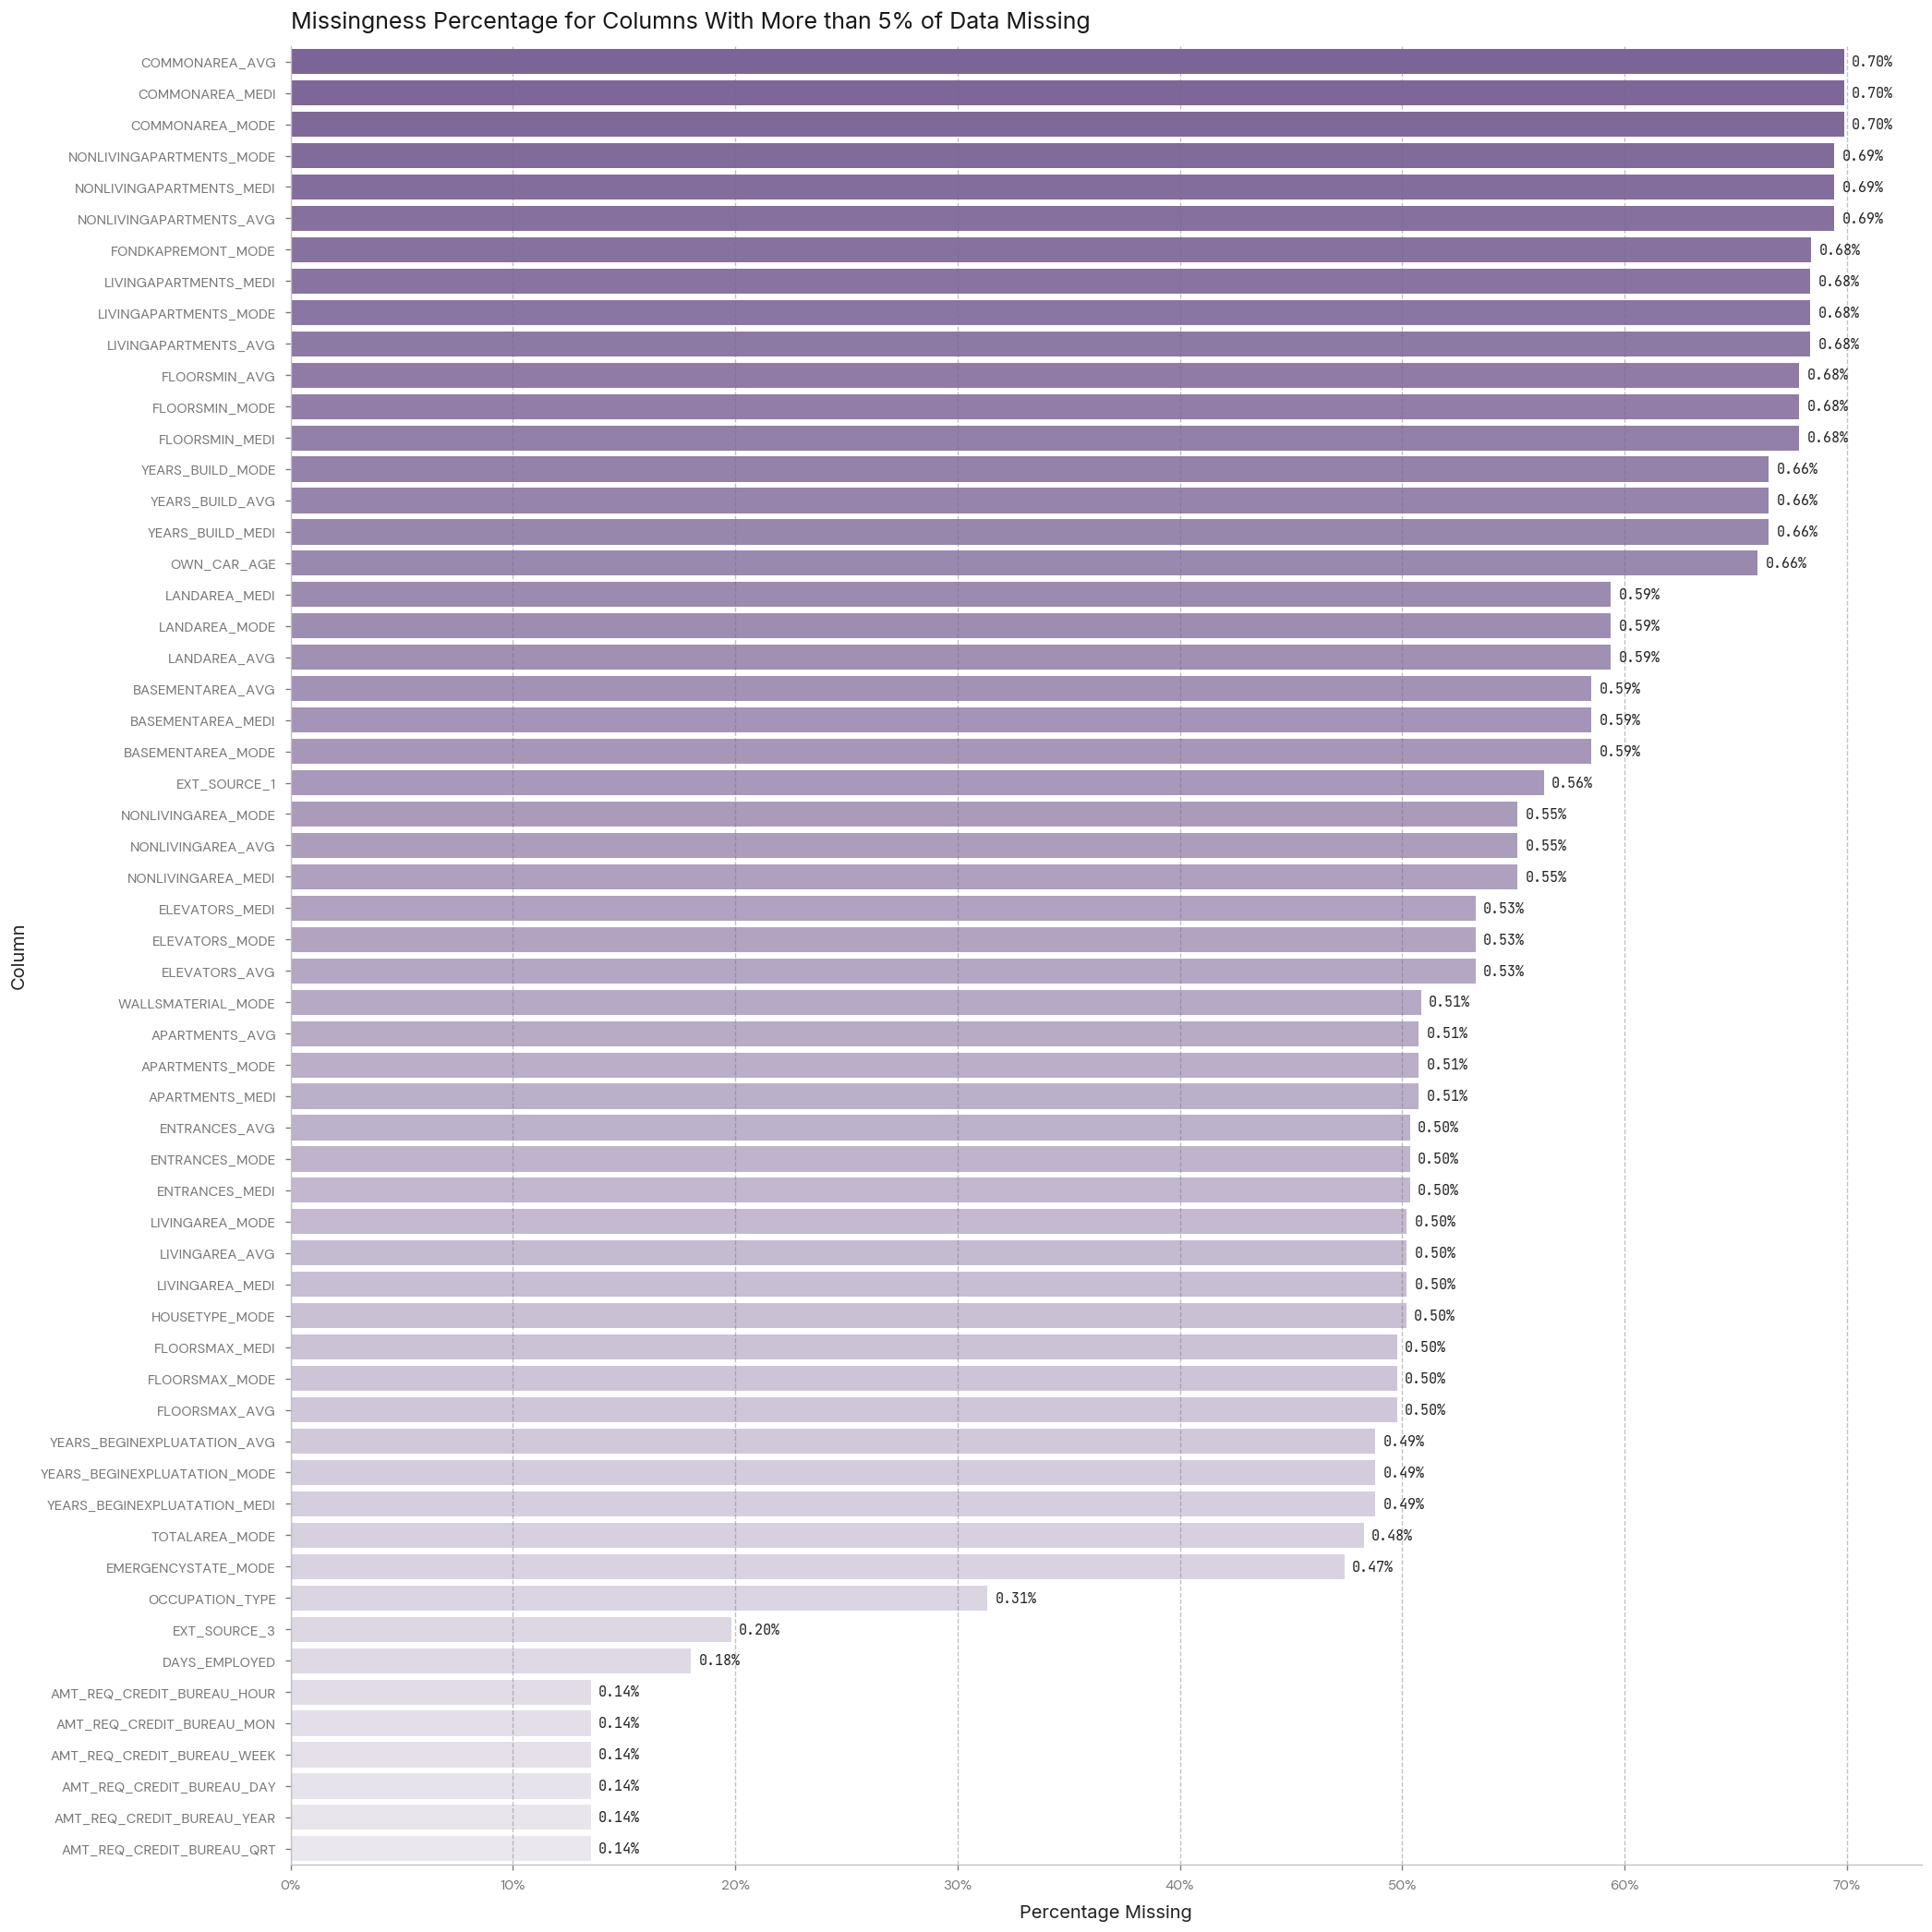

In [16]:
# Missingness by Column (>5% Missing)

missingness_pct = (df.isnull().sum()/len(df)).reset_index()

missingness_pct = missingness_pct.rename(columns={'index': 'column', 0 : 'pct'})

missingness_pct = missingness_pct.sort_values('pct', ascending=False)

missingness_pct = missingness_pct[missingness_pct['pct'] >= 0.05]

# Setting up gradient across bars
n_bars = len(missingness_pct)
alphas = np.linspace(1.0, 0.15, n_bars)

# Set Figure size with y
plt.figure(figsize=(len(missingness_pct)*0.3,len(missingness_pct)*0.3 ))

# Assigning Columns to axes and call SNS
ax = sns.barplot(missingness_pct, x='pct', y='column')

# Assigning gradient to bar chart
for bar, alpha in zip(ax.patches, alphas):
    bar.set_alpha(alpha)

# Setting chart labels and titles
ax.set_title('Missingness Percentage for Columns With More than 5% of Data Missing', fontfamily=f('heading'), fontsize= s('title'))
ax.set_xlabel("Percentage Missing", fontfamily=f('heading'), fontsize=s('subtitle'))
ax.set_ylabel("Column", fontfamily=f('heading'), fontsize=s('subtitle'))

# Formatting X-Axis

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Setting bar labels
ax.bar_label(ax.containers[0], padding= 5, labels=[f'{pct*100:.1f}%' for pct in missingness_pct['pct']], fontsize=s('small'), fontfamily=f('mono'), label_type='edge')

# Rendering chart
plt.show()


**Observation:** All of the columns with >= 50% of data missing belong to the same thematic subset - 'building_stats' - except for 'OWN_CAR_AGE' and 'EXT_SOURCE_1'. 

'OCCUPATION_TYPE', 'DAYS_EMPLOYED' and 'EXT_SOURCE_3' are also noteworthy as they come from categories that would typically be key criteria when assessing an application for a mortgage.

**Decision:** The 'building_stats' subset require a separate assessment of its missingness for a better understanding of its relevance for predicting default. The other two columns with high missingness percentage (>=50%) require a more granular assessment when looking at their correlation with default.

#### Fully Populated Thematic Groups

**Explanation:** There are some subsets that have zero missing values and should be excluded to provide a focused assessment of the missingness of the data set.

In [17]:
# Get groups that dont have any missing data to exclude from missingness assessment

fully_populated_thematic_groups = set()

for key in cols_by_theme:
    
    missing_per_group = df[cols_by_theme[key]].isnull().sum()
    
    
    print(key + '\n')
    print(missing_per_group)
    print('\n')
    
    if (missing_per_group == 0).all():
        fully_populated_thematic_groups.add(key)    

print(fully_populated_thematic_groups)

id_target

SK_ID_CURR    0
TARGET        0
dtype: int64


external_scores

EXT_SOURCE_1    173376
EXT_SOURCE_2       660
EXT_SOURCE_3     60965
dtype: int64


loan_financials

NAME_CONTRACT_TYPE      0
AMT_INCOME_TOTAL        0
AMT_CREDIT              0
AMT_ANNUITY            12
AMT_GOODS_PRICE       278
dtype: int64


demographics

CODE_GENDER               0
DAYS_BIRTH                0
CNT_CHILDREN              0
CNT_FAM_MEMBERS           2
NAME_FAMILY_STATUS        0
NAME_EDUCATION_TYPE       0
NAME_HOUSING_TYPE         0
NAME_TYPE_SUITE        1292
dtype: int64


employment

NAME_INCOME_TYPE         0
OCCUPATION_TYPE      96389
ORGANIZATION_TYPE        0
DAYS_EMPLOYED        55374
dtype: int64


assets

FLAG_OWN_CAR            0
OWN_CAR_AGE        202927
FLAG_OWN_REALTY         0
dtype: int64


contact

FLAG_MOBIL          0
FLAG_EMP_PHONE      0
FLAG_WORK_PHONE     0
FLAG_CONT_MOBILE    0
FLAG_PHONE          0
FLAG_EMAIL          0
dtype: int64


client_timeline

DAYS_REGISTRATION

**Observation:** The following thematic subsets - 'region', 'id_target', 'document_flags', 'application_timing' and 'contact' - all have zero missing values.

**Decision:** These subsets can be excluded from the missingness assessment that follows for a cleaner view of the data's missingness.

#### Missingness by Thematic Group

##### Missingness Bar Charts

Assessing missingness per thematic subset that have been shown to have missing data - excluding 'building_stats', as noted previously.

**Explanation:** The thematic subset assessment will show there is block-wise missingness within these subsets.

Text(0.0, 1.0, 'External Scores')

[Text(5, 0, '56.4%'), Text(5, 0, '0.2%'), Text(5, 0, '19.8%')]

Text(0.0, 1.0, 'Loan Financials')

[Text(5, 0, '0.0%'),
 Text(5, 0, '0.0%'),
 Text(5, 0, '0.0%'),
 Text(5, 0, '0.0%'),
 Text(5, 0, '0.1%')]

Text(0.0, 1.0, 'Demographics')

...

[Text(5, 0, '0.0%'), Text(5, 0, '0.0%'), Text(5, 0, '0.0%')]

Text(0.0, 1.0, 'Social Circle')

[Text(5, 0, '0.3%'),
 Text(5, 0, '0.3%'),
 Text(5, 0, '0.3%'),
 Text(5, 0, '0.3%')]

Text(0.0, 1.0, 'Bureau Enquiries')

[Text(5, 0, '13.5%'),
 Text(5, 0, '13.5%'),
 Text(5, 0, '13.5%'),
 Text(5, 0, '13.5%'),
 Text(5, 0, '13.5%'),
 Text(5, 0, '13.5%')]

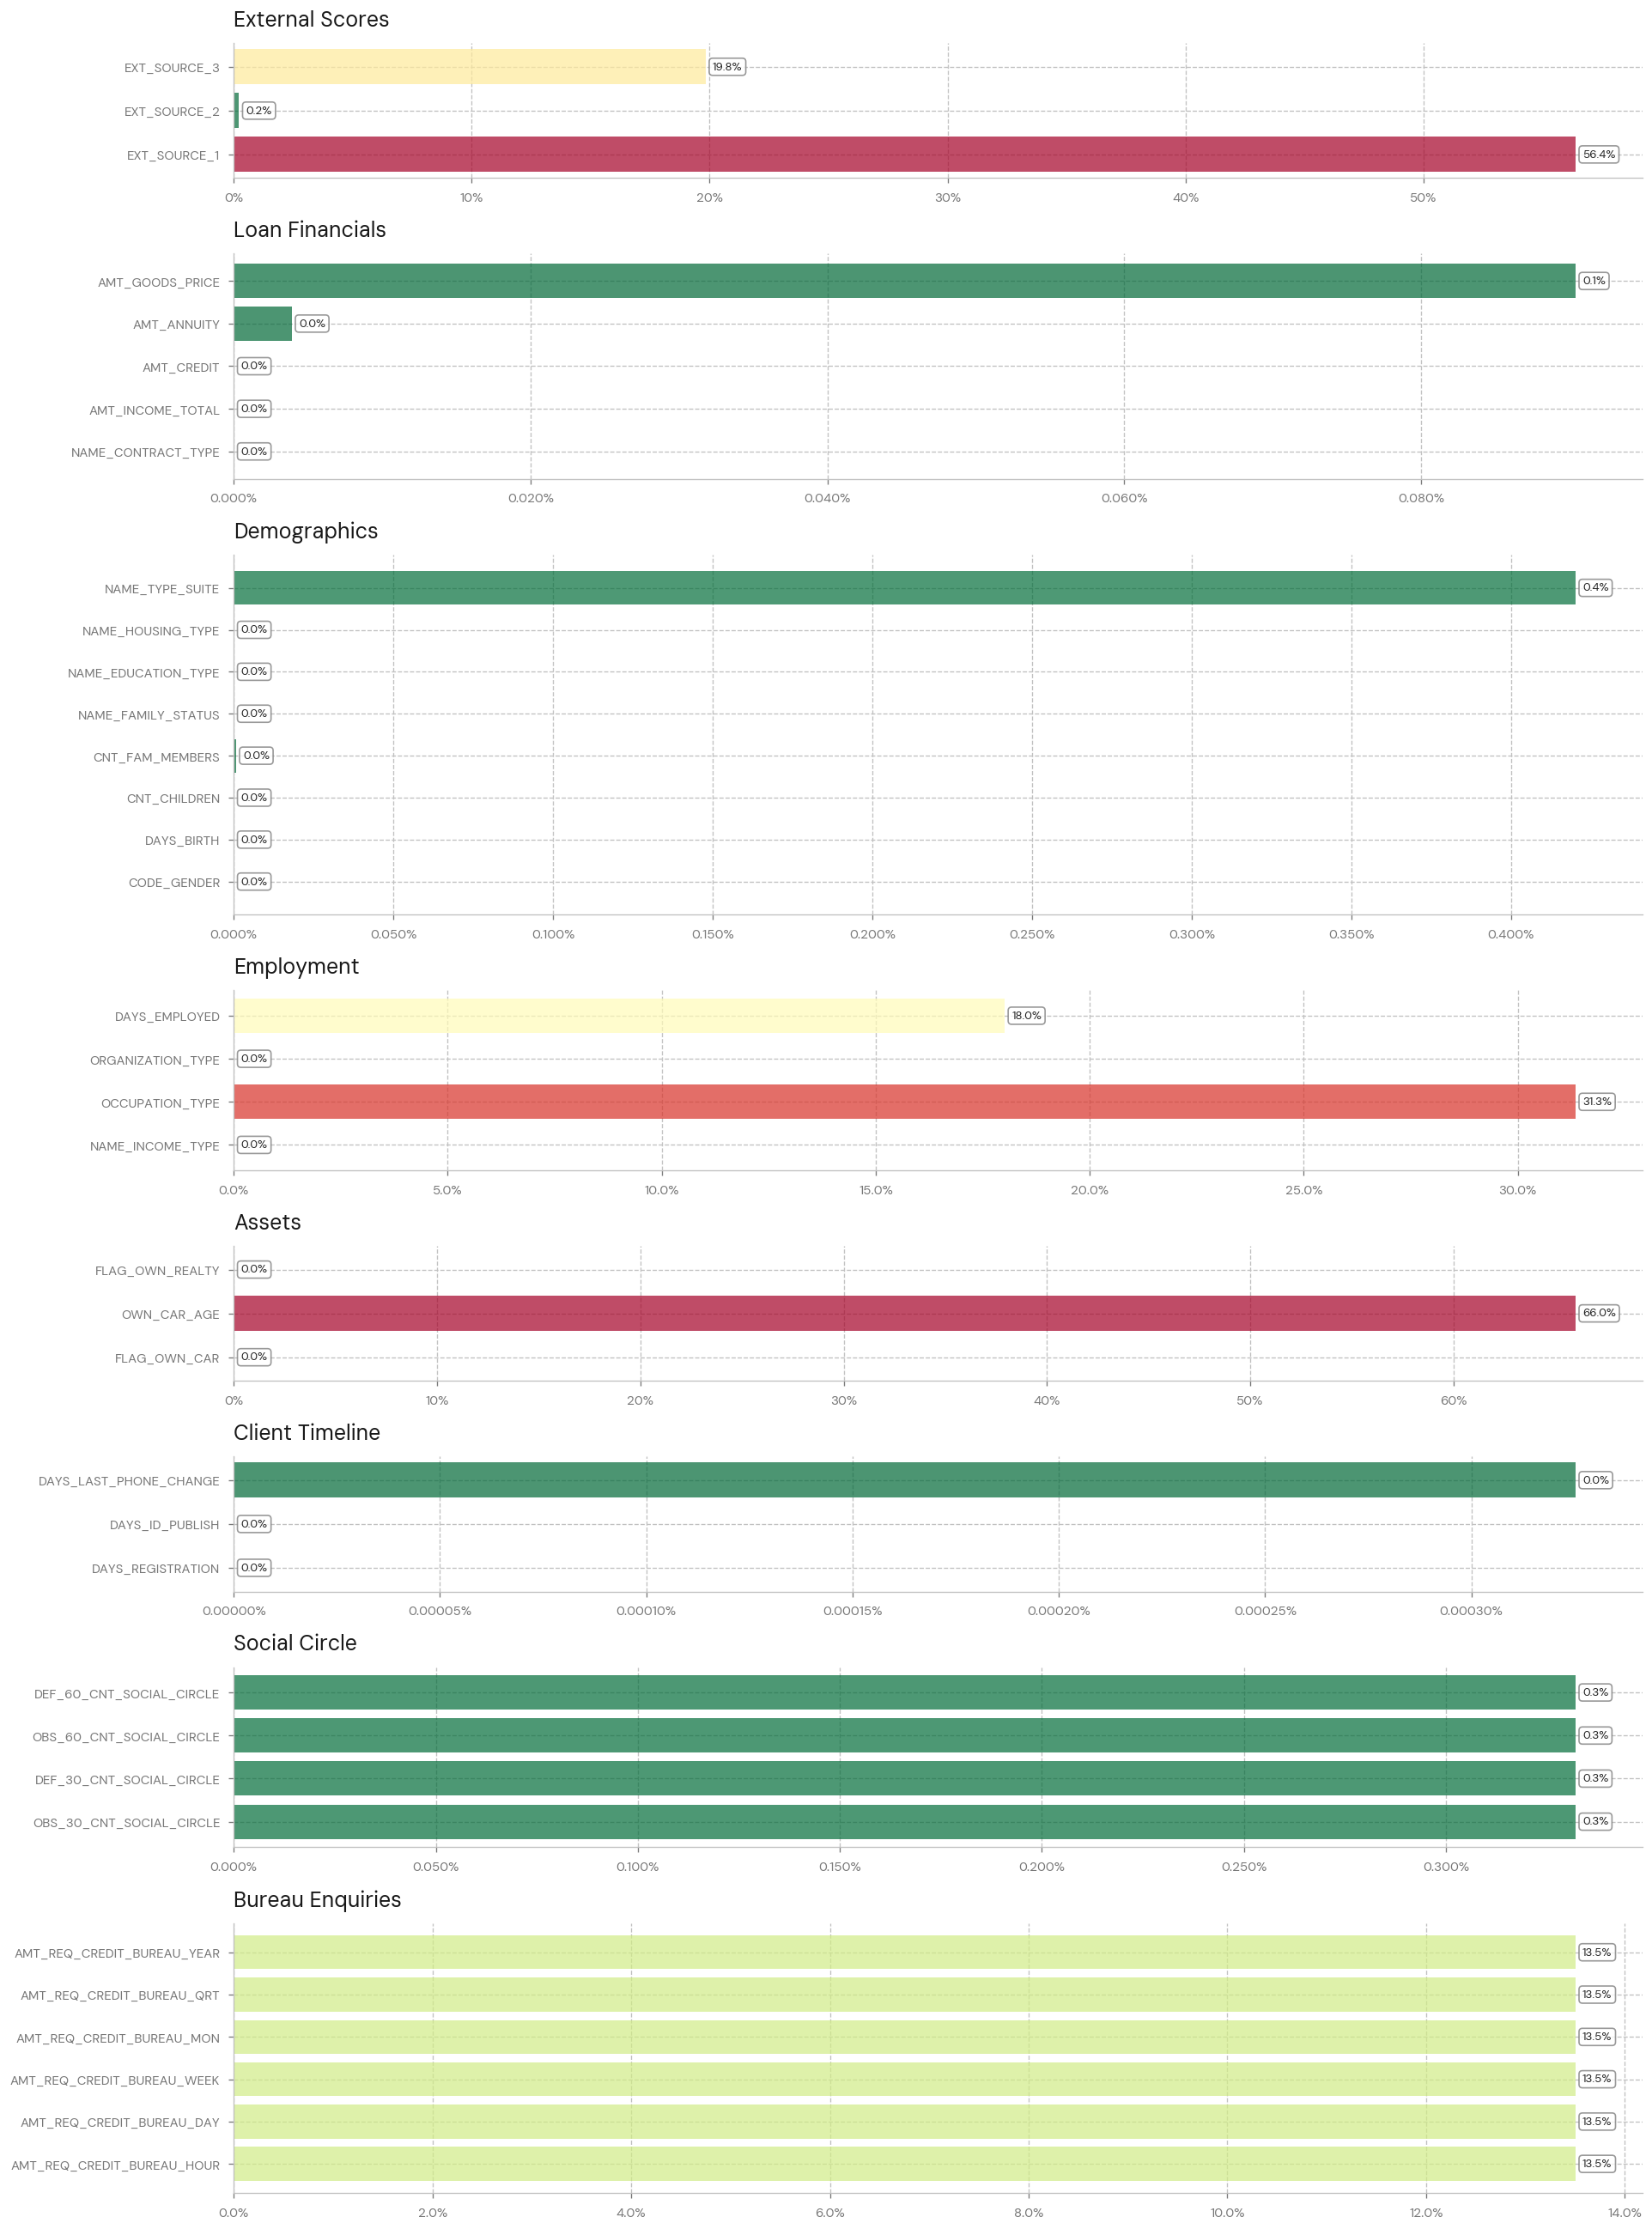

In [18]:

# Exlusion of groups with no missing values + building_stats due to size of group

exclude_thematic_groups = fully_populated_thematic_groups | {'building_stats'}

groups_to_plot = [k for k in cols_by_theme if k not in exclude_thematic_groups] 
num_figs = len(groups_to_plot)

# Setting figure count + render dimensions

bar_counts = [len(cols_by_theme[k]) for k in groups_to_plot]

n_cols = 1
n_rows = math.ceil(num_figs / n_cols)

# Setting color scheme for bar charts

cmap = cm._colormaps['RdYlGn_r']

# Setting up chart variables

n = len(df)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 0.6 * sum(bar_counts)), gridspec_kw={'height_ratios': bar_counts})
axes = axes.flatten()

# Loop to iterate through column groups for missingness percentages

for i, key in enumerate(groups_to_plot):
    
    # To drop zero values
    
    # frac = df[cols_by_theme[key]].isnull().sum() / n 
    # missing = frac[frac != 0]# missing per column
    
    # Keep zero values
    
    missing = df[cols_by_theme[key]].isnull().sum() / n 

    norm = colors.Normalize(vmin=0, vmax=0.35)

    bars = axes[i].barh(missing.index, missing.values,
                 color=cmap(norm(missing.values)),
                 alpha = 0.7)
    axes[i].set_title(key.replace('_', ' ').title())
    axes[i].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    axes[i].bar_label(bars, labels=[f"{w:.1%}" for w in missing.values],
                  padding=5, fontsize=8,
                  bbox=dict(boxstyle='round', facecolor='white',
                            edgecolor='grey', alpha=0.8))
    
plt.show()


**Observation:** The "social_circle" and "bureau_enquiries" subsets show block-wise missingness.

**Decision:** These thematic subsets will also be assessed further.

##### Building Stats Missingness

In [19]:
# Missingness check across median, mode and average check null patterns

cols = cols_by_theme['building_stats']
miss = df[cols].isnull().sum()

# split each column name into (base, suffix), e.g. APARTMENTS_AVG -> ('APARTMENTS','AVG')
tbl = miss.rename_axis('col').reset_index(name='n_missing')
tbl['suffix'] = tbl['col'].str.rsplit('_', n=1).str[1]
tbl['base']   = tbl['col'].str.rsplit('_', n=1).str[0]

pivot = tbl.pivot(index='base', columns='suffix', values='n_missing')
print(pivot)


suffix                   AVG       MEDI      MODE    
base                                                 
APARTMENTS              156060.00 156060.00 156060.00
BASEMENTAREA            179942.00 179942.00 179942.00
COMMONAREA              214862.00 214862.00 214862.00
ELEVATORS               163890.00 163890.00 163890.00
EMERGENCYSTATE                NaN       NaN 145754.00
ENTRANCES               154827.00 154827.00 154827.00
FLOORSMAX               153019.00 153019.00 153019.00
FLOORSMIN               208640.00 208640.00 208640.00
FONDKAPREMONT                 NaN       NaN 210293.00
HOUSETYPE                     NaN       NaN 154296.00
LANDAREA                182588.00 182588.00 182588.00
LIVINGAPARTMENTS        210197.00 210197.00 210197.00
LIVINGAREA              154349.00 154349.00 154349.00
NONLIVINGAPARTMENTS     213512.00 213512.00 213512.00
NONLIVINGAREA           169680.00 169680.00 169680.00
TOTALAREA                     NaN       NaN 148430.00
WALLSMATERIAL               

0.6233260177847602


<Figure size 1440x1200 with 0 Axes>

<Axes: >

Text(0.0, 1.0, 'Missingness correlation across building_stats columns')

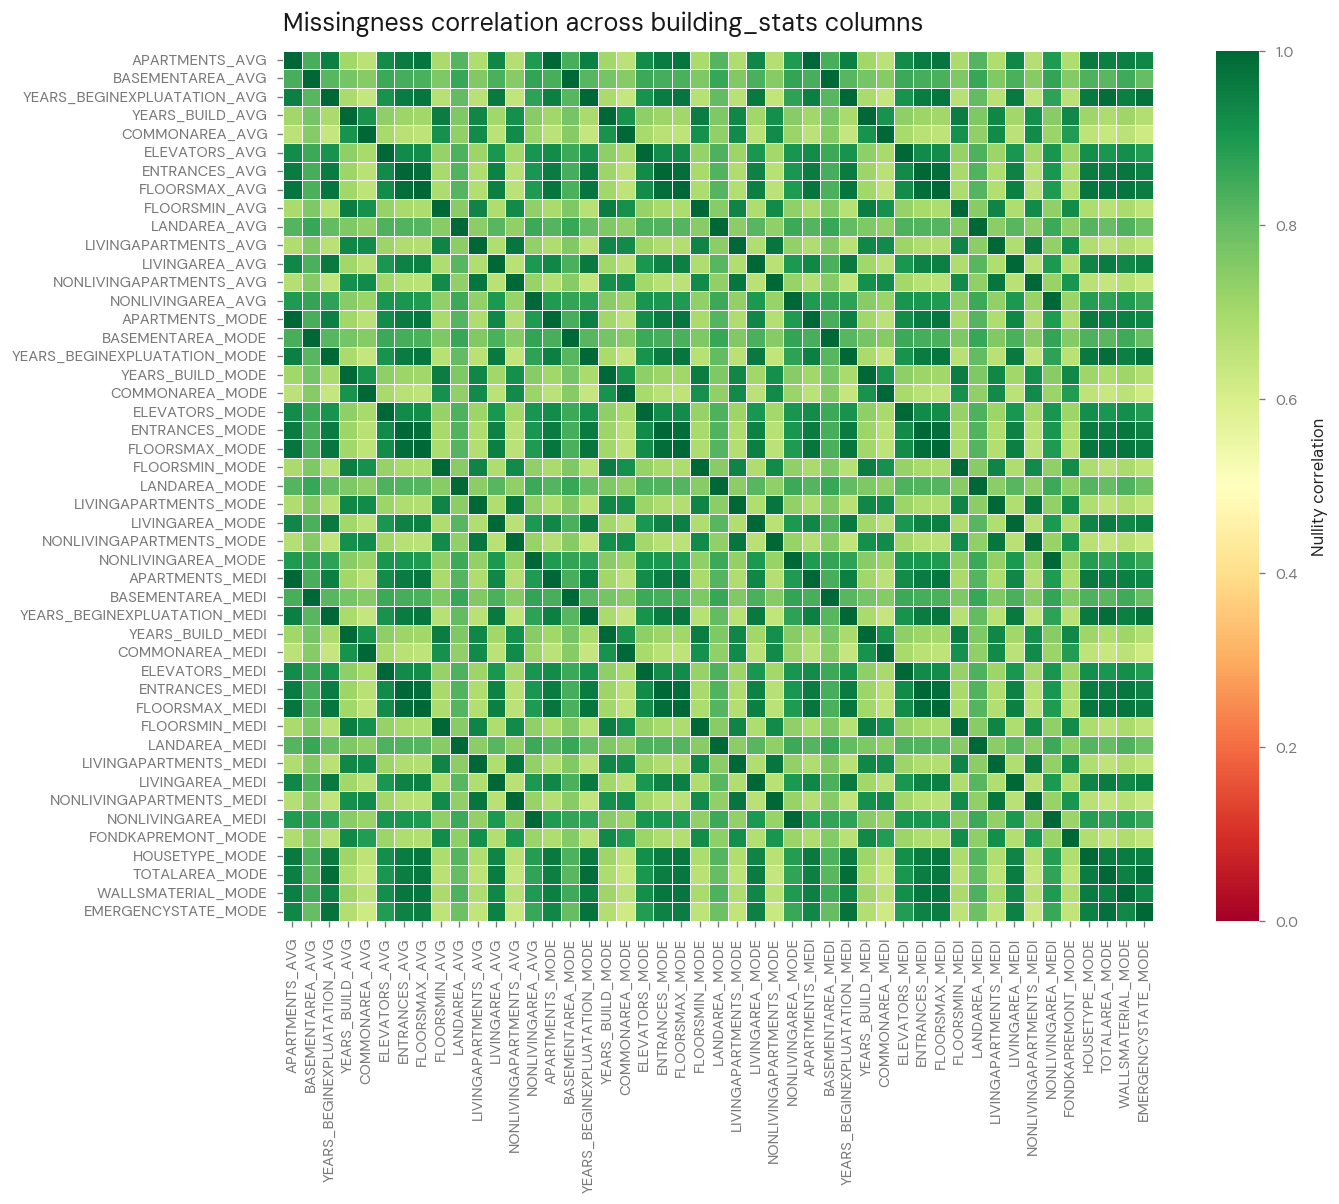

In [20]:
# Pivot Shows equivalent missingness counts across each of these columns - check correlation to confirm same values missing in each column
corr = df[cols].isnull().corr()

off_diag = corr.where(~np.eye(len(corr), dtype=bool))
print(off_diag.min().min())

# Visualisation to confirm

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            cmap='RdYlGn',
            vmin=0, vmax=1,      # lock scale so 1.0 = full color
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Nullity correlation'})
plt.title('Missingness correlation across building_stats columns')
plt.show()

# Nullity correlation = 1 WITHIN each AVG/MEDI/MODE triplet (identical rows missing) -> safe to collapse to one AVG. Global off-diagonal min is ~0.62 (across different attributes). 

**Observation**: Missingness across the average, median and mode for the building_stats thematic subgroup are equivalent

                              APARTMENTS_AVG  BASEMENTAREA_AVG  \
APARTMENTS_AVG               1.00            0.84                
BASEMENTAREA_AVG             0.84            1.00                
YEARS_BEGINEXPLUATATION_AVG  0.95            0.82                
YEARS_BUILD_AVG              0.71            0.78                
COMMONAREA_AVG               0.66            0.75                
ELEVATORS_AVG                0.92            0.85                
ENTRANCES_AVG                0.96            0.84                
FLOORSMAX_AVG                0.97            0.84                
FLOORSMIN_AVG                0.69            0.76                
LANDAREA_AVG                 0.82            0.86                
LIVINGAPARTMENTS_AVG         0.68            0.76                
LIVINGAREA_AVG               0.93            0.83                
NONLIVINGAPARTMENTS_AVG      0.67            0.75                
NONLIVINGAREA_AVG            0.89            0.87                
APARTMENTS

Text(0.0, 1.0, 'Percentage of Missing Data for the Building Stats Thematic Subgroup')

Text(0, 0.5, 'Building Stat')

Text(0.5, 0, 'Percentage of Data Missing')

[Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%'),
 Text(5, 0, 'g%')]

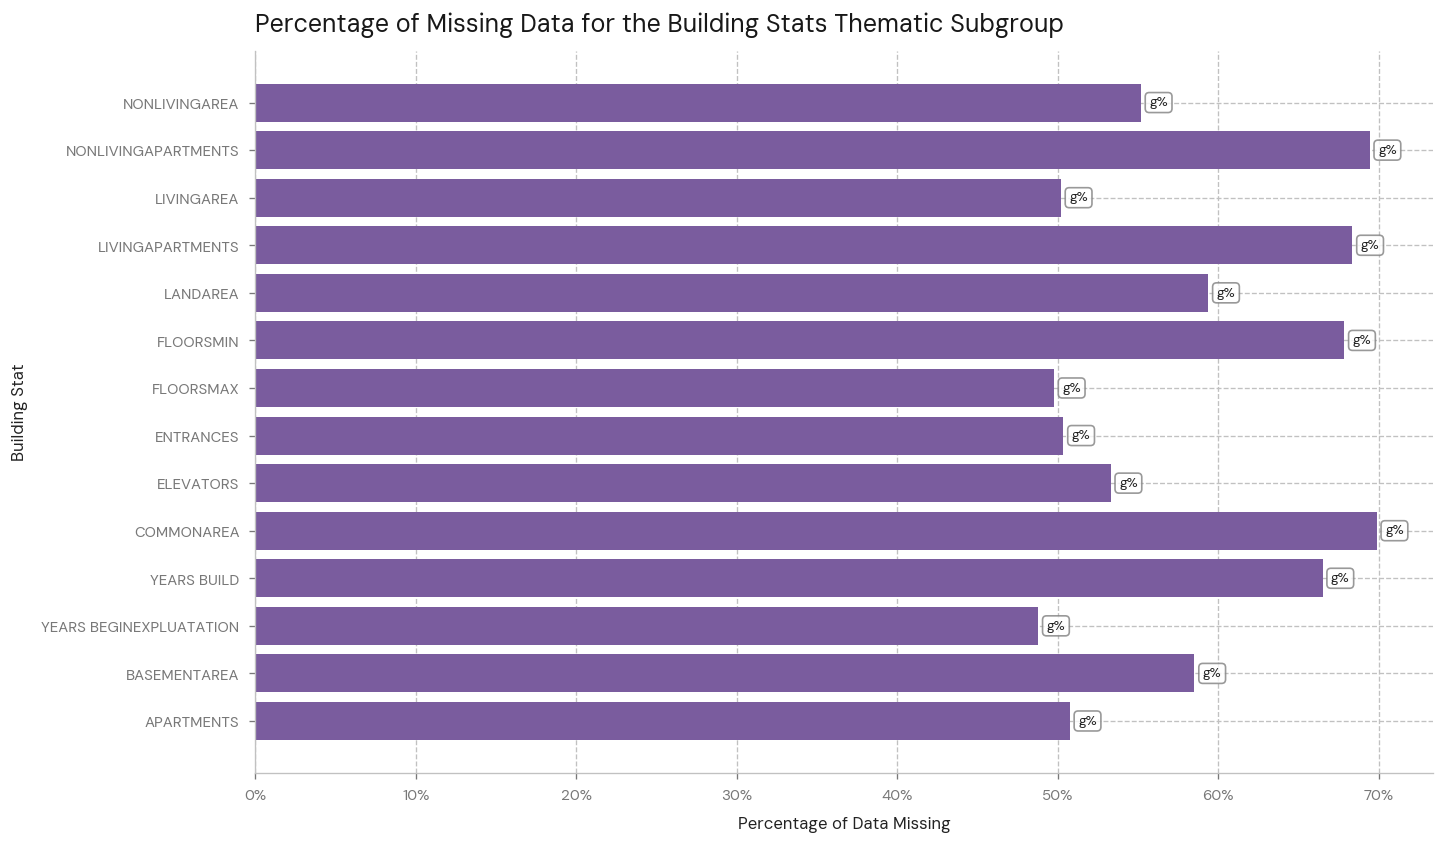

In [21]:
# Excluding median and mode columns and only using average as the missingness is shared between them 

avg_cols = [c for c in cols_by_theme['building_stats'] if 'AVG' in c]

missingness_avg_build = df[avg_cols].isnull().sum()

missingness_avg_build_cols_percentage = missingness_avg_build / n

labels = [c.replace('_AVG', '').replace('_',' ') for c in missingness_avg_build_cols_percentage.index]

print(corr)

print(missingness_avg_build_cols_percentage)

fig, ax = plt.subplots(figsize = (12, 0.5 * len(missingness_avg_build_cols_percentage)))

bars_2 = ax.barh(labels, missingness_avg_build_cols_percentage.values)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Percentage of Missing Data for the Building Stats Thematic Subgroup')
ax.set_ylabel('Building Stat')
ax.set_xlabel('Percentage of Data Missing')
ax.bar_label(bars_2, labels=[f'{w:.1%}' for w in missingness_avg_build_cols_percentage.values],
            padding=5, fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white',
                            edgecolor='grey', alpha=0.8))
plt.show()


**Decision:** Leave this subset as is for now. Upon completing univariate analysis for this subset and before feature selection it can be determined whether the 15 triplet columns (AVG, MED, MODE) are collapsed into one with a 'building_missing_info' sentinel column.  

##### Car Data Missingness

In [22]:
# Check whether missingness of Car Ages for each borrower corresponds with them owning a car or not

car_age_missing = df['OWN_CAR_AGE'].isnull()

(df.loc[car_age_missing, 'FLAG_OWN_CAR'] =='N').mean().round(4)

np.float64(1.0)

**Observation/Decision:** almost a complete match of the missingness for 'OWN_CAR_AGE' to borrowers that do not own a car. Therefore this is MAR missingness and requires no action at this stage.

##### Bureau Enquiries Missingness

In [23]:
# Missingness check across bureau enquiries subset

cols_be = cols_by_theme['bureau_enquiries']
miss = df[cols_be].isnull().sum()

# split each column name into (base, suffix)
tbl = miss.rename_axis('col').reset_index(name='n_missing')
tbl['suffix'] = tbl['col'].str.rsplit('_', n=1).str[1]
tbl['base']   = tbl['col'].str.rsplit('_', n=1).str[0]

pivot = tbl.pivot(index='base', columns='suffix', values='n_missing')
print(pivot)


suffix                 DAY    HOUR   MON    QRT    WEEK   YEAR 
base                                                           
AMT_REQ_CREDIT_BUREAU  41519  41519  41519  41519  41519  41519


1.0


<Figure size 1440x1200 with 0 Axes>

<Axes: >

Text(0.0, 1.0, 'Missingness correlation across bureau_enquiries columns')

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0.5, 0, 'AMT_REQ_CREDIT_BUREAU_HOUR'),
  Text(1.5, 0, 'AMT_REQ_CREDIT_BUREAU_DAY'),
  Text(2.5, 0, 'AMT_REQ_CREDIT_BUREAU_WEEK'),
  Text(3.5, 0, 'AMT_REQ_CREDIT_BUREAU_MON'),
  Text(4.5, 0, 'AMT_REQ_CREDIT_BUREAU_QRT'),
  Text(5.5, 0, 'AMT_REQ_CREDIT_BUREAU_YEAR')])

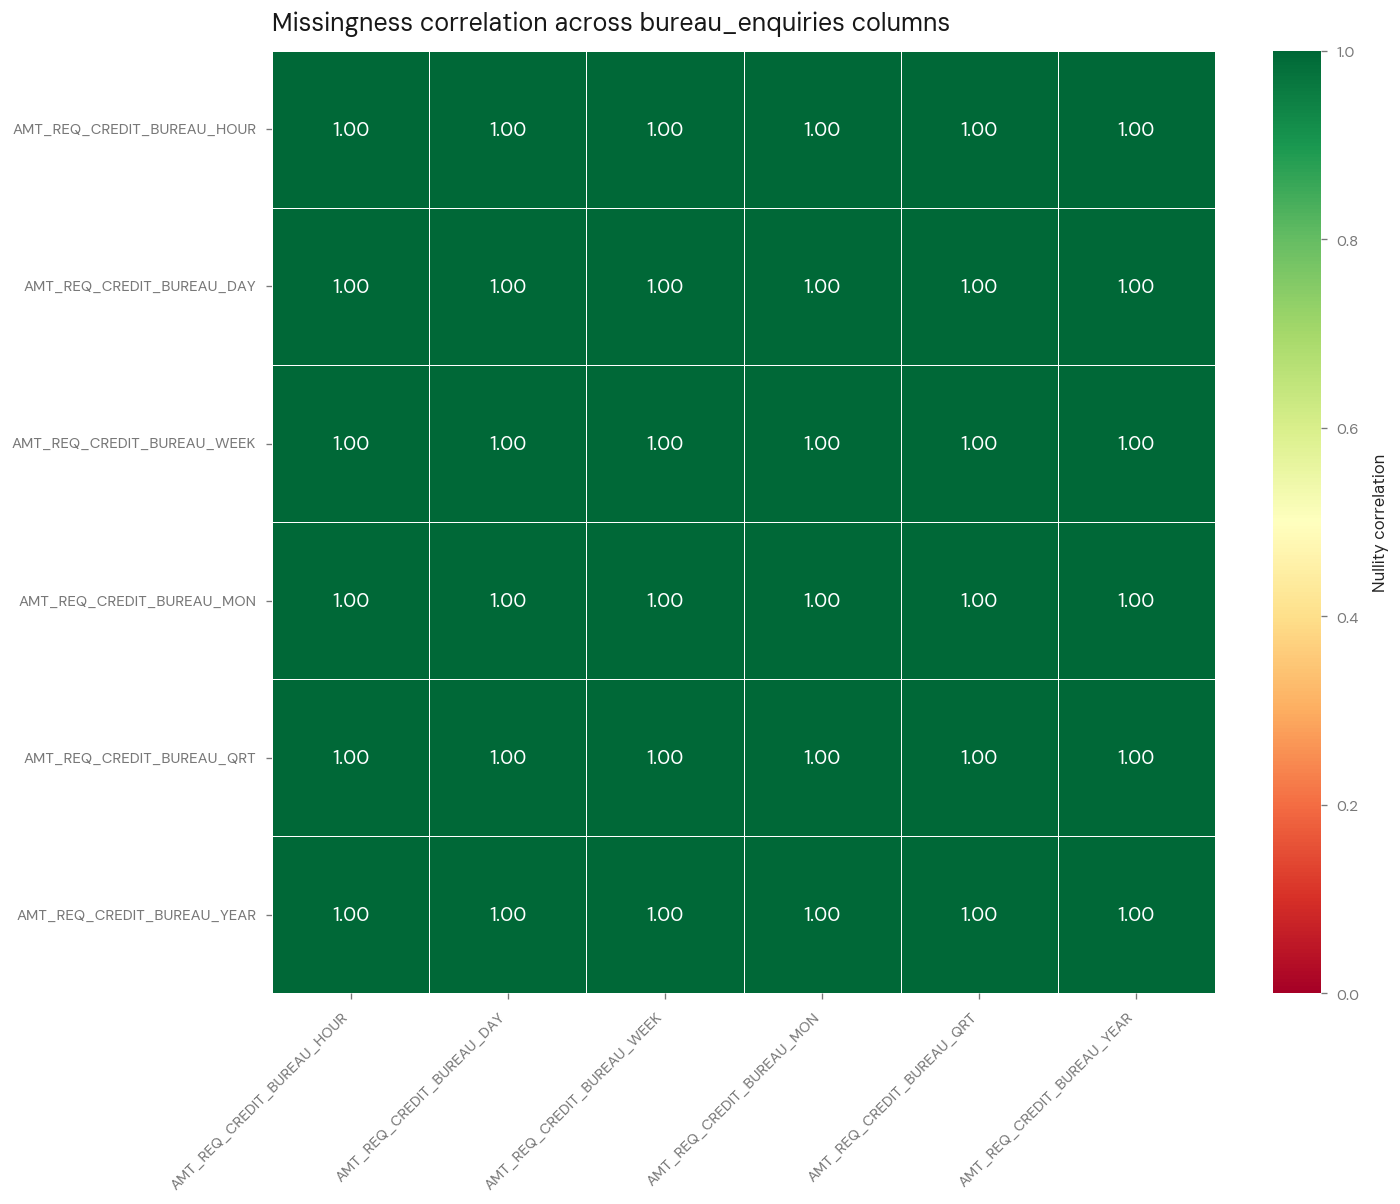

In [24]:
# Pivot Shows equivalent missingness counts across each of these columns - check correlation to confirm same values missing in each column
corr = df[cols_be].isnull().corr()

off_diag = corr.where(~np.eye(len(corr), dtype=bool))
print(off_diag.min().min())

# Visualisation to confirm

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            cmap='RdYlGn',
            vmin=0, vmax=1,
            square=True,
            linewidths=0.5,
            annot=True,          # write the value in each square
            fmt='.2f',           # 2 decimal places
            annot_kws={'size': 12},
            cbar_kws={'label': 'Nullity correlation'})
plt.title('Missingness correlation across bureau_enquiries columns')

plt.xticks(rotation=45, ha='right')

plt.show()


##### Social Circles Missingness

In [25]:
# Missingness check across social circles subset

cols_sc = cols_by_theme['social_circle']
miss = df[cols_sc].isnull().sum()

# split each column name into (base, suffix)
tbl = miss.rename_axis('col').reset_index(name='n_missing')
tbl['suffix'] = tbl['col'].str.rsplit('_', n=1).str[1]
tbl['base']   = tbl['col'].str.rsplit('_', n=1).str[0]

pivot = tbl.pivot(index='base', columns='suffix', values='n_missing')
print(pivot)


suffix             CIRCLE
base                     
DEF_30_CNT_SOCIAL  1021  
DEF_60_CNT_SOCIAL  1021  
OBS_30_CNT_SOCIAL  1021  
OBS_60_CNT_SOCIAL  1021  


1.0


<Figure size 1440x1200 with 0 Axes>

<Axes: >

Text(0.0, 1.0, 'Missingness correlation across social_circle columns')

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, 'OBS_30_CNT_SOCIAL_CIRCLE'),
  Text(0, 1.5, 'DEF_30_CNT_SOCIAL_CIRCLE'),
  Text(0, 2.5, 'OBS_60_CNT_SOCIAL_CIRCLE'),
  Text(0, 3.5, 'DEF_60_CNT_SOCIAL_CIRCLE')])

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0.5, 0, 'OBS_30_CNT_SOCIAL_CIRCLE'),
  Text(1.5, 0, 'DEF_30_CNT_SOCIAL_CIRCLE'),
  Text(2.5, 0, 'OBS_60_CNT_SOCIAL_CIRCLE'),
  Text(3.5, 0, 'DEF_60_CNT_SOCIAL_CIRCLE')])

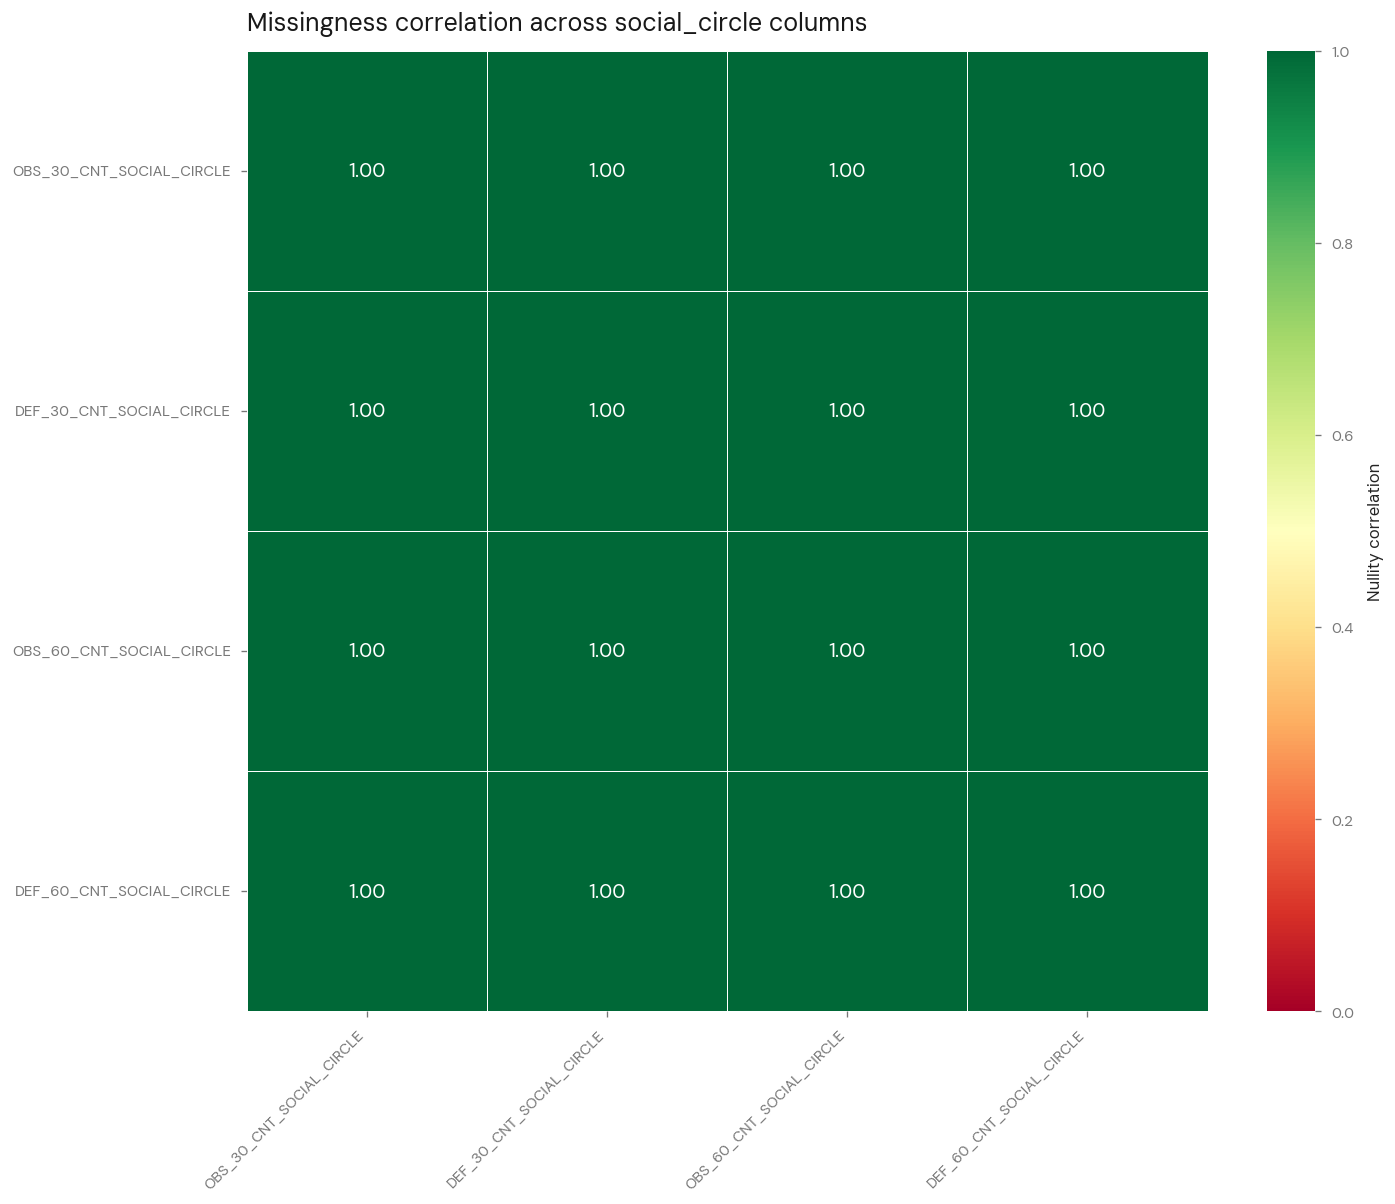

In [26]:
# Pivot Shows equivalent missingness counts across each of these columns - check correlation to confirm same values missing in each column
corr = df[cols_sc].isnull().corr()

off_diag = corr.where(~np.eye(len(corr), dtype=bool))
print(off_diag.min().min())

# Visualisation to confirm

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            cmap='RdYlGn',
            vmin=0, vmax=1,
            square=True,
            linewidths=0.5,
            annot=True,          # write the value in each square
            fmt='.2f',           # 2 decimal places
            annot_kws={'size': 12},
            cbar_kws={'label': 'Nullity correlation'})
plt.title('Missingness correlation across social_circle columns')

plt.yticks(rotation=0, ha='right')
plt.xticks(rotation=45, ha='right')

plt.show()

In [27]:
# quick crosstab check for these thematic subsets

bureau_missing = df[cols_by_theme['bureau_enquiries'][0]].isnull()
social_missing = df[cols_by_theme['social_circle'][0]].isnull()

pd.crosstab(bureau_missing, social_missing)

OBS_30_CNT_SOCIAL_CIRCLE,False,True
AMT_REQ_CREDIT_BUREAU_HOUR,,
False,265137,851
True,41349,170


**Observation/Decision:** Both subsets show block-wise missingness, and the crosstab confirms they are independent of each other (minimal row overlap) - so they have separate origins. Mechanism (informative vs not) to be tested against TARGET in Section 5.

### 2.4 Cardinality Assessment

Cardinality Assessment of Categorical Ordinal Columns. The columns 'HOUR_APPR_PROCESS_START', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY' are being dropped from this assessment as they are defined by internal ratings and the hours of the day. There are no benefits to assessing these columns in this context as no actions will be taken to; merge sparse columns, establish supervised grouping or domain grouping.

**Explanation:** A few categorical features (notably occupation and organization type) are expected to have high cardinality with many sparse levels. Sparse levels produce unstable WOE (too few bads per bin), so they'll need pooling (rare levels merged) or supervised grouping by default rate before IV/WOE binning; low-cardinality categoricals should need no treatment.

['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']


14

Text(0.5, 0, 'Count of Unique Value in Column')

Text(0, 0.5, 'Column Name')

Text(0.0, 1.0, 'Categorical Data Type Cardinality by Column')

[Text(10, 0, '3'),
 Text(10, 0, '4'),
 Text(10, 0, '5'),
 Text(10, 0, '6'),
 Text(10, 0, '6'),
 Text(10, 0, '7'),
 Text(10, 0, '7'),
 Text(10, 0, '7'),
 Text(10, 0, '8'),
 Text(10, 0, '18'),
 Text(10, 0, '58')]

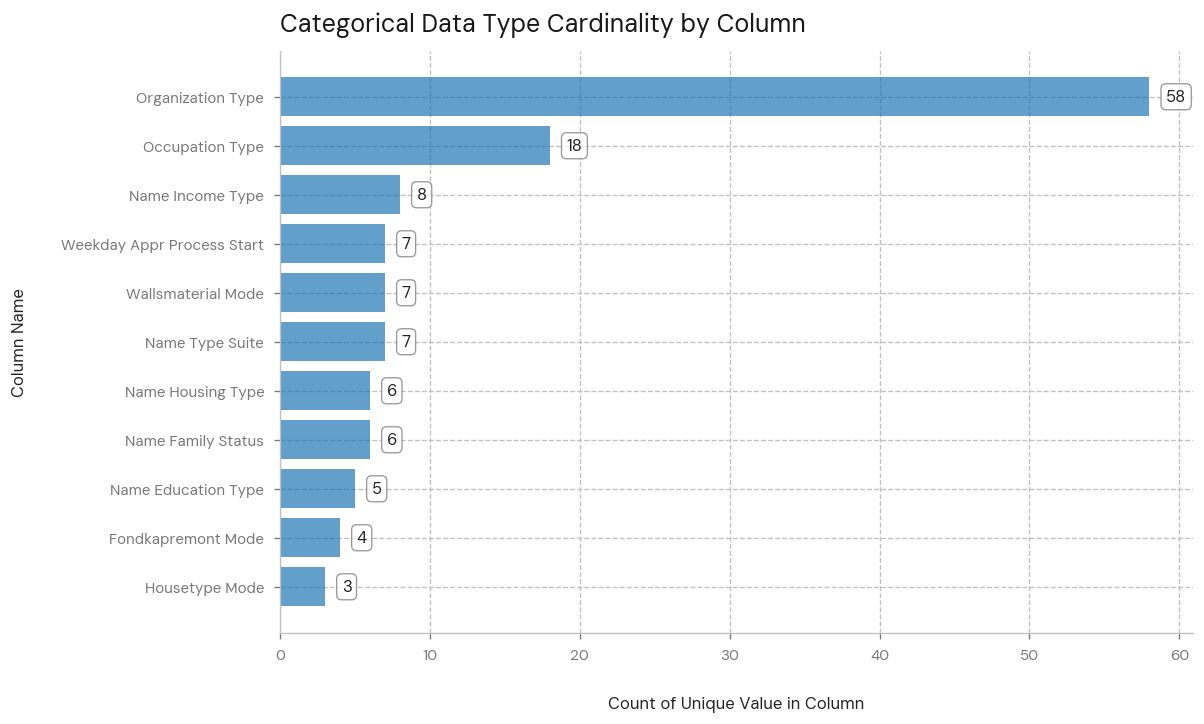

In [28]:
# Categorical Cardinality by Column

print(cols_by_type['categorical'])
    
cols = cols_by_type['categorical'] + cols_by_type['ordinal']

len(cols)

cardinality = df[cols].nunique().sort_values(ascending=True)

cardinality = cardinality.drop(['HOUR_APPR_PROCESS_START', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY'])

labels = cardinality.index.str.replace('_', ' ').str.title()


fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(labels, cardinality.values,
        color="tab:blue",
        alpha=0.7)

ax.set_xlabel('Count of Unique Value in Column', labelpad=20)
ax.set_ylabel('Column Name', labelpad=20)
ax.set_title('Categorical Data Type Cardinality by Column')

ax.bar_label(bars,
             padding=10,
             bbox=dict(
                 boxstyle='round',
                 facecolor='white',
                 edgecolor='grey',
                 alpha = 0.8,
                 linewidth=0.8
             ))
plt.show()


**Observation/Decision**: The two highest cardinality columns 'OCCUPATION_TYPE' and 'ORGANIZATION_TYPE' exceed more than 10 unique entries and must have a specified treatment plan for IV/WOE binning and the following ranking of feature importance.

In [ ]:
# Assess columns with < 5% of the data for merging into an other column

bins = df['OCCUPATION_TYPE'].value_counts(normalize=True, ascending=True, dropna=False)

print((bins.values < 0.05).sum())

7


In [ ]:
# Assess columns with < 5% of the data for merging into an other column

bins = df['ORGANIZATION_TYPE'].value_counts(normalize=True, ascending=True, dropna=False)

print((bins.values < 0.05).sum())

# Many levels contain < 5% of the data - will look at default rate per level instead

defaulters = df['ORGANIZATION_TYPE'][df['TARGET'] == 1]

organization_type_counts = df['ORGANIZATION_TYPE'].value_counts(dropna=False)

defaulters = defaulters.value_counts(dropna=False) / organization_type_counts

defaulters.sort_values(ascending=False).map('{:.2%}'.format)

# Sanity Check

# len(df[df['ORGANIZATION_TYPE'] == 'Transport: type 3'] )

# len(df[(df['ORGANIZATION_TYPE'] == 'Transport: type 3') & (df['TARGET'] == 1)]  )

# 187 / 1187

41


ORGANIZATION_TYPE
Transport: type 3         15.75%
Industry: type 13         13.43%
Industry: type 8          12.50%
Restaurant                11.71%
Construction              11.68%
Cleaning                  11.15%
Industry: type 1          11.07%
Industry: type 3          10.62%
Realtor                   10.61%
Agriculture               10.47%
Trade: type 3             10.34%
Self-employed             10.17%
Industry: type 4          10.15%
Security                   9.98%
Trade: type 7              9.45%
Business Entity Type 3     9.30%
Transport: type 4          9.28%
Mobile                     9.15%
Trade: type 1              8.91%
Industry: type 11          8.65%
Business Entity Type 2     8.53%
Postal                     8.44%
Advertising                8.16%
Business Entity Type 1     8.14%
Industry: type 7           8.03%
Housing                    7.94%
Legal Services             7.87%
Transport: type 2          7.80%
Other                      7.64%
Telecom                  

**Observation:** Both are high-cardinality categoricals whose sparse levels would produce unstable WOE. ORGANIZATION_TYPE (~58 levels) will be grouped by similar default rate (see band mapping below); OCCUPATION_TYPE (~18 levels) will have levels below 5% pooled, with NaN kept as its own category.

**Note (leakage):** The ORG_BAND mapping below is defined using TARGET (default rate) on the full dataset, so its IV here would be optimistic. This supervised binning will be refit on the TRAIN split only in Section 5.1, alongside the other WOE binning decisions.

#### Band Mapping for 'ORGANIZATION TYPE'


In [ ]:
# EDA VIEW ONLY — no leakage. This shows the rate-band mapping we WILL use,
# computed on the full frame purely to eyeball the grouping. The modelling feature
# df['ORG_BAND'] is NOT created here: it is fit on the TRAIN split only in §5.1
# (fit_org_bands) and mapped onto train/val, exactly like a WOE map.

rate = df.groupby('ORGANIZATION_TYPE')['TARGET'].mean()
counts = df['ORGANIZATION_TYPE'].value_counts()

band = pd.cut(rate, bins=[0, 0.06, 0.08, 0.10, 1.0],
              labels=['<6%', '6-8%', '8-10%', '>10%']).astype('object')
# keep a high-rate level on its own only if it's big enough
hi = (rate > 0.10) & (counts >= 500)
band[hi] = rate.index[hi]

preview = (pd.DataFrame({'default_rate': rate, 'n': counts, 'band': band})
             .sort_values('default_rate', ascending=False))
print(f"Organisation types: {rate.size}  ->  bands: {band.nunique()}  (EDA preview only)")
preview

**Observation:** We now have only bins for computing IV/WOE. Low default count over 10% default have been grouped into the  >10% bin.

## 3. Feature Analysis

**Purpose.** Work through each feature family end to end — characterise its distribution (**Univariate**), then test how it moves with default (**Bivariate**) — so the binning decisions in Section 5 (WOE/IV) are informed rather than arbitrary. Surface skew, outliers, sparse categories and missingness, and close every family with a Decision that states the intended transform/binning.

**Approach.** Work thematically using the `cols_by_theme` scaffolding from Section 2, highest-value families first. Each family runs two beats — Univariate then Bivariate — before a single committed Decision. Keep the **Predict → Task → Decision** rhythm; each Decision should point forward to Section 5.

**Planned order:**

| # | Family | Columns | What to look for → decision |
|---|---|---|---|
| 3.1 | External scores | `EXT_SOURCE_1/2/3` | Strongest expected drivers. Shape + missingness (EXT_SOURCE_1 ~56% missing) → quantile bins, missing as its own bin? |
| 3.2 | Loan financials | `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE` | Heavy right-skew + outliers → log-transform vs quantile bins |
| 3.3 | Age & employment | `DAYS_BIRTH`, `DAYS_EMPLOYED` | Convert to positive years (`/-365`); DAYS_EMPLOYED carries the sentinel NaN → bin + missing flag |
| 3.4 | Key categoricals | education, family status, income type, contract type | Frequency bars + default rate per level; note sparse levels (links back to 2.4 cardinality) |
| 3.5 | Other numeric families | `client_timeline`, `social_circle`, `bureau_enquiries` | Lighter touch; confirm shape, flag anything odd |

**Scope note:** distributions, target relationships and binning intent — the cross-feature IV ranking and the WOE/IV encoding itself are quantified in Section 5.


### 3.1 External Scores

**Explanation.** External credit scores (`EXT_SOURCE_1/2/3`) are the expected strongest drivers — normalised third-party risk scores on a 0–1 scale. Here we characterise their distribution and coverage (EXT_SOURCE_1 is ~56% missing) to decide binning strategy and how to treat missingness.

#### Univariate Analysis

In [32]:
cols_by_theme.keys()

dict_keys(['id_target', 'external_scores', 'loan_financials', 'demographics', 'employment', 'assets', 'contact', 'client_timeline', 'application_timing', 'region', 'building_stats', 'social_circle', 'document_flags', 'bureau_enquiries'])

(0.0, 1.0)

(0.0, 1.0)

(0.0, 1.0)

Text(0.5, 0.98, 'External Credit Scores')

Text(0.02, 0.5, 'Applicants')

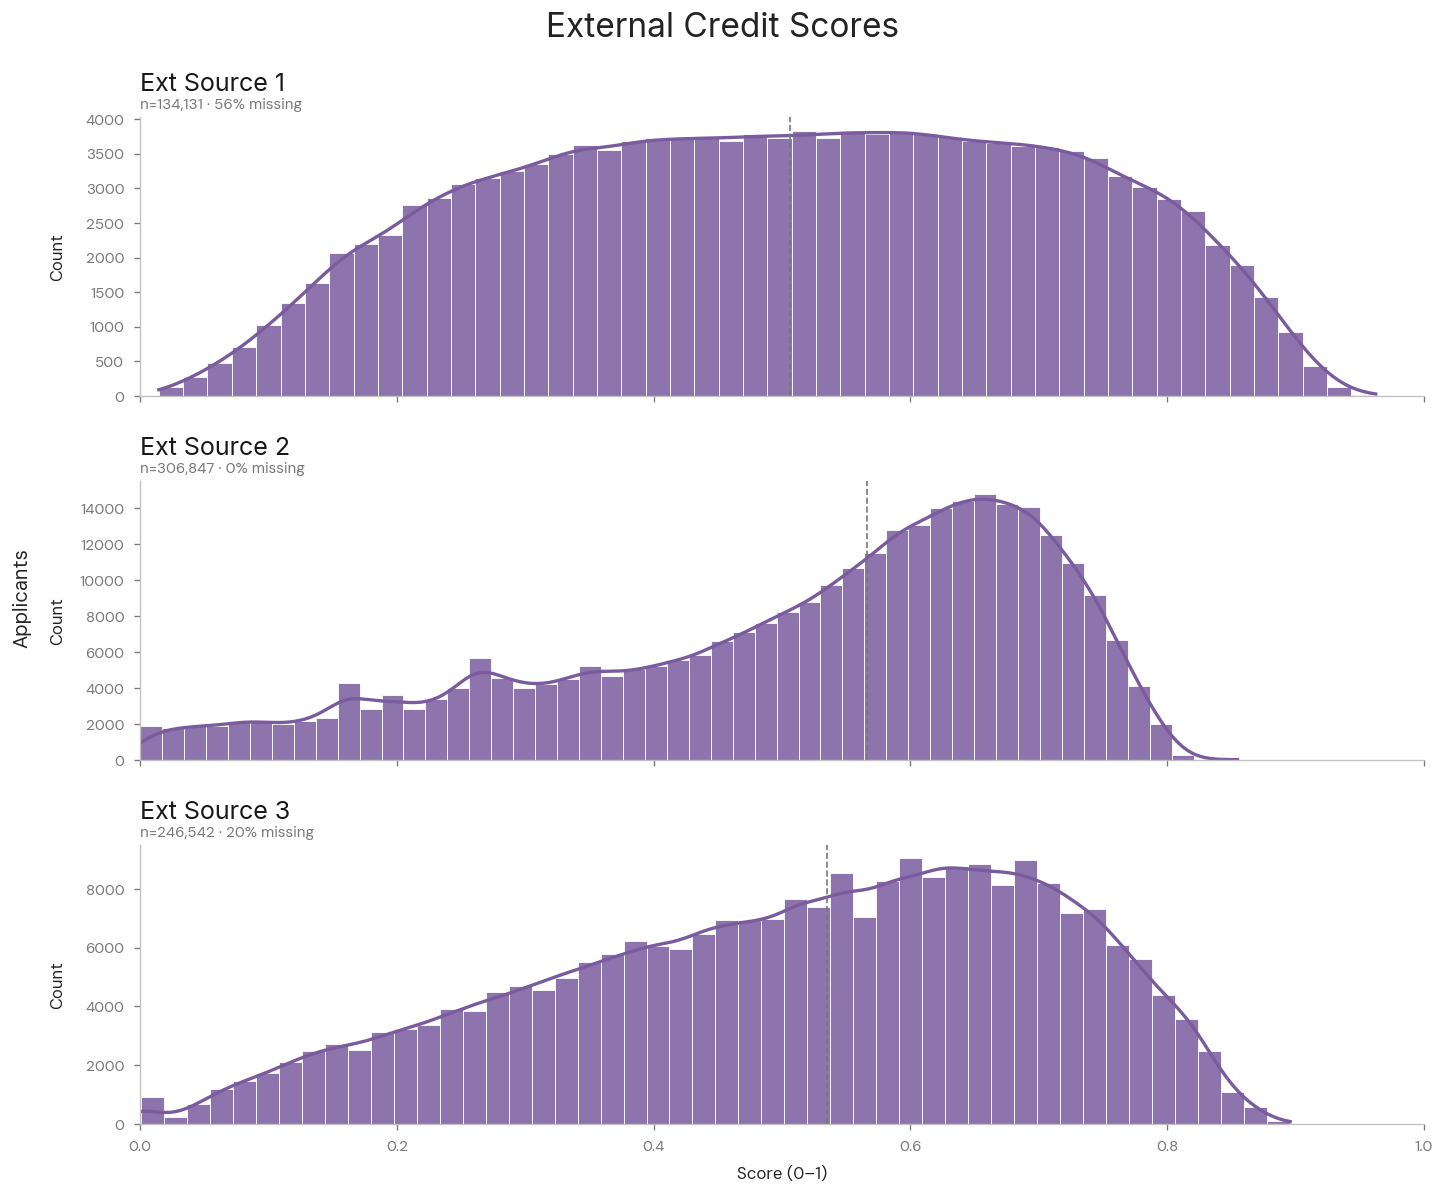

In [33]:
# External Scores Histograms

fig, axes = eda.histogram_per_group(
    df, cols_by_theme['external_scores'],
    ncols=1,                 # single column → stacked vertically
    panel_w=11, panel_h=3, # wider + taller per panel
    xlabel='Score (0–1)', sharex=True, kde=True,
)

# Axes Level Edits

for ax in axes:
    ax.set_xlim(0, 1)
    
# Figure Level Edits

fig.set_size_inches(12, 10)          # resize the whole figure
fig.suptitle('External Credit Scores', fontfamily=f('heading'), fontsize=s('display'))
# fig.supxlabel('Score (0–1)')         # one shared x-label for all panels
fig.supylabel('Applicants')          # one shared y-label
fig.subplots_adjust(hspace=0.4)      # gap between stacked panels
fig.align_ylabels()                  # line up y-labels across panels
fig.savefig('ext_scores.png', dpi=150, bbox_inches='tight')  # export

plt.show()

<BarContainer object of 3 artists>

Text(0, 0.5, 'External Score Provider')

Text(0.5, 0, 'Percentage of Data Missing')

Text(0.0, 1.0, 'EXT_SOURCE_2 Only Credit Score Provider With No Major Coverage Gaps')

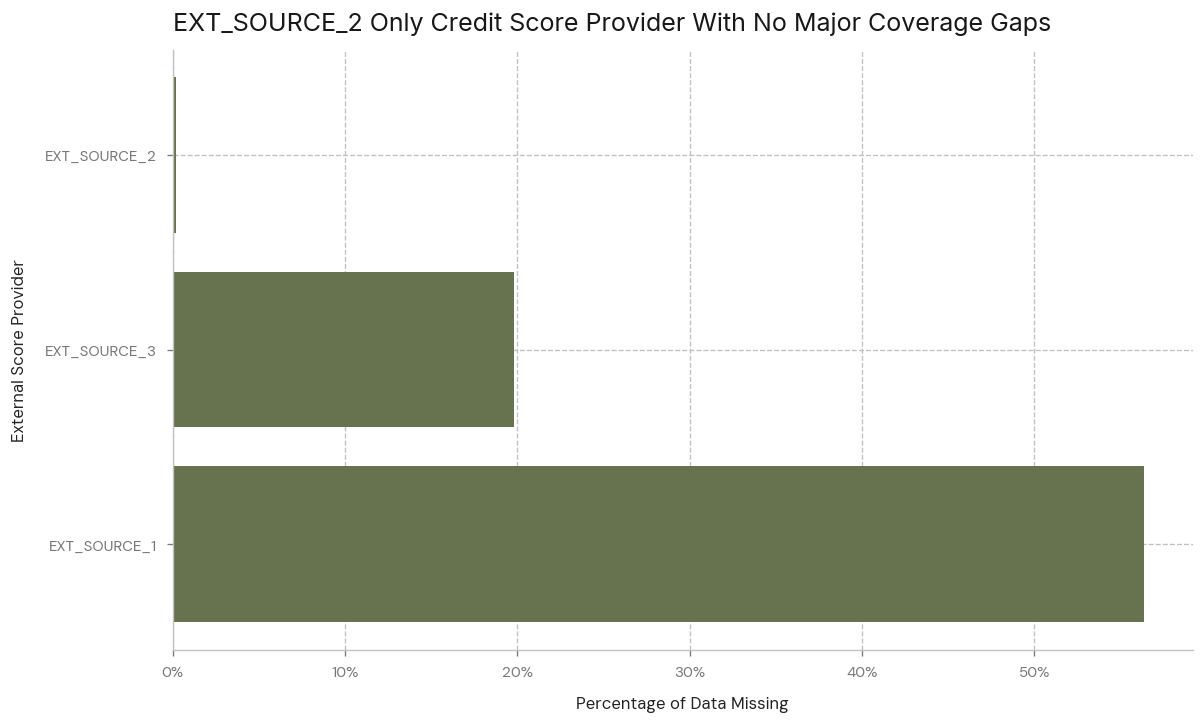

In [34]:
# External Scores Missingness

external_scores_missing = df[cols_by_theme['external_scores']].isnull().sum() / len(df)

external_scores_missing = external_scores_missing.sort_values(ascending=False)

fig, ax = plt.subplots(figsize = (10,6))

ax.barh(external_scores_missing.index, 
        external_scores_missing.values,
        color = C.tertiary,
        )

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylabel('External Score Provider', labelpad=10)
ax.set_xlabel('Percentage of Data Missing', labelpad=10)
ax.set_title('EXT_SOURCE_2 Only Credit Score Provider With No Major Coverage Gaps', fontsize=s('title'), fontfamily=f('heading'))
plt.show()


**Observation.** All three external scores sit on a bounded 0–1 scale with no extreme outliers, so they can be binned directly (no outlier trimming needed). Their shapes differ, which suggests each provider uses a different scoring methodology: EXT_SOURCE_1 is broadly symmetric (~0.5) but only 44% populated (56% missing); EXT_SOURCE_2 is left-skewed, peaks near 0.65 and is fully populated; EXT_SOURCE_3 is left-skewed, peaks near 0.65–0.70 and is ~80% populated. Bivariately all three separate the classes cleanly — defaulters concentrate at low scores — and default rate declines monotonically across quantile bins (low bin ~20–23%, high bin ~2–3%, vs the 8.1% base rate). Discrimination is close: Gini 0.36 / 0.33 / 0.31 (SOURCE_3/1/2) and KS 0.27 / 0.24 / 0.22, but coverage (100% / 80% / 44% for SOURCE_2/3/1) makes EXT_SOURCE_2 the most usable in practice. The differing shapes/coverage hint at complementary signal — quantified in the intercorrelation heatmap below.

#### Bivariate Analysis

##### Mean Score Comparison

Quickest bivariate view: the mean of each external score for defaulters vs non-defaulters. Useful as a headline, but it collapses each score to a single number — it says *whether* the groups differ, not *how* risk changes across the score range. The plots below add that shape.

[Text(0, 0, 'EXT_SOURCE_1'),
 Text(0, 1, 'EXT_SOURCE_2'),
 Text(0, 2, 'EXT_SOURCE_3')]

Text(0.5, 0, 'Mean external score')

Text(0.0, 1.0, 'Mean external score: default vs non-default')

[Text(10, 0, '0.39'), Text(10, 0, '0.41'), Text(10, 0, '0.39')]

[Text(10, 0, '0.51'), Text(10, 0, '0.52'), Text(10, 0, '0.52')]

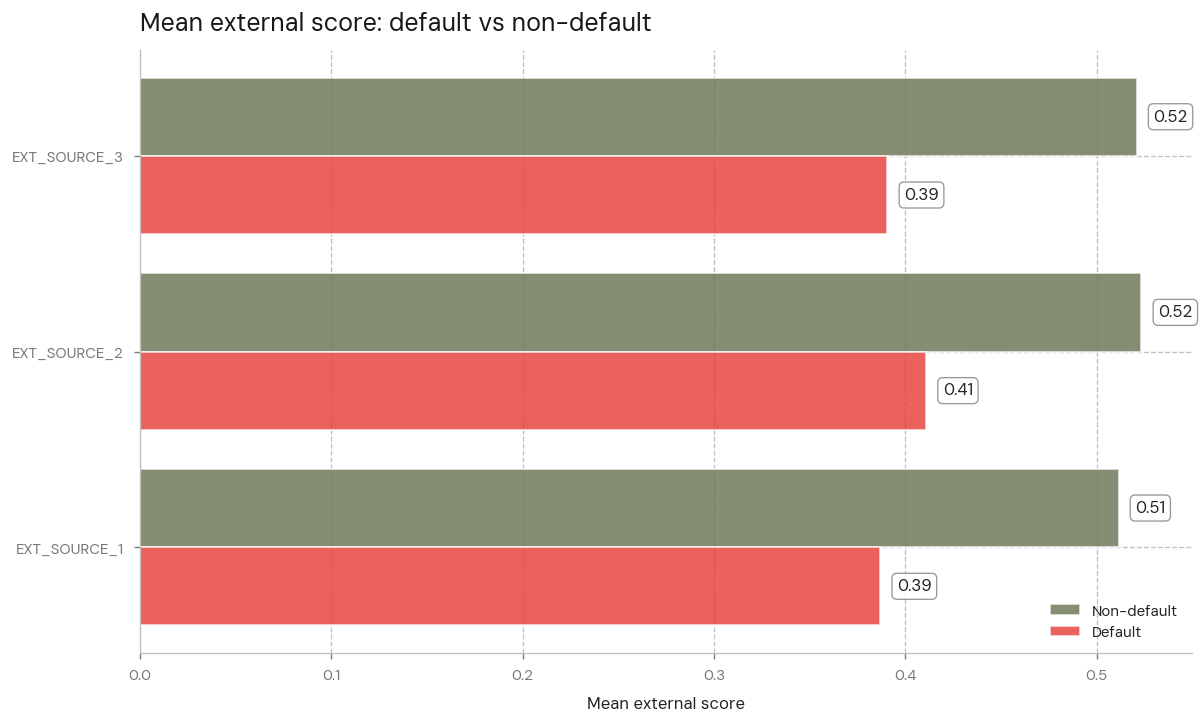

In [35]:
# External Scores Mean by Default Status

defaulters = df[cols_by_theme['external_scores']][df['TARGET'] == 1].mean()
non_defaulters = df[cols_by_theme['external_scores']][df['TARGET'] == 0].mean()

means = pd.DataFrame({'Default': defaulters, 'Non-default': non_defaulters})

x = np.arange(len(means))
w = 0.4

fig, ax = plt.subplots(figsize=(10,6))

bars_2 = ax.barh(x + w/2, means['Non-default'], w, label='Non-default', edgecolor='white', color=C.tertiary, alpha=0.8)
bars_1 = ax.barh(x - w/2, means['Default'],     w, label='Default', edgecolor='white', color=C.default, alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(means.index, rotation=0)
ax.set_xlabel('Mean external score')
ax.set_title('Mean external score: default vs non-default')
ax.legend()

ax.bar_label(bars_1,
             padding=10,
             fmt='%.2f',
             bbox=dict(
                 boxstyle='round',
                 facecolor='white',
                 edgecolor='grey',
                 alpha = 0.8,
                 linewidth=0.8
             ))

ax.bar_label(bars_2,
             padding=10,
             fmt='%.2f',
             bbox=dict(
                 boxstyle='round',
                 facecolor='white',
                 edgecolor='grey',
                 alpha = 0.8,
                 linewidth=0.8
             ))

plt.show()


##### Histogram

(0.0, 1.0)

(0.0, 1.0)

(0.0, 1.0)

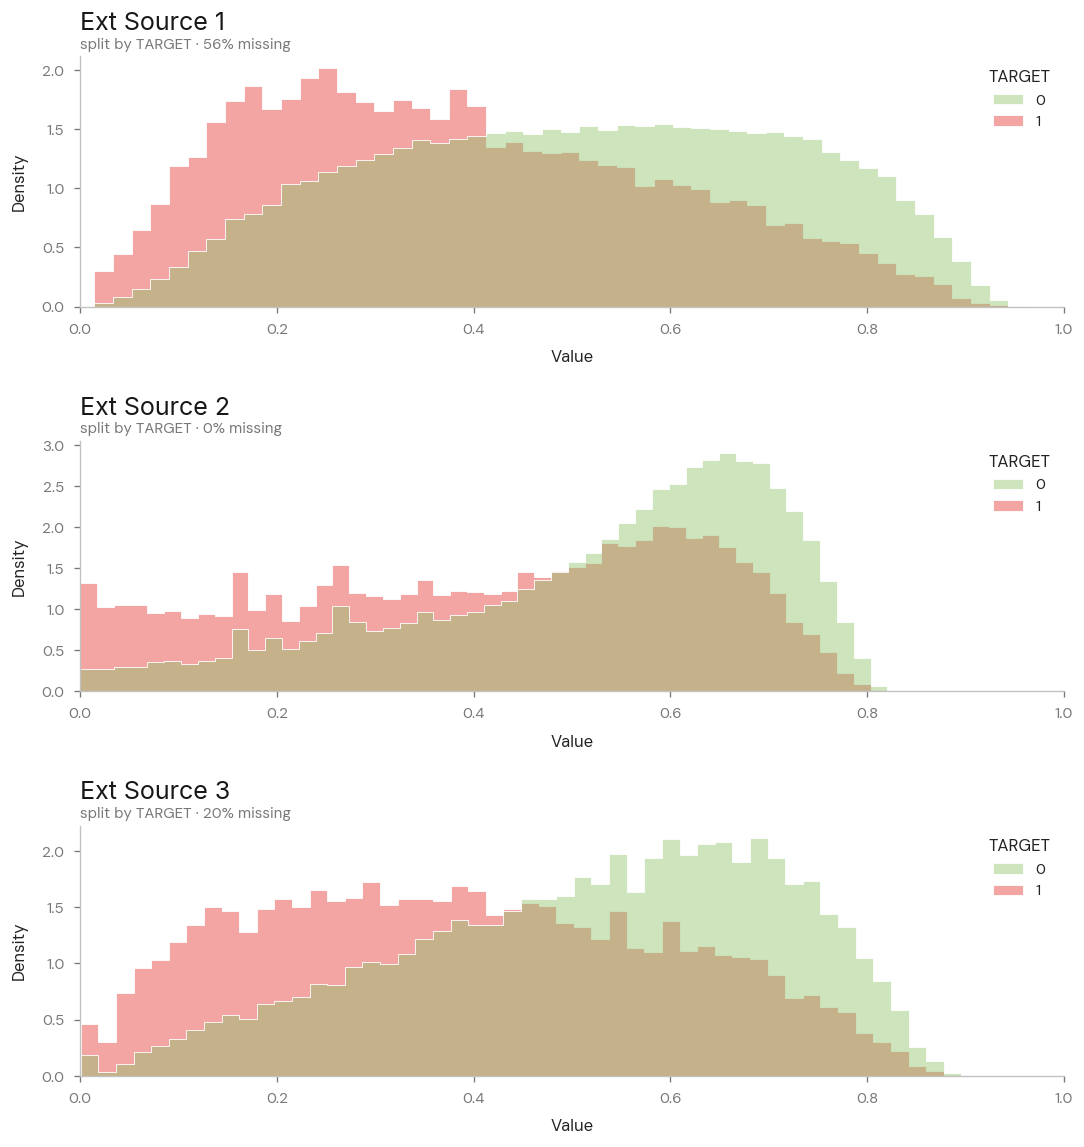

In [36]:
# External Scores Histograms

from credit_utils.eda import overlaid_histogram_per_group

fig, axes = overlaid_histogram_per_group(
    df, cols_by_theme['external_scores'], by='TARGET', ncols=1, edgecolor='white',
    palette={0: '#6D5FB3', 1: '#E1A100'}  # colour-blind-safe: non-default=purple, default=gold
)

# Axes Level Edits

for ax in axes:
    ax.set_xlim(0, 1)
    
# Figure Level Edits


plt.show()

##### Default Rate by Bin

The workhorse bivariate plot. Each score is cut into deciles (equal-population quantile bins) and we plot the **default rate within each bin**. This shows the *shape* of the risk relationship — ideally a clean monotonic decline (higher score → lower default rate), which is what justifies using the score in a scorecard. The dashed line is the overall (base) default rate, so bins above it are higher-than-average risk. Binning a continuous feature this way is the same operation as default-rate-per-category, so this is the one chart that unifies continuous and categorical predictors.

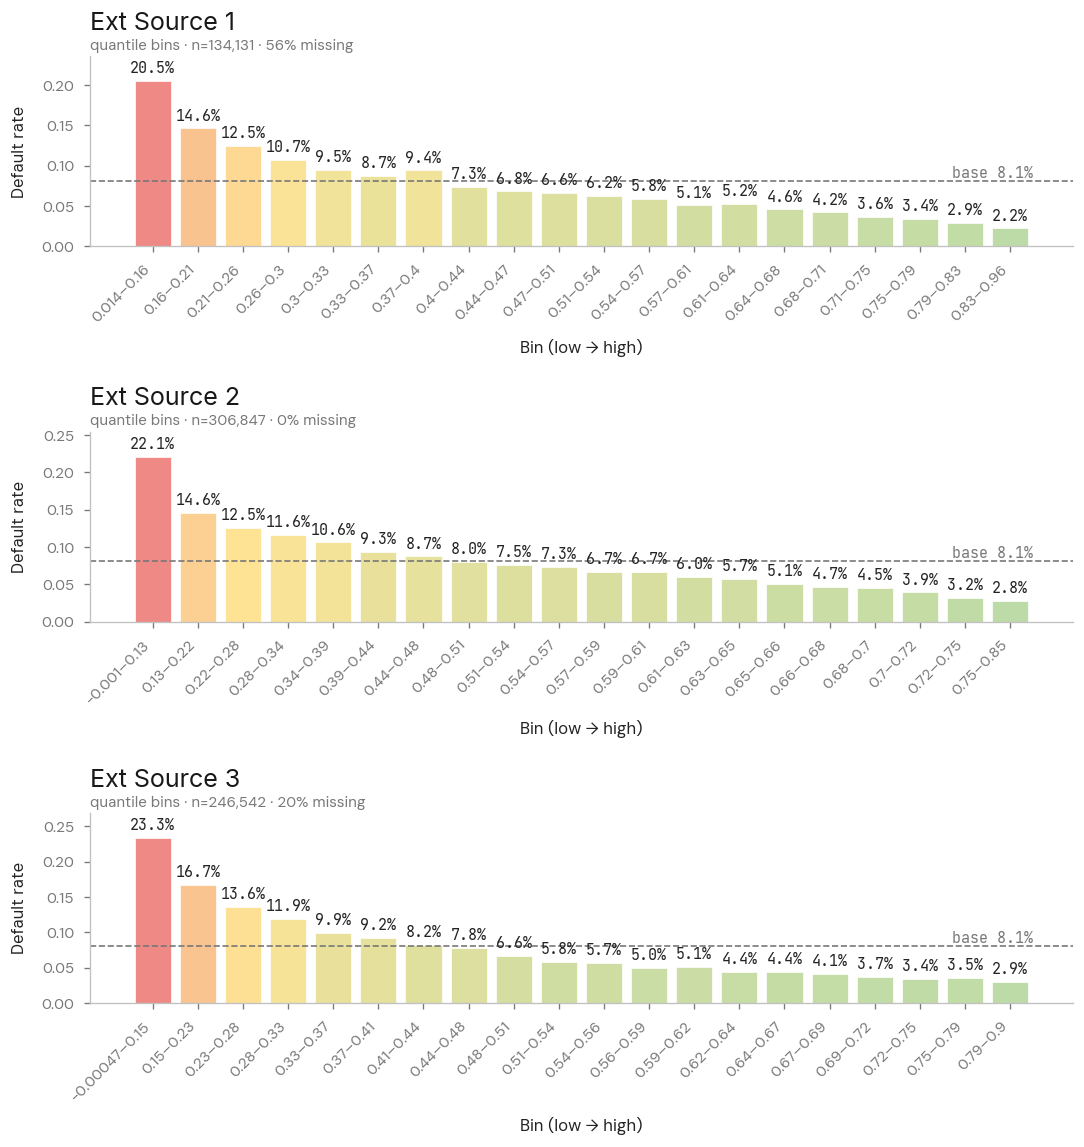

In [37]:
# External Scores Default Rate by Bin

# AI generated function for assessing default rate by bin

from credit_utils.eda import default_rate_by_bin

fig, axes = default_rate_by_bin(
    df, cols_by_theme['external_scores'], target='TARGET', ncols=1, bins=20
)

# Axes-level edits
# for ax in axes:
#     ax.set_ylim(0, 0.2)

plt.show()

##### Discrimination (AUC / Gini)

These features are themselves credit scores, so we can measure how well each one separates defaulters from non-defaulters on its own with ROC-AUC (and Gini = 2·AUC − 1, the metric the industry ranks scores by). One number per score, directly comparable. The score is negated so that *low score = high risk* aligns with the positive (default) class; an AUC well above 0.5 means real signal. `coverage` is the non-missing share, a reminder that a strong-but-sparse score may contribute less in practice.

_Why discrimination metrics appear only here:_ AUC / Gini / KS measure how well an existing **score** ranks risk, so they belong with the external scores — which are pre-built risk scores, benchmarked in their native industry metric (Gini). Raw features (income, age, …) are screened with **IV / WOE** instead, since an uncalibrated or non-monotonic feature can have a low AUC yet a high IV.

In [38]:
# Import

from sklearn.metrics import roc_auc_score

# The accumulator

auc_rows = []

# loop through column list

for c in cols_by_theme['external_scores']:
    
    m = df[c].notna()       # Mask for missing values 
    
    auc = roc_auc_score(df.loc[m, 'TARGET'], -df.loc[m, c])   # Calculate auc
    
    auc_rows.append({'feature' : c,             # Create dictionary to print scores for the column
                     'AUC': round(auc, 3),
                     'Gini': round(2 * auc -1, 3),
                     'coverage': round(m.mean(), 3)})
    
# Turn into a df for display 
    
auc_df = (pd.DataFrame(auc_rows)
          .sort_values('Gini', ascending=False)
          .reset_index(drop=True))

auc_df

,feature,AUC,Gini,coverage
0,EXT_SOURCE_3,0.68,0.36,0.80
1,EXT_SOURCE_1,0.67,0.33,0.44
2,EXT_SOURCE_2,0.66,0.31,1.00


##### Separation (KS & ECDF)

The Kolmogorov–Smirnov statistic is the classic scoring separation measure: the maximum vertical gap between the cumulative distributions (ECDFs) of the two classes. Plotting both ECDFs makes the separation something you can read straight off the chart — a bigger gap means the score pushes defaulters and non-defaulters apart more cleanly. KS and AUC usually agree on the ranking.

##### KS Statistics

In [39]:
from scipy.stats import ks_2samp

#  Accumulator

ks_rows = []

# Loop through columns

for c in cols_by_theme['external_scores']:
    
    m = df[c].notna()  # mask out missing values
    
    d = df.loc[m & (df['TARGET'] == 1), c]  # Defaulter Scores
    n = df.loc[m & (df['TARGET'] == 0), c]  # Non Defaulter Scores
    
    stat, p = ks_2samp(d, n)  # KS Stat + P-value
    
    ks_rows.append({'feature': c,
                    'KS': round(stat, 3),
                    'p_value': round(p, 4),
                    'coverage': round (m.mean(), 3)})
    
    
ks_df = (pd.DataFrame(ks_rows).sort_values('KS', ascending=False).reset_index(drop=True))

ks_df

,feature,KS,p_value,coverage
0,EXT_SOURCE_3,0.27,0.00,0.80
1,EXT_SOURCE_1,0.24,0.00,0.44
2,EXT_SOURCE_2,0.22,0.00,1.00


##### ECDF Plot

Text(0.0, 1.0, 'EXT_SOURCE_1  (KS = 0.243)')

Text(0.5, 0, 'Score (0–1)')

Text(0, 0.5, 'Cumulative share')

Text(0.0, 1.0, 'EXT_SOURCE_2  (KS = 0.224)')

Text(0.5, 0, 'Score (0–1)')

Text(0, 0.5, 'Cumulative share')

Text(0.0, 1.0, 'EXT_SOURCE_3  (KS = 0.270)')

Text(0.5, 0, 'Score (0–1)')

Text(0, 0.5, 'Cumulative share')

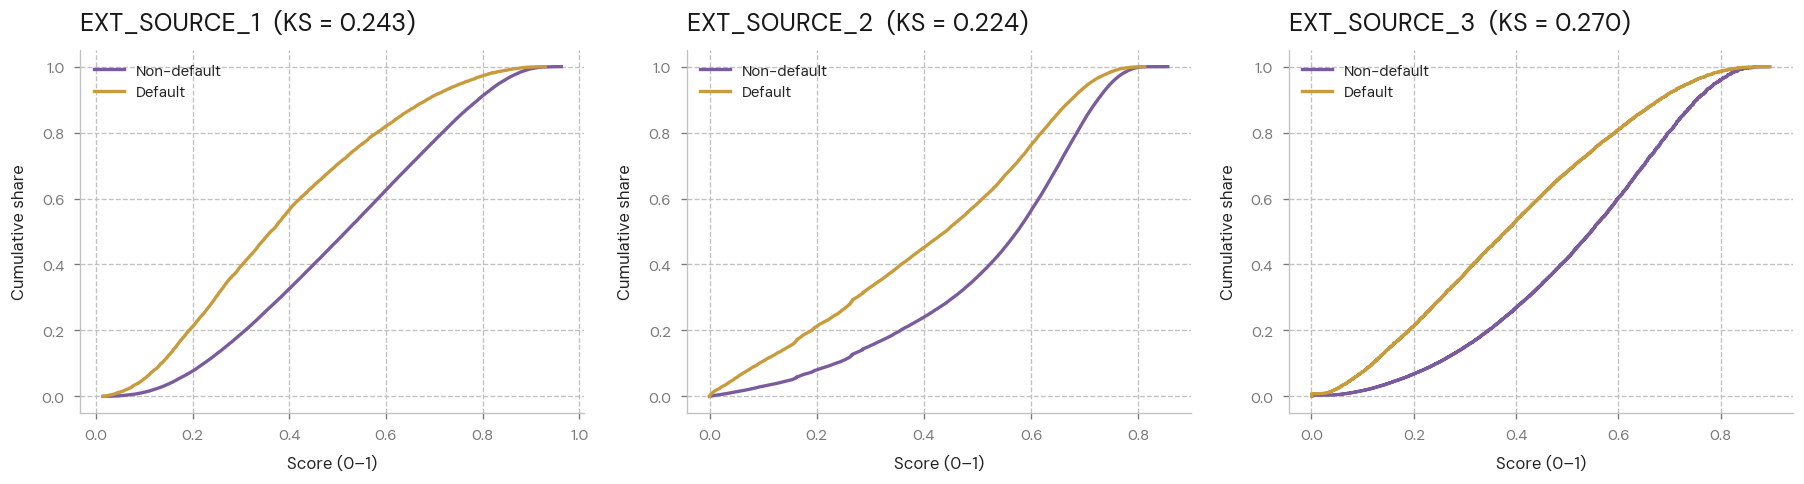

In [40]:
# External Scores ECDF by Default Status

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, c in zip(axes, cols_by_theme['external_scores']):
    
    m = df[c].notna()
    d = df.loc[m & (df['TARGET'] == 1), c]  # Defaulter Scores
    n = df.loc[m & (df['TARGET'] == 0), c]  # Non Defaulter Scores
    
    for grp, label in [(n, 'Non-default'), (d, 'Default')]:
        
        x = np.sort(grp)
        y = np.arange(1, len(x) + 1 )/ len(x)
        ax.plot(x, y, label=label)
        
    stat, _ = ks_2samp(d, n)
    
    ax.set_title(f'{c}  (KS = {stat:.3f})')              # KS in the title
    ax.set_xlabel('Score (0–1)')
    ax.set_ylabel('Cumulative share')
    ax.legend()
    
plt.show()

##### Score Intercorrelation

Not a target relationship, but essential context: with three external scores we need to know how much they overlap. Highly correlated scores carry redundant signal (only some will survive feature selection / add incremental lift); weakly correlated ones are more likely to each pull their weight in the model.

In [ ]:
# External Score Intercorrelation
# With three external scores, we want to know how much they overlap.
# High correlation => redundant signal (only some survive feature selection);
# low correlation => each score likely adds independent lift.

ext_cols = cols_by_theme['external_scores']

# .corr() is pairwise-complete: for each pair it uses rows where BOTH scores are present,
# so the ~56% missingness in EXT_SOURCE_1 doesn't blank out the whole matrix.
ext_corr = df[ext_cols].corr()
print(ext_corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    ext_corr,
    cmap='Blues',              # neutral sequential (avoids red/green 'good/bad' read)
    vmin=0, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 12},
    square=True, linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'},
    ax=ax,
)
ax.set_title('External score intercorrelation',
             fontfamily=f('heading'), fontsize=s('title'))
plt.show()


**Observation / Decision.** All three external scores separate defaulters from non-defaulters cleanly and monotonically (default rate falls from ~20–23% in the lowest quantile bin to ~2–3% in the highest, against the 8.1% base). Discrimination is solid and close (Gini 0.31–0.36; KS 0.22–0.27), EXT_SOURCE_3 strongest, EXT_SOURCE_2 the most usable at full coverage. **Decision:** carry all three into Section 5 as quantile-binned WOE features, with **missing treated as its own bin** (missingness is itself informative — EXT_SOURCE_1 is 56% missing). Retain all three pending the intercorrelation check below; drop or combine only if a pair proves strongly redundant (|r| > ~0.7).

### 3.2 Loan Financials

**Explanation.** Loan-financial amounts (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`) describe loan size and affordability. Expect heavy right-skew and outliers; the question is log-transform vs quantile bins.

#### Univariate Analysis

In [41]:
cols_by_theme.keys()

dict_keys(['id_target', 'external_scores', 'loan_financials', 'demographics', 'employment', 'assets', 'contact', 'client_timeline', 'application_timing', 'region', 'building_stats', 'social_circle', 'document_flags', 'bureau_enquiries'])

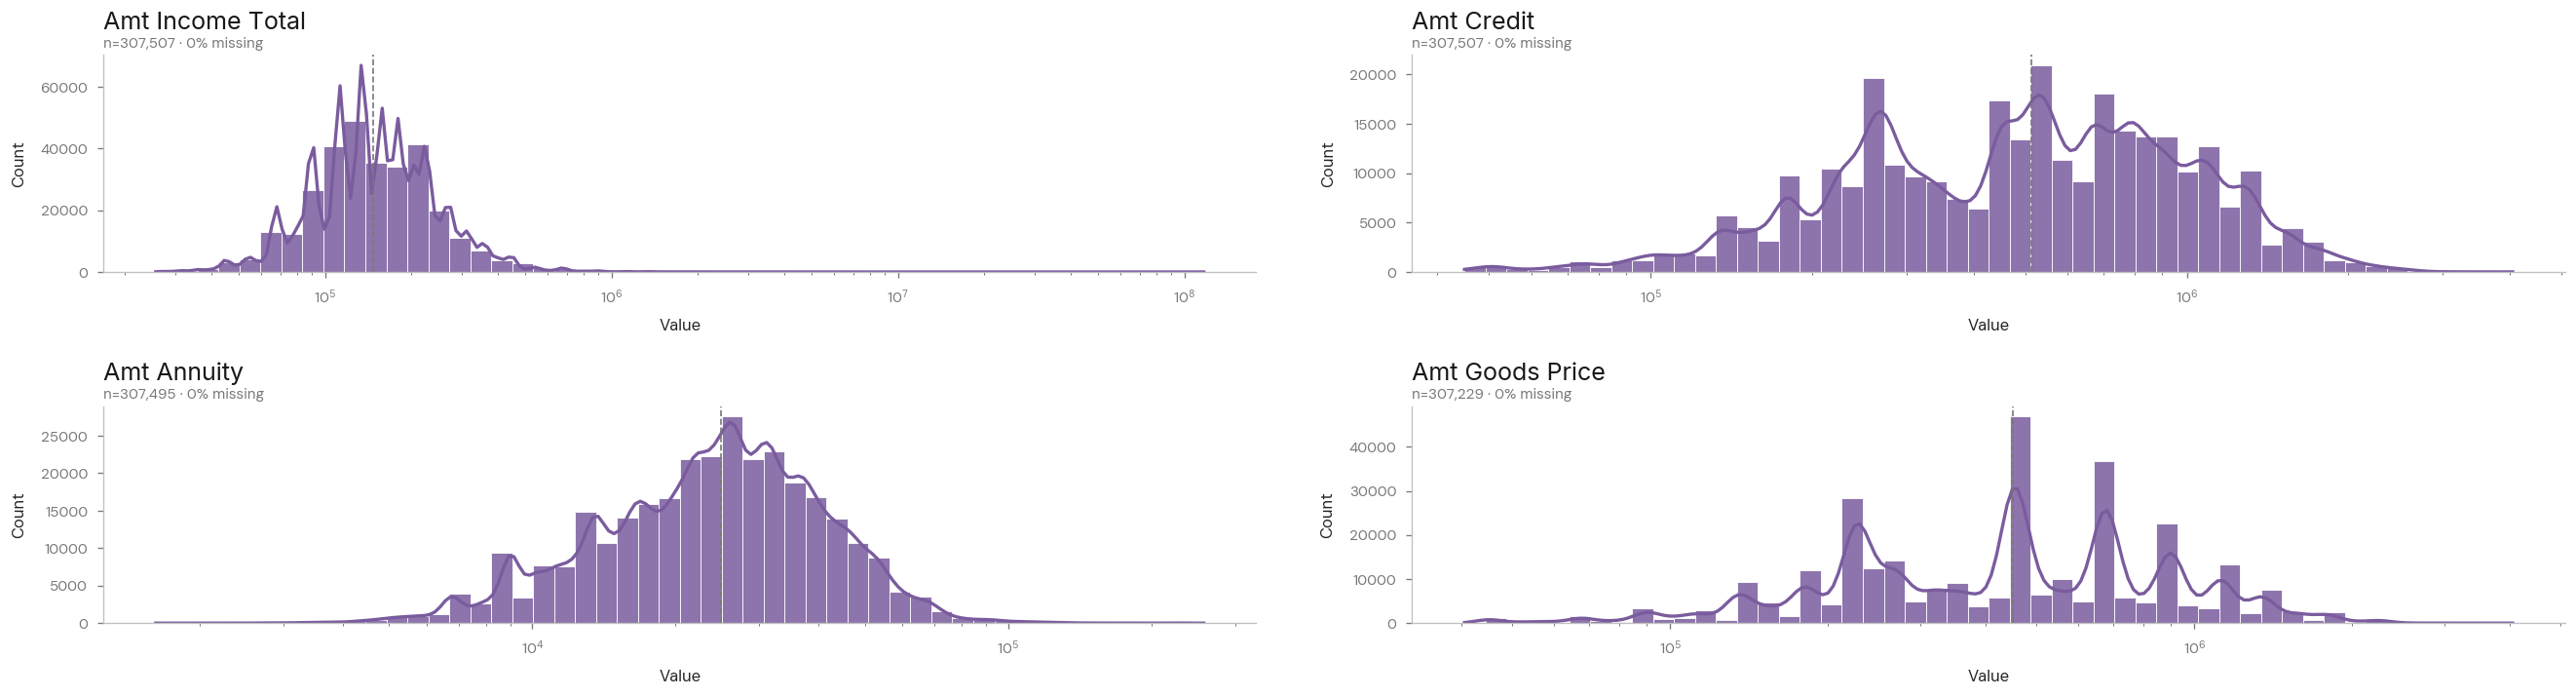

In [42]:
# Loan Financials Numeric Variables Histograms

fig, axes = eda.histogram_per_group(
    df, cols_by_theme['loan_financials'],
    ncols=2,                 # single column → stacked vertically
    panel_w=11, panel_h=3, # wider + taller per panel
    sharex=False, kde=True, logx=True
)

# Axes Level Edits

for ax in axes:
    ax.set_xscale('log')


plt.show()

(<Figure size 1680x480 with 2 Axes>,
 array([<Axes: title={'left': 'Name Contract Type'}, xlabel='Count'>, <Axes: >], dtype=object))

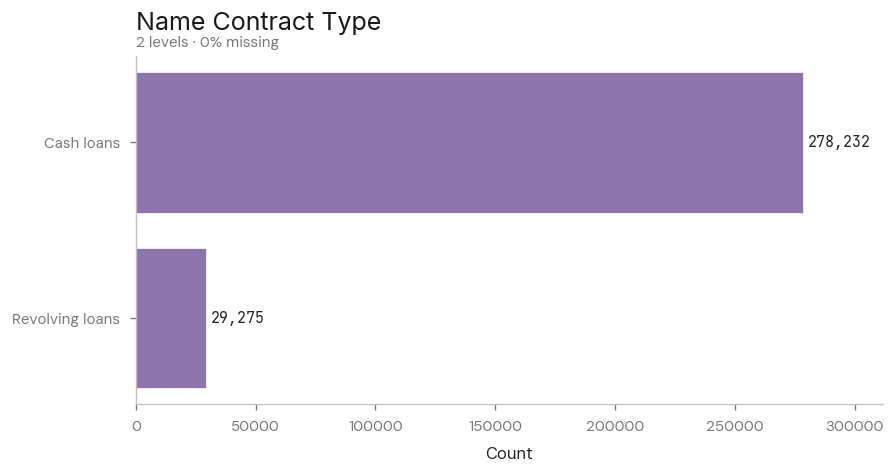

In [43]:
# Loan Financials Categorical Bar Counts

eda.frequency_per_group(df, cols_by_theme['loan_financials'])   # → only NAME_CONTRACT_TYPE
plt.show()

**Observation.** All four loan-financial amounts are heavily right-skewed even on a log axis, with extreme upper tails — AMT_INCOME_TOTAL reaches ~$100M (a clear outlier), and AMT_CREDIT / AMT_GOODS_PRICE are multimodal with spikes at round product prices; AMT_ANNUITY is the smoothest (roughly log-normal). Coverage is effectively complete (~0% missing). NAME_CONTRACT_TYPE has two levels (Cash 90.5% / Revolving 9.5%). Because of the skew and outliers, mean-based summaries mislead; quantile (rank-based) binning is robust to the tails, so no outlier trimming or log transform is needed for WOE — the log axis is a visualisation aid only.

#### Bivariate Analysis

In [44]:
df[cols_by_theme['loan_financials']]

,NAME_CONTRACT_TYPE,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
0,Cash loans,202500.00,406597.50,24700.50,351000.00
1,Cash loans,270000.00,1293502.50,35698.50,1129500.00
2,Revolving loans,67500.00,135000.00,6750.00,135000.00
3,Cash loans,135000.00,312682.50,29686.50,297000.00
4,Cash loans,121500.00,513000.00,21865.50,513000.00
...,...,...,...,...,...
307506,Cash loans,157500.00,254700.00,27558.00,225000.00
307507,Cash loans,72000.00,269550.00,12001.50,225000.00
307508,Cash loans,153000.00,677664.00,29979.00,585000.00
307509,Cash loans,171000.00,370107.00,20205.00,319500.00


[Text(0, 0, 'Amt Income Total'),
 Text(0, 1, 'Amt Credit'),
 Text(0, 2, 'Amt Annuity'),
 Text(0, 3, 'Amt Goods Price')]

Text(0.5, 0, 'Dollar Amount ($)')

Text(0.0, 1.0, 'Mean Values by Default Status for Loan Financials ')

[Text(10, 0, '$165,611.76'),
 Text(10, 0, '$557,778.53'),
 Text(10, 0, '$26,481.74'),
 Text(10, 0, '$488,972.41')]

[Text(10, 0, '$169,077.47'),
 Text(10, 0, '$602,651.16'),
 Text(10, 0, '$27,163.73'),
 Text(10, 0, '$542,738.51')]

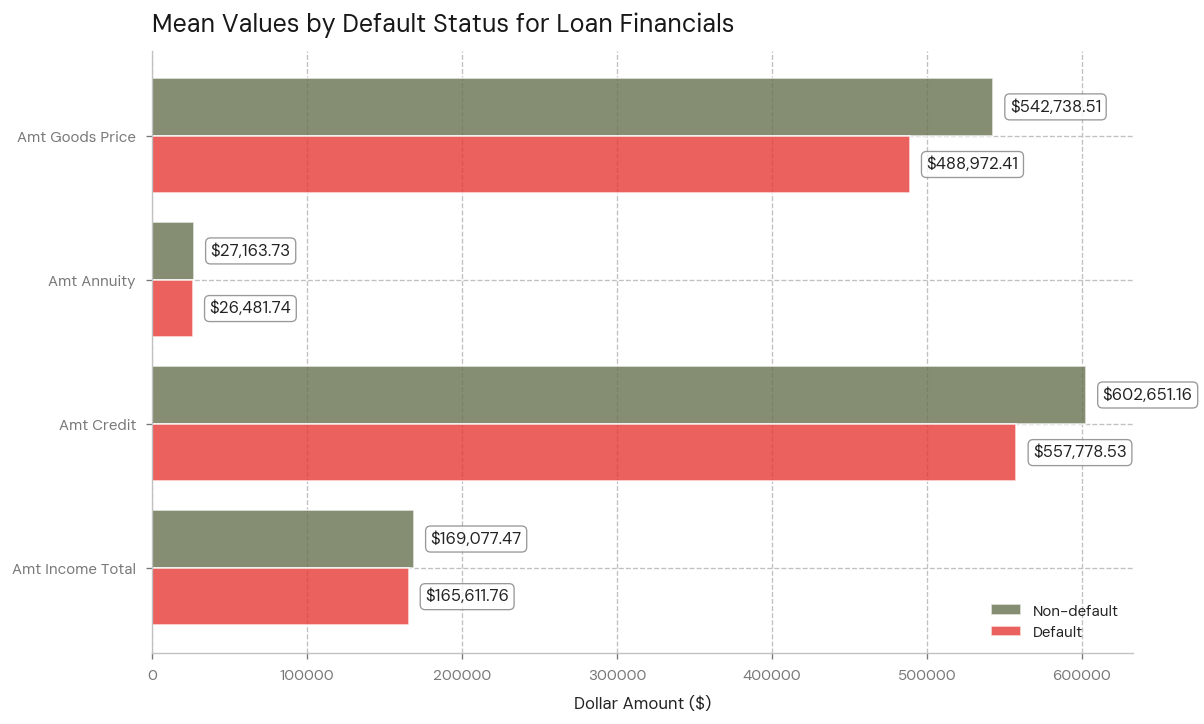

In [45]:
# Loan Financials Mean by Default Status

cols = [c for c in cols_by_theme['loan_financials'] if c != 'NAME_CONTRACT_TYPE']

defaulters = df[cols][df['TARGET'] == 1].mean()
non_defaulters = df[cols][df['TARGET'] == 0].mean()

means = pd.DataFrame({'Default': defaulters, 'Non-default': non_defaulters})

x = np.arange(len(means))
w = 0.4

fig, ax = plt.subplots(figsize=(10,6))

bars_2 = ax.barh(x + w/2, means['Non-default'], w, label='Non-default', edgecolor='white', color=C.tertiary, alpha=0.8)
bars_1 = ax.barh(x - w/2, means['Default'],     w, label='Default', edgecolor='white', color=C.default, alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(means.index.str.replace('_', ' ').str.title(), rotation=0)
ax.set_xlabel('Dollar Amount ($)')
ax.set_title('Mean Values by Default Status for Loan Financials ')
ax.legend()

ax.bar_label(bars_1,
             padding=10,
             fmt='${:,.2f}',
             bbox=dict(
                 boxstyle='round',
                 facecolor='white',
                 edgecolor='grey',
                 alpha = 0.8,
                 linewidth=0.8
             ))

ax.bar_label(bars_2,
             padding=10,
             fmt='${:,.2f}',
             bbox=dict(
                 boxstyle='round',
                 facecolor='white',
                 edgecolor='grey',
                 alpha = 0.8,
                 linewidth=0.8
             ))

plt.show()


['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']


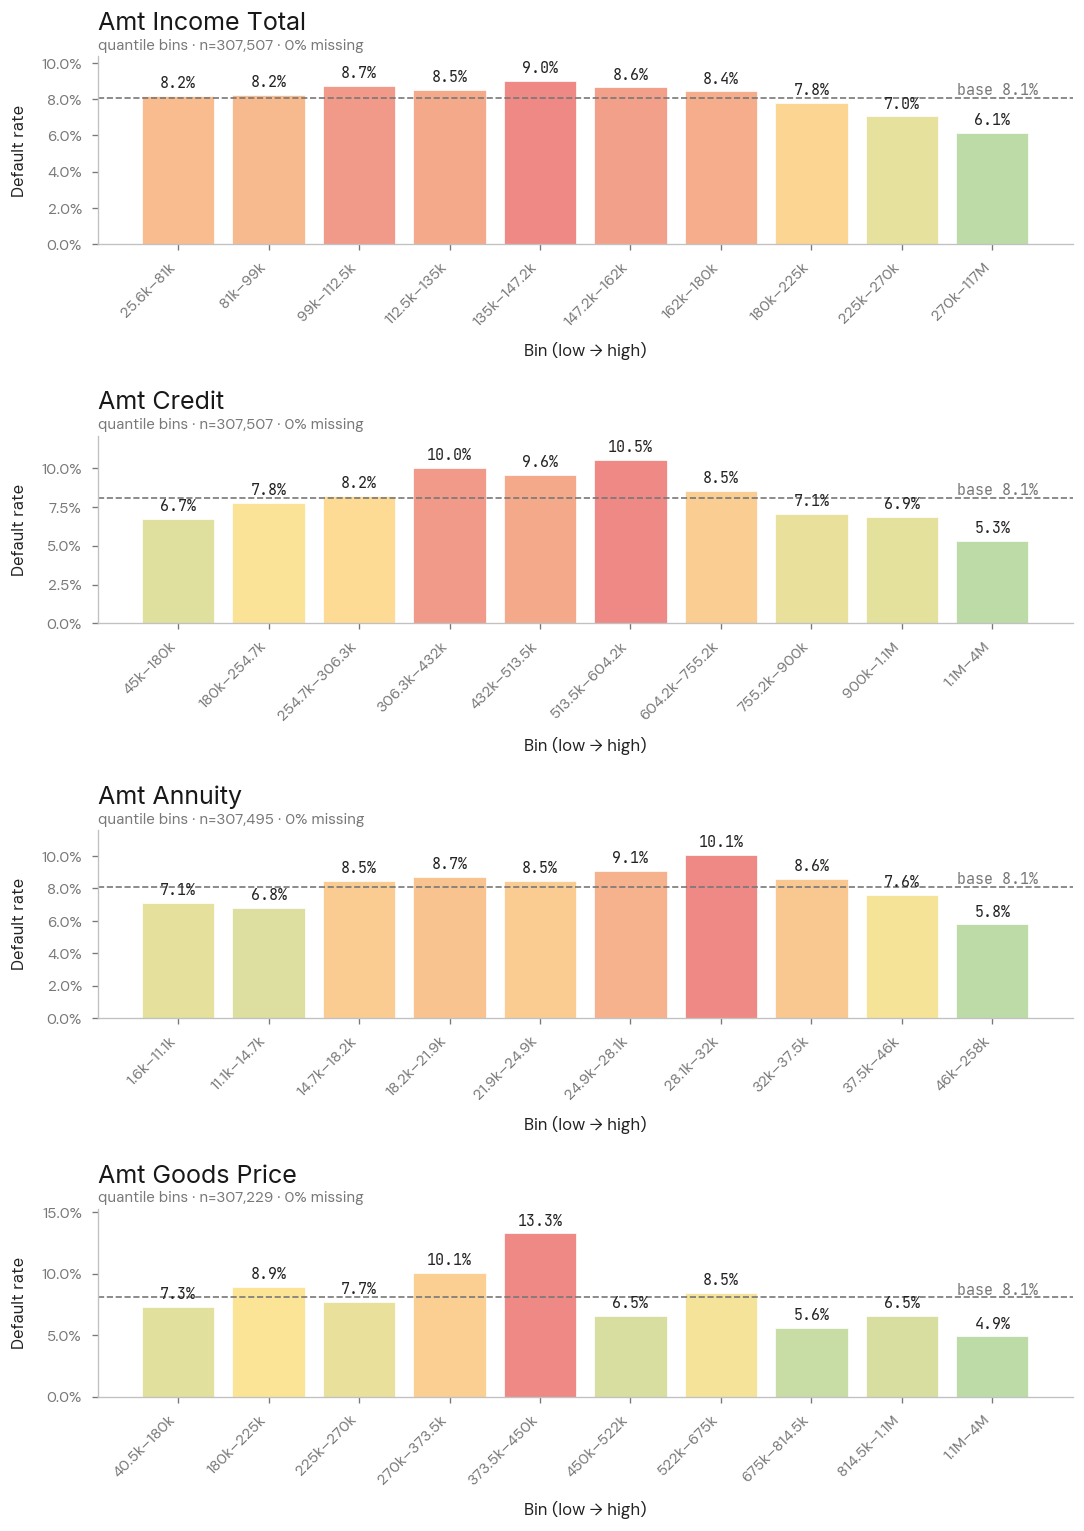

In [46]:
# Loan Financials Default Rate by Bin

numeric_cols = [c for c in df[cols_by_theme['loan_financials']] if c != 'NAME_CONTRACT_TYPE']

print(numeric_cols)

# AI generated function for assessing default rate by bin

from credit_utils.eda import default_rate_by_bin

fig, axes = default_rate_by_bin(
    df, numeric_cols, target='TARGET', ncols=1, bins=10, method = 'quantile'
)

# Axes-level edits
for ax in axes:
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    # ax.set_xticks(range(len(rate)))

plt.show()

NAME_CONTRACT_TYPE
Cash loans        0.90
Revolving loans   0.10
Name: proportion, dtype: float64

[Text(10, 0, '90.5%'), Text(10, 0, '9.5%')]

(-0.6, 1.6)

Text(0.0, 1.0, 'Class Imbalance for Contract Type')

Text(0.5, 0, 'Percentage of Borrowers')

Text(0, 0.5, 'Contract Type')

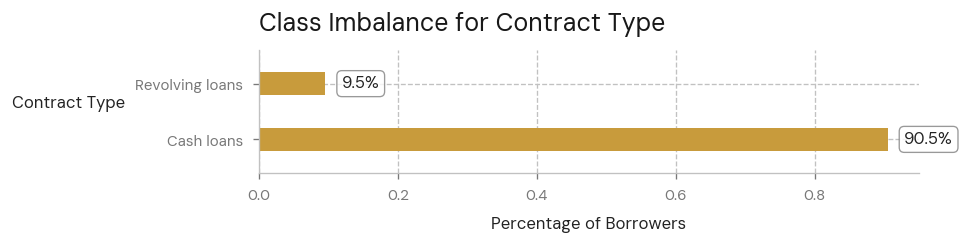

In [47]:
# Contract Type Class Imbalance

contract_type = df['NAME_CONTRACT_TYPE'].value_counts(normalize=True)

contract_type.head(5)

labels = ['Cash Loans', 'Revolving Loans']
y = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8,2))

bars_1 = ax.barh(contract_type.index, contract_type.values, color=C.secondary, height = 0.4)

ax.bar_label(bars_1,
             padding=10,
             fmt='{:.1%}',
             bbox=dict(
                 boxstyle='round',
                 facecolor='white',
                 edgecolor='grey',
                 alpha = 0.8,
                 linewidth=0.8
             ))

ax.set_ylim(-0.6, 1.6)

ax.set_title('Class Imbalance for Contract Type')
ax.set_xlabel('Percentage of Borrowers')
ax.set_ylabel('Contract Type', rotation=0, labelpad=40)
plt.show()


NAME_CONTRACT_TYPE
Cash loans        0.08
Revolving loans   0.05
Name: TARGET, dtype: float64

Text(0.0, 1.0, 'Default Rate by Contract Status')

Text(0.5, 0, 'Default Rate')

[Text(10, 0, '8.3%'), Text(10, 0, '5.5%')]

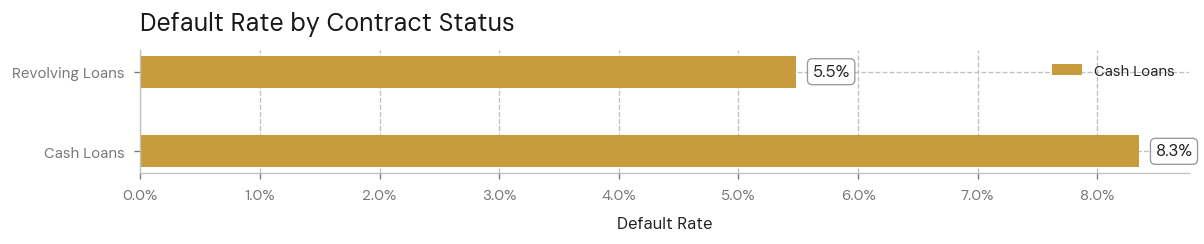

In [48]:
# Default Rate by Contract Type

default_rate = df.groupby('NAME_CONTRACT_TYPE', dropna=False)['TARGET'].mean()

default_rate.head(5)

fig, ax = plt.subplots(figsize=(10,2))

labels = ['Cash Loans', 'Revolving Loans']
y = np.arange(len(labels))
h = 0.4

bars_1 = ax.barh(y, default_rate, height = 0.4, label='Cash Loans', color = C.secondary)
ax.set_yticks(y, labels)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax.set_title('Default Rate by Contract Status')
ax.set_xlabel('Default Rate')
ax.legend()

ax.bar_label(bars_1,
             padding=10,
             fmt='{:.1%}',
             bbox=dict(
                 boxstyle='round',
                 facecolor='white',
                 edgecolor='grey',
                 alpha = 0.8,
                 linewidth=0.8
             ))

plt.show()

**Observation / Decision.** As raw amounts these are weak, non-monotonic drivers: default rate vs quantile bin is near-flat for AMT_INCOME_TOTAL and an inverted-U for AMT_CREDIT / AMT_ANNUITY / AMT_GOODS_PRICE — the mid-range is riskiest (borrowers stretched closest to their limit on an average income), tapering at both ends. The mean-by-status view (defaulters marginally lower on every amount) is misleading because it averages out that inverted-U. Bins are equal-population quantiles (~30k each), so these shapes are stable signal, not sparse-bin noise. Contract type is a mild categorical driver (cash 8.3% vs revolving 5.5% default).

**Decision:** carry the raw amounts as quantile-binned WOE features but expect **low IV** — the real signal lives in affordability **ratios** built in Section 4: repayment-to-income (AMT_ANNUITY/AMT_INCOME ≈ serviceability / NSR), loan-to-income (AMT_CREDIT/AMT_INCOME ≈ leverage), and loan-to-value (AMT_CREDIT/AMT_GOODS_PRICE ≈ LVR; >1 flags financing beyond the asset value). No log transform needed for binning (quantiles are rank-invariant and robust to the income outlier); keep raw scale for WOE. NAME_CONTRACT_TYPE binned as-is (2 levels).

### 3.3 Age and Employment

**Explanation.** Age & employment (`DAYS_BIRTH`, `DAYS_EMPLOYED`) — convert to positive years (`/-365`). `DAYS_EMPLOYED` carries the sentinel value flagged in 2.3, so it needs a bin plus a missing flag.

#### Univariate Analysis

Text(0.5, 0, 'Years')

Text(0.5, 0, 'Years')

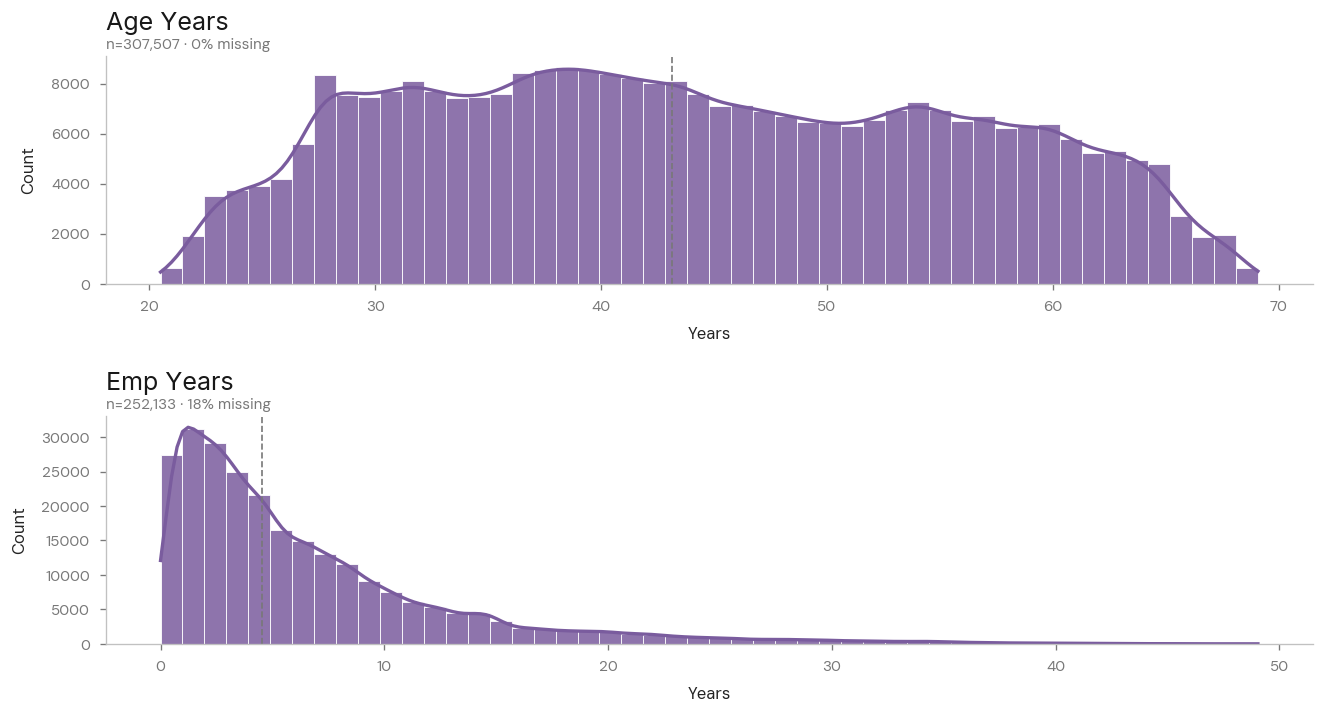

In [49]:

# Age and Employment Numeric Variables Histograms

df_age_years = df.copy()
df_age_years['AGE_YEARS'] = -df_age_years['DAYS_BIRTH']    / 365.25
df_age_years['EMP_YEARS'] =- df_age_years['DAYS_EMPLOYED'] / 365.25

cols_of_interest = ['AGE_YEARS', 'EMP_YEARS']

fig, axes = eda.histogram_per_group(
    df_age_years, cols_of_interest,
    ncols=1,                 # single column → stacked vertically
    panel_w=11, panel_h=3, # wider + taller per panel
    sharex=False, kde=True, logx=False
)

# Axes Level Edits

for ax in axes:
    ax.set_xlabel("Years")

plt.show()

(<Figure size 1680x960 with 4 Axes>,
 array([<Axes: title={'left': 'Name Income Type'}, xlabel='Count'>,
        <Axes: title={'left': 'Occupation Type'}, xlabel='Count'>,
        <Axes: title={'left': 'Organization Type'}, xlabel='Count'>, <Axes: >], dtype=object))

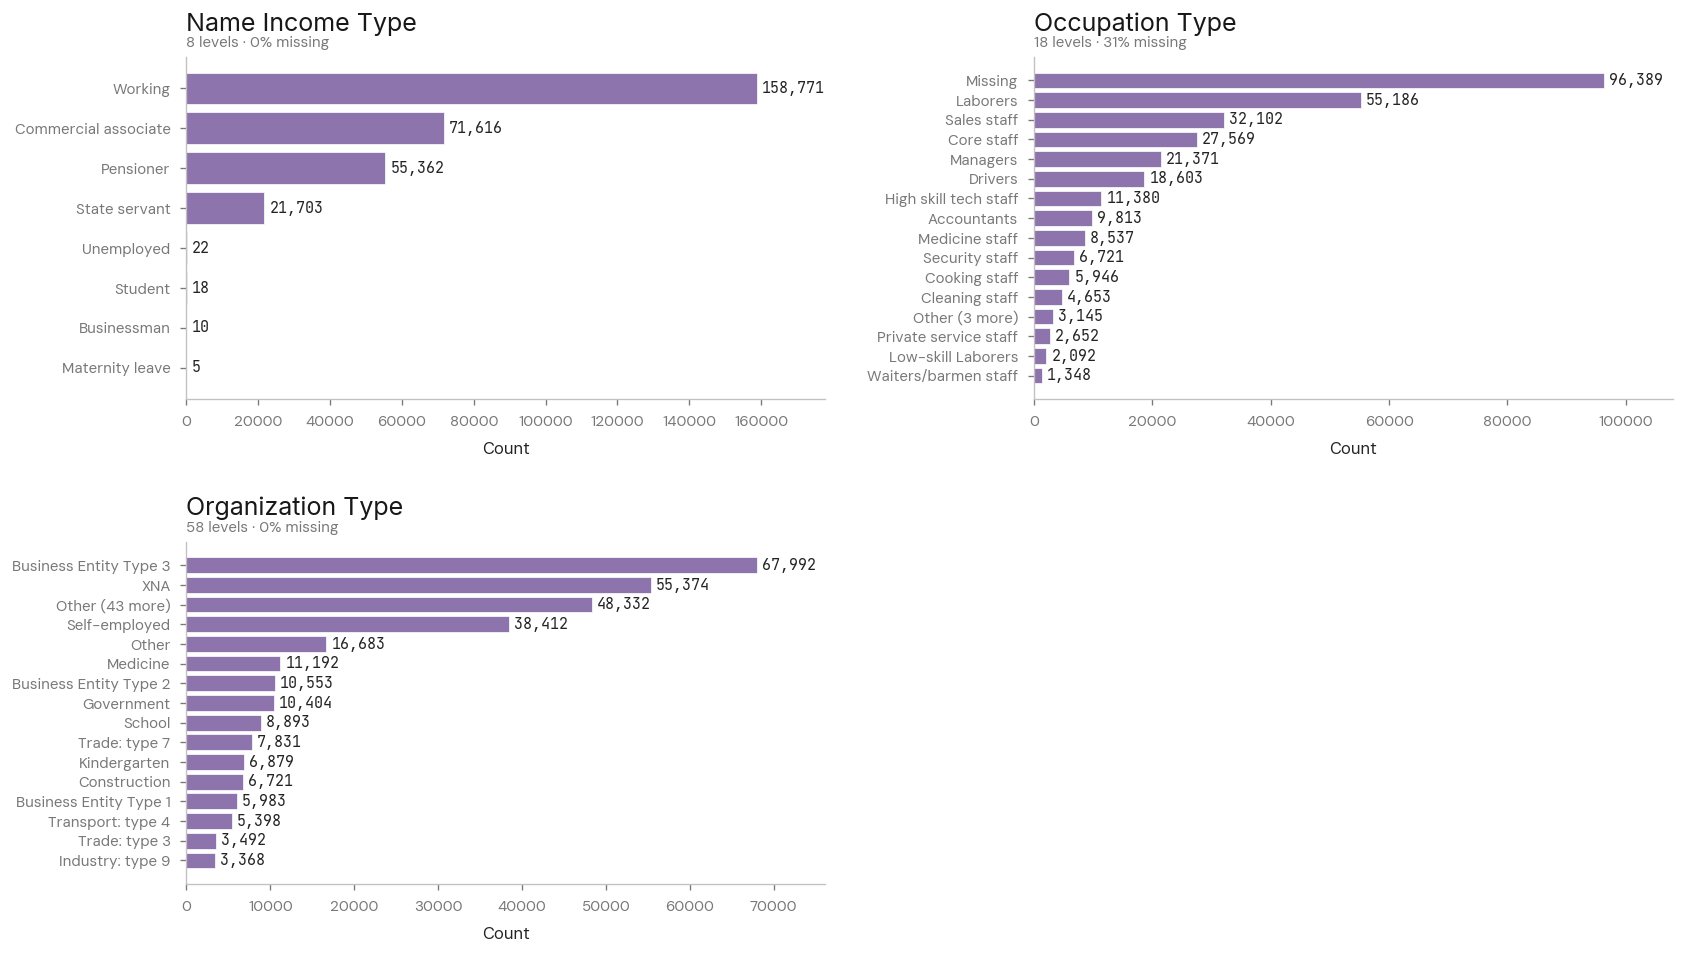

In [50]:
# Age and Employment Categorical Bar Counts

# Get 'CNT_FAM_MEMBERS' and 'CNT_CHILDREN' into separate df and convert to string

df_cat = df.copy()
convert_cat_cols = ['CNT_FAM_MEMBERS', 'CNT_CHILDREN']

df_cat[convert_cat_cols] = df[convert_cat_cols].astype(str)

cols_of_interest = cols_by_theme['employment']

eda.frequency_per_group(df_cat, cols_of_interest, color=C.primary)
plt.show()

**Observation.** After converting from negative days (`/-365.25`), AGE_YEARS spans ~21–69 and EMP_YEARS ~0–49; both are smooth. EMP_YEARS is 18% missing — the DAYS_EMPLOYED sentinel (pensioners/unemployed) correctly excluded from the tenure distribution. The employment categoricals are high-cardinality with sparse levels (see 2.4): NAME_INCOME_TYPE has extreme-risk but tiny levels (Maternity leave ~40%, Unemployed ~37%) and zero-default tiny levels (Student, Businessman); OCCUPATION_TYPE is ~31% missing; ORGANIZATION_TYPE handled via ORG_BAND.

#### Bivariate Analysis

In [51]:
# Max Values for Age in Years and Years Employed

print((df['DAYS_BIRTH'].min() / 365.25) - (df['DAYS_BIRTH'].max() / 365.25))

print((df['DAYS_EMPLOYED'].min() / 365.25) - (df['DAYS_EMPLOYED'].max() / 365.25))

-48.56947296372347
-49.040383299110196


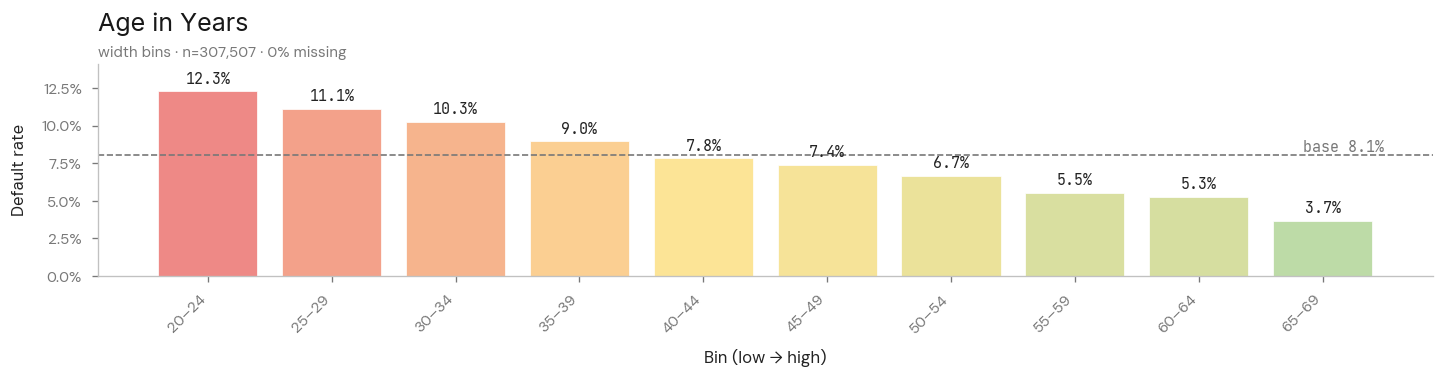

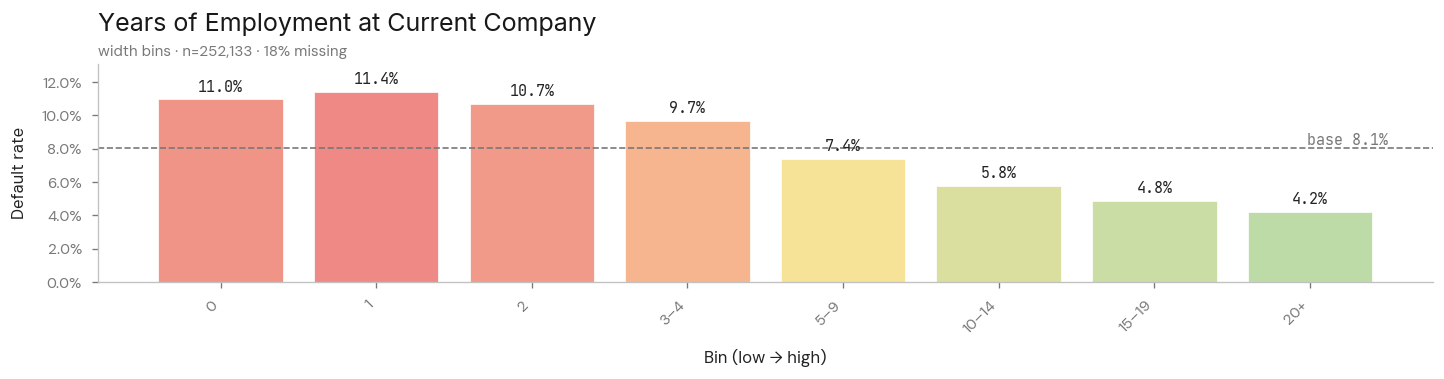

In [52]:


# AI generated function for assessing default rate by bin

from credit_utils.eda import default_rate_by_bin

# ── Age: fixed 5-year bands → 20–24, 25–29, …, 65–69 ──
fig, ax = default_rate_by_bin(
    df_age_years, ['AGE_YEARS'], target='TARGET', ncols=1,
    bins=list(range(20, 75, 5)), method='width', right=False,   # left-closed [a, b)
    bin_label='band', bin_num_fmt=lambda v: f"{v:.0f}",
    titles={'AGE_YEARS': 'Age in Years'}, panel_w=12, title_pad=20,
)
ax[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.show()

# ── Tenure: whole-year milestone bands, open-ended top → 0, 1, 2, 3–4, …, 20+ ──
fig, ax = default_rate_by_bin(
    df_age_years, ['EMP_YEARS'], target='TARGET', ncols=1,
    bins=[0, 1, 2, 3, 5, 10, 15, 20, 50], method='width', right=False,
    bin_label='band', open_top=True, bin_num_fmt=lambda v: f"{v:.0f}",
    titles={'EMP_YEARS': 'Years of Employment at Current Company'},
    panel_w=12, title_pad=20,
)
ax[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.show()

Text(0.0, 1.0, 'Name Income Type')

Text(0.5, 0, 'Default Rate')

Text(0.0, 1.0, 'Occupation Type')

Text(0.5, 0, 'Default Rate')

Text(0.0, 1.0, 'Organization Type')

Text(0.5, 0, 'Default Rate')

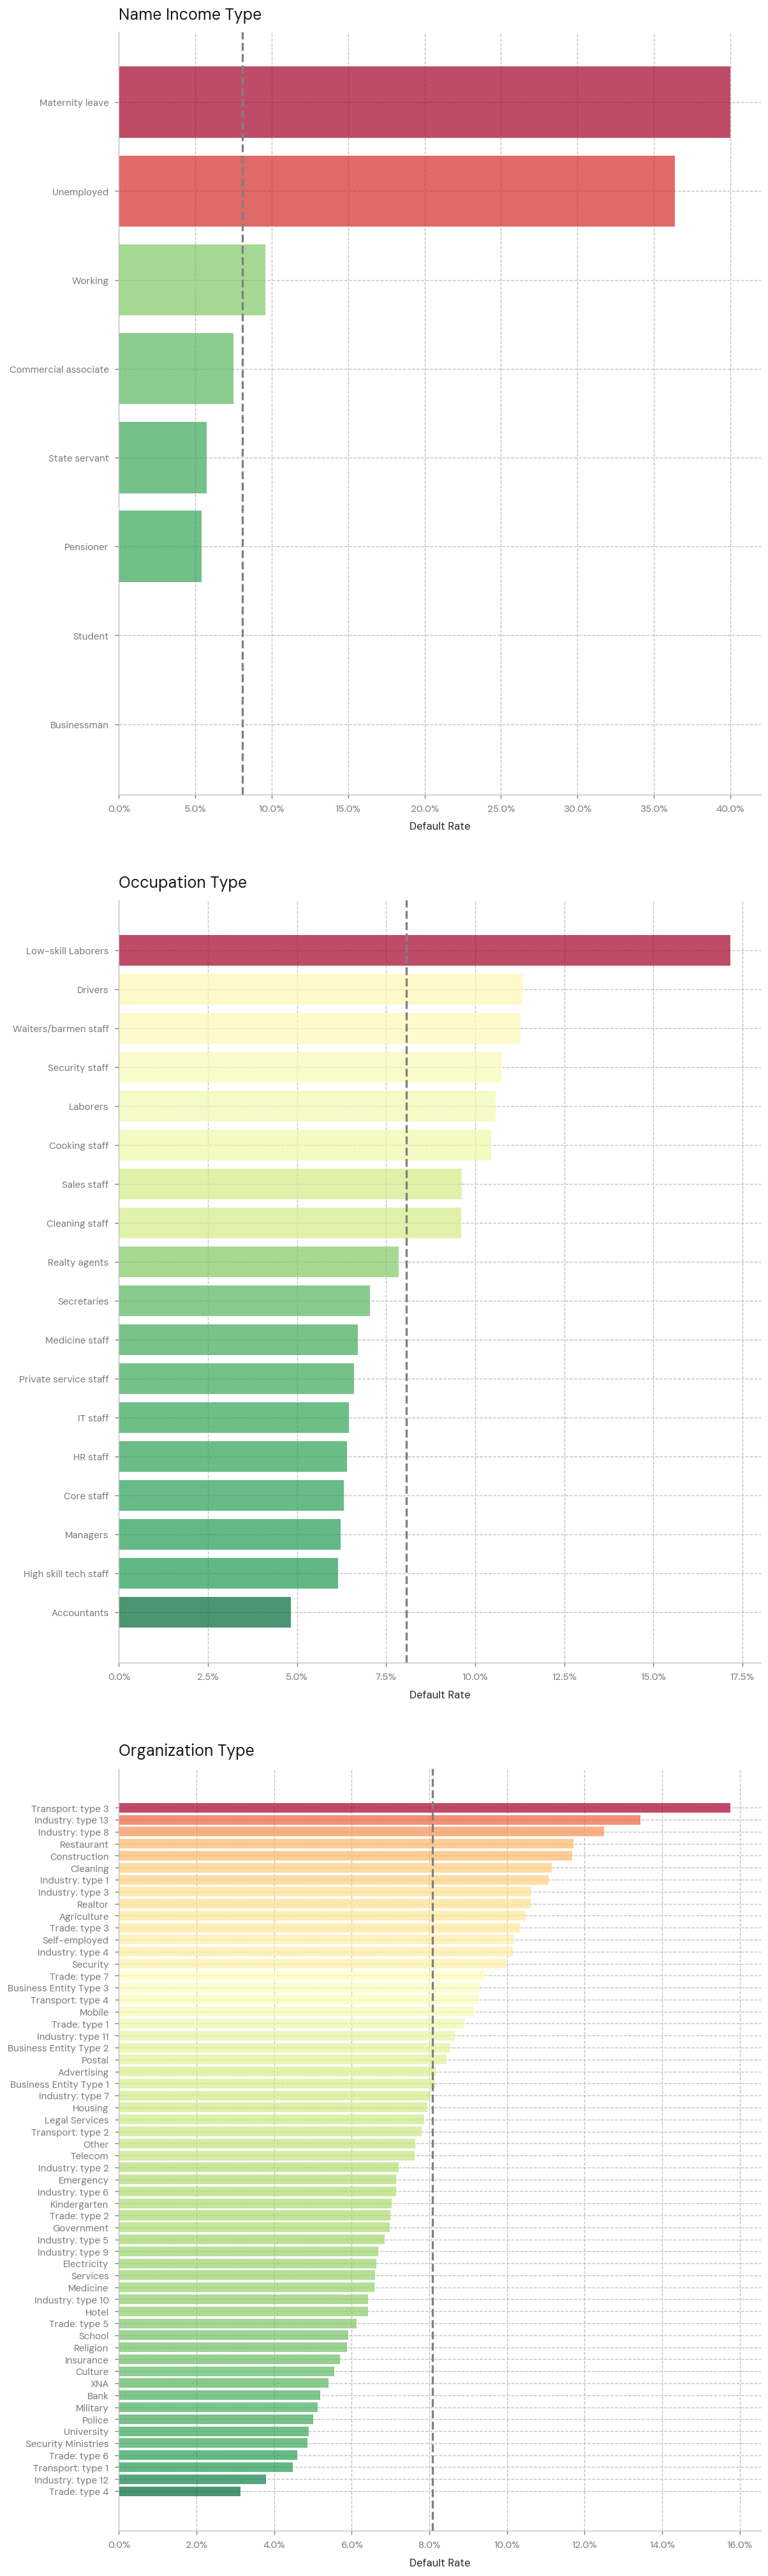

In [53]:
# Employment Default Rate by Category

cols_of_interest = cols_by_theme['employment']
cols_of_interest = [c for c in cols_of_interest if c != 'DAYS_EMPLOYED']

base = df['TARGET'].mean()

length = sum(df[col].nunique() for col in cols_of_interest)

fig, axes = plt.subplots(nrows=len(cols_of_interest), ncols=1,
                         figsize=(10, 0.4 * length))
axes = np.atleast_1d(axes).flatten()

cmap_occupation = plt.get_cmap('RdYlGn_r')   # avoid the private cm._colormaps

for ax, col in zip(axes, cols_of_interest):
    rate = df.groupby(col, observed=True)['TARGET'].mean().sort_values()

    norm = colors.Normalize(vmin=rate.min(), vmax=rate.max())
    rgba = cmap_occupation(norm(rate.values))
    rgba[:, 3] = 0.8

    bars_1 = ax.barh(rate.index.astype(str), rate.values, color=rgba, alpha=0.7)
    ax.axvline(base, ls='--', color='grey')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Default Rate')
    
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    
    # ax.bar_label(bars_1,
    #          padding=10,
    #          fmt='{:.1%}',
    #          bbox=dict(
    #              boxstyle='round',
    #              facecolor='white',
    #              edgecolor='grey',
    #              alpha = 0.8,
    #              linewidth=0.8
    #          ))

plt.show()

**Observation / Decision.** Age and tenure are strong, near-monotonic drivers: default falls from 12.3% (age 20–24) to 3.7% (65–69), and from ~11% (0–1 yr tenure) to 4.2% (20+ yr) — experience/stability proxies, so expect solid IV (well above the loan amounts). NAME_INCOME_TYPE separates sharply (Maternity leave ~40% / Unemployed ~37% vs Pensioner ~5%, Student/Businessman 0%), OCCUPATION_TYPE orders low-skill (~17%) to professional (~4.5%), ORGANIZATION_TYPE via ORG_BAND.

Key nuance: the DAYS_EMPLOYED sentinel/NaN group is heterogeneous — mostly low-risk pensioners plus high-risk unemployed — so DAYS_EMPLOYED_SENTINEL is (net) a **low-risk** flag dominated by pensioners, and NAME_INCOME_TYPE is what actually disambiguates the two.

**Decision:**
- Age & tenure → fixed domain bands (5-yr / tenure milestones) for interpretable, monotonic WOE; count-check the thin extreme bands (65–69, 20+) and merge if sparse.
- DAYS_EMPLOYED → bin tenure + keep the sentinel/missing as its own bin (informative, mostly pensioners); lean on NAME_INCOME_TYPE to split pensioner vs unemployed.
- Sparse categorical levels (Student, Businessman, Maternity leave, Unemployed) → pool before WOE (0-default → infinite WOE; tiny levels → unstable IV); pool with a level of similar default rate, enforce a min goods+bads per bin, and fit the grouping on the train split (leakage). Carry to Section 5.

### 3.4 Key Demographic Variables

**Explanation.** Key categoricals (education, family status, income type, contract type). Look at frequency and default rate per level; note sparse levels — this links back to the 2.4 cardinality treatment.

#### Univariate Analysis

(<Figure size 1680x1920 with 8 Axes>,
 array([<Axes: title={'left': 'Code Gender'}, xlabel='Count'>, <Axes: title={'left': 'Cnt Children'}, xlabel='Count'>,
        <Axes: title={'left': 'Cnt Fam Members'}, xlabel='Count'>,
        <Axes: title={'left': 'Name Family Status'}, xlabel='Count'>,
        <Axes: title={'left': 'Name Education Type'}, xlabel='Count'>,
        <Axes: title={'left': 'Name Housing Type'}, xlabel='Count'>,
        <Axes: title={'left': 'Name Type Suite'}, xlabel='Count'>, <Axes: >], dtype=object))

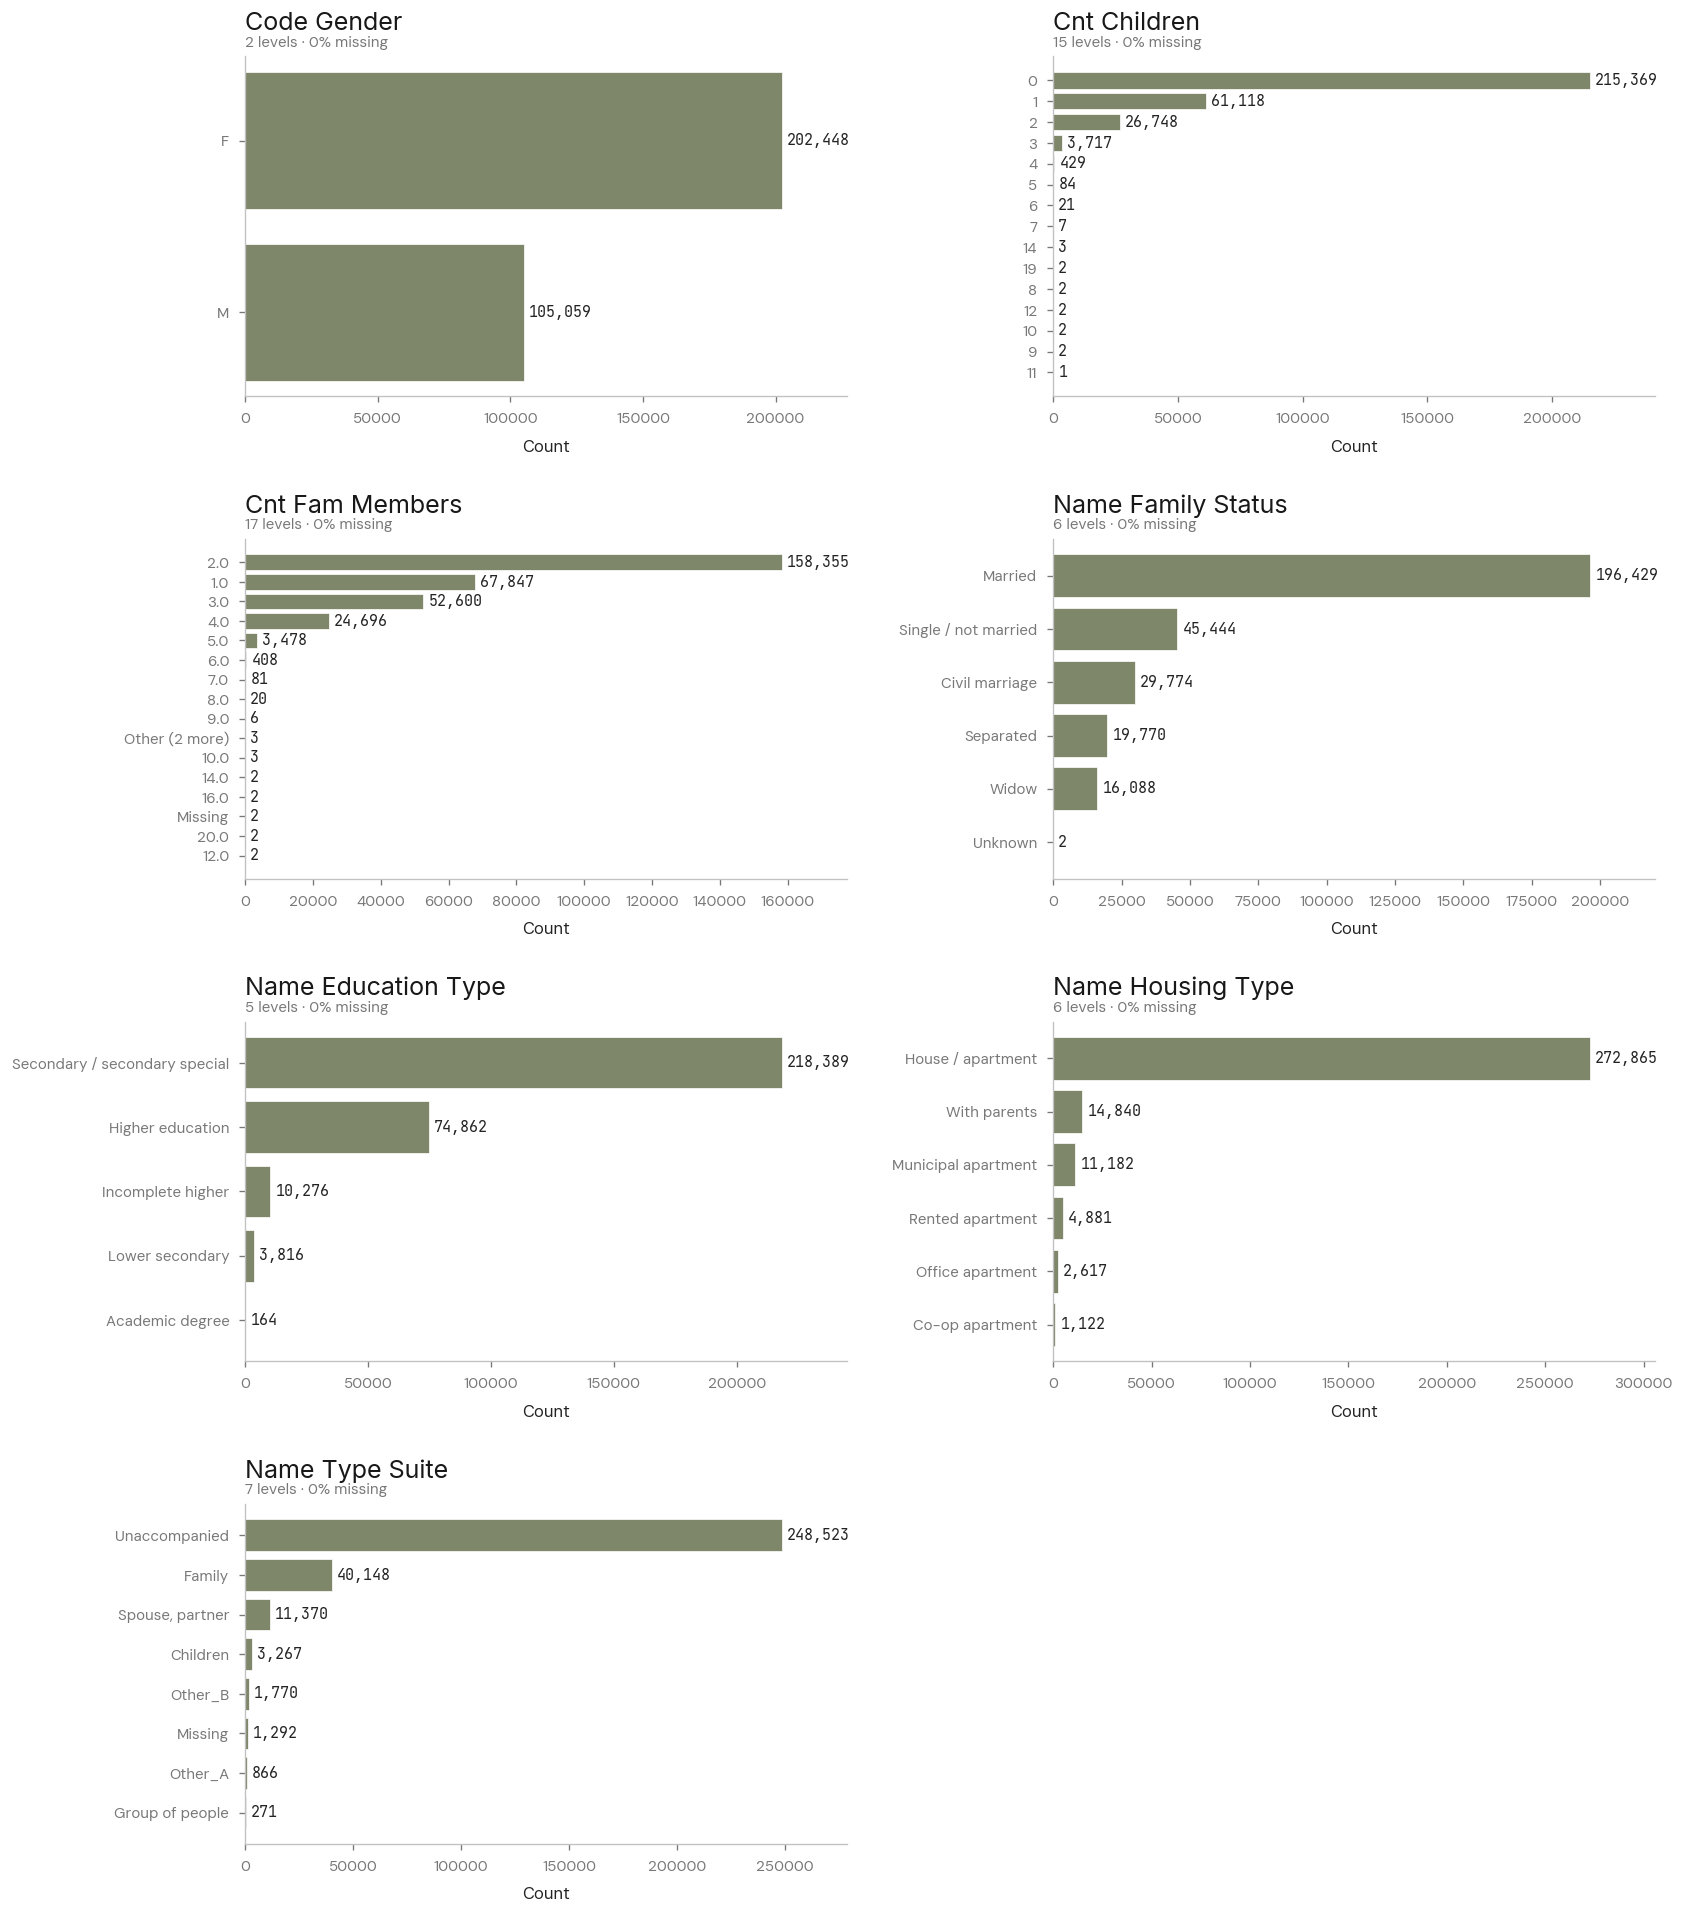

In [54]:
# Key Demographic Categorical Bar Counts

# Get 'CNT_FAM_MEMBERS' and 'CNT_CHILDREN' into separate df and convert to string

df_cat = df.copy()

convert_cat_cols = ['CNT_FAM_MEMBERS', 'CNT_CHILDREN']

df_cat[convert_cat_cols] = df[convert_cat_cols].astype(str)

cols_of_interest = cols_by_theme['demographics']

eda.frequency_per_group(df_cat, cols_of_interest, color=C.tertiary)

plt.show()

**Observation.** The demographic categoricals are mostly low-to-moderate cardinality. CODE_GENDER is binary (F ~66% / M ~34% after the XNA drop). NAME_EDUCATION_TYPE has 5 ordered levels; NAME_FAMILY_STATUS 6 (incl. a singleton 'Unknown'); NAME_HOUSING_TYPE 6; NAME_TYPE_SUITE 7 (some sparse, ~0.4% missing). CNT_CHILDREN and CNT_FAM_MEMBERS are discrete counts with long thin tails (rare high counts). The rest are effectively complete.

#### Bivariate Analysis

In [55]:
cols_by_theme['demographics']

['CODE_GENDER',
 'DAYS_BIRTH',
 'CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'NAME_FAMILY_STATUS',
 'NAME_EDUCATION_TYPE',
 'NAME_HOUSING_TYPE',
 'NAME_TYPE_SUITE']

Text(0.0, 1.0, 'Code Gender')

Text(0.5, 0, 'Default Rate')

[Text(10, 0, '7.0%'), Text(10, 0, '10.1%')]

Text(0.0, 1.0, 'Cnt Children')

Text(0.5, 0, 'Default Rate')

...

Text(0.5, 0, 'Default Rate')

[Text(10, 0, '6.6%'),
 Text(10, 0, '7.8%'),
 Text(10, 0, '7.9%'),
 Text(10, 0, '8.5%'),
 Text(10, 0, '11.7%'),
 Text(10, 0, '12.3%')]

Text(0.0, 1.0, 'Name Type Suite')

Text(0.5, 0, 'Default Rate')

[Text(10, 0, '7.4%'),
 Text(10, 0, '7.5%'),
 Text(10, 0, '7.9%'),
 Text(10, 0, '8.2%'),
 Text(10, 0, '8.5%'),
 Text(10, 0, '8.8%'),
 Text(10, 0, '9.8%')]

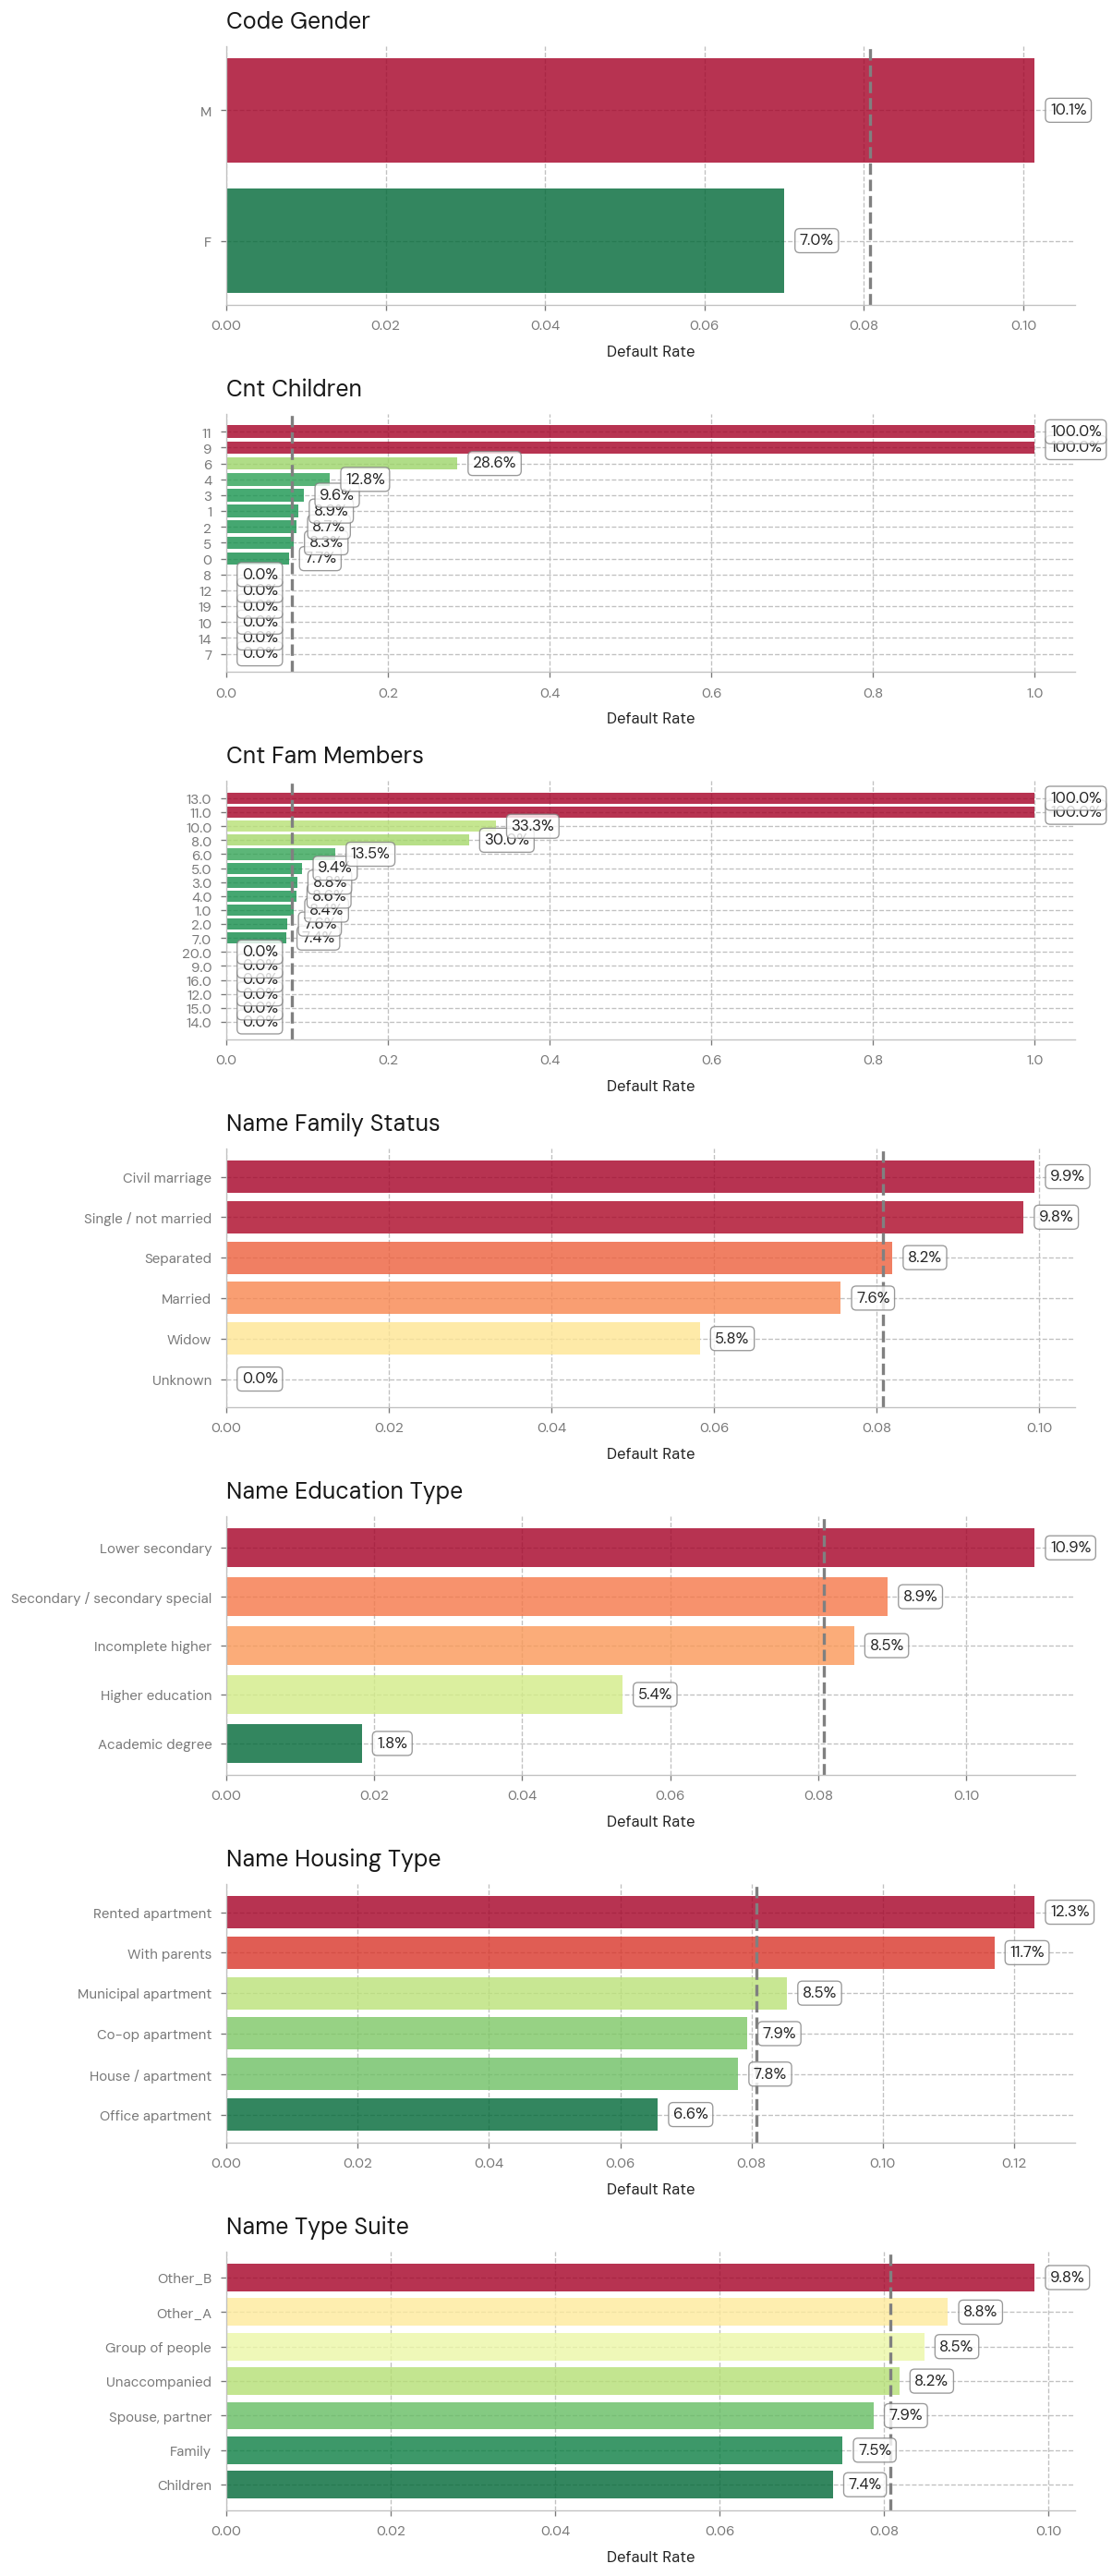

In [56]:
# Key Demographics Default Rate by Category

cols_of_interest = cols_by_theme['demographics']
cols_of_interest = [c for c in cols_of_interest if c != 'DAYS_BIRTH']


base = df['TARGET'].mean()

length = sum(df[col].nunique() for col in cols_of_interest)

fig, axes = plt.subplots(nrows=len(cols_of_interest), ncols=1,
                         figsize=(10, 0.4 * length))
axes = np.atleast_1d(axes).flatten()

cmap_occupation = plt.get_cmap('RdYlGn_r')   # avoid the private cm._colormaps

for ax, col in zip(axes, cols_of_interest):
    rate = df.groupby(col, observed=True)['TARGET'].mean().sort_values()

    norm = colors.Normalize(vmin=rate.min(), vmax=rate.max())
    rgba = cmap_occupation(norm(rate.values))
    rgba[:, 3] = 0.8

    bars_1 = ax.barh(rate.index.astype(str), rate.values, color=rgba)
    ax.axvline(base, ls='--', color='grey')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Default Rate')
    
    ax.bar_label(bars_1,
             padding=10,
             fmt='{:.1%}',
             bbox=dict(
                 boxstyle='round',
                 facecolor='white',
                 edgecolor='grey',
                 alpha = 0.8,
                 linewidth=0.8
             ))

plt.show()

**Observation / Decision.** Default rate per level: CODE_GENDER F 7.0% / M 10.1%; NAME_EDUCATION_TYPE a clean ordered gradient (Academic 1.8% → Lower secondary 10.9%); NAME_FAMILY_STATUS Widow ~5.8% → Single/Civil marriage ~9.9%; NAME_HOUSING_TYPE ~6.6% → ~12.3% (with-parents/rented highest); NAME_TYPE_SUITE narrow (7.4–9.8%, weak); CNT_CHILDREN/CNT_FAM_MEMBERS rise gently then a noisy 100%/0% tail from 1–2-applicant levels.

**Decision:**
- CODE_GENDER: **exclude from the model** (protected attribute — responsible-lending / anti-discrimination); document the exclusion and screen retained drivers for gender proxying. Keep as EDA context only.
- NAME_EDUCATION_TYPE: **ordinal** WOE in education order (expect monotonic WOE); merge the sparse Academic-degree level up if needed — strong expected driver.
- NAME_FAMILY_STATUS / NAME_HOUSING_TYPE: nominal WOE; pool sparse levels (e.g. the 'Unknown' singleton).
- CNT_CHILDREN / CNT_FAM_MEMBERS: cap the tail into a '5+' band; the two are collinear (children ⊂ family members) → keep one, drop the other at feature selection.
- NAME_TYPE_SUITE: weak, likely low IV — candidate to drop. Carry to Section 5.

### 3.5 Other Numericals

**Explanation.** Remaining numeric families (`client_timeline`, `social_circle`, `bureau_enquiries`) — a lighter touch: confirm shape and flag anything odd, given the block-wise missingness already noted in 2.3.

#### Univariate Analysis

In [ ]:
# 3.5 — light-touch scan of the remaining numeric families:
# client_timeline (days-since key events), social_circle (default counts in the
# applicant's circle), bureau_enquiries (credit-bureau enquiry counts).
other_num = (cols_by_theme['client_timeline']
             + cols_by_theme['social_circle']
             + cols_by_theme['bureau_enquiries'])

# Shape + missingness at a glance (bureau_enquiries share one ~14% missing block, 2.3).
display(df[other_num].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

fig, axes = eda.histogram_per_group(df, other_num, ncols=3, bins=50)
plt.show()

**Observation.** The three families split into distinct shapes. The `client_timeline` "days-since" features (`DAYS_REGISTRATION`, `DAYS_ID_PUBLISH`, `DAYS_LAST_PHONE_CHANGE`) are smooth, fully populated (0% missing), and skewed toward recent events with a long tail into the past. The `social_circle` counts (`OBS/DEF_30/60_CNT_SOCIAL_CIRCLE`) are heavily zero-inflated — most applicants have 0 defaulters in their circle — and ~0.3% missing. The `bureau_enquiries` counts (`AMT_REQ_CREDIT_BUREAU_*`) are also zero-inflated and share a single block of ~14% missingness (all six missing together, per 2.3).

#### Bivariate Analysis

In [ ]:
# Default rate across bins — does each family actually separate defaulters?
# EDA on the full frame (consistent with 3.1-3.4); the formal train-fit IV is in §5.
from credit_utils.eda import default_rate_by_bin

fig, axes = default_rate_by_bin(
    df, other_num, target='TARGET', ncols=3, bins=10, na_as_bin=True
)
plt.show()

**Observation.** Only `client_timeline` shows a usable gradient: default rises near-monotonically across bins for all three (e.g. `DAYS_LAST_PHONE_CHANGE` 5.4% → 9.9% — a more recent phone change reads as higher risk), all fully populated. `social_circle` is essentially flat around the 8.1% base (the coarse `DEF_30` split reaches 11.9% but on very few applicants). `bureau_enquiries` counts also hug the base rate — and the one genuinely interesting effect is in the **missing block**: the ~14% with no bureau-enquiry record default at ~10.3% vs 8.1% base, so the *missingness flag* carries more than the counts do.

**Decision.**
- **Keep + bin (baseline):** the three `client_timeline` features — weak but real signal (indicative IV ≈ 0.03–0.04), fully populated, quantile bins in §5.
- **Park (drop from baseline, logged in §7):** all `social_circle` and `bureau_enquiries` features — indicative IV < 0.02, below the Siddiqi keep threshold. Reversible: re-includable in the §5 feature list with a one-line change.
- **Parked idea for tuning:** engineer a `has_bureau_enquiry_data` missingness flag — the block-missingness (10.3% default) is more predictive than the raw enquiry counts, so a flag may earn a place where the counts don't.

## 4. Feature Engineering

**Purpose.** Derive a small set of credit-domain ratios that concentrate signal the raw `AMT_*` and `DAYS_*` columns carry only diffusely, so they enter the Section 5 WOE/IV screen as candidates in their own right. Scope is deliberately tight — a handful of well-motivated ratios, each justified — not an exhaustive ratio search.

**Why before the screen.** WOE/IV ranks whatever features exist when it runs; a ratio that isn't built can't be screened. Building them here lets the IV table in Section 5 compare engineered ratios and raw features on the same footing.

**Leakage note.** These are row-wise transforms of existing columns, so creating them on the full frame is not leakage. The train-only discipline still applies downstream: bins and WOE are fit on the training split in Section 5, never here.

### 4.1 Candidate Ratios

**Explanation.** Five ratios, each with a standard credit rationale:

| Feature | Definition | Reads as |
|---|---|---|
| `DTI` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | debt-service-to-income — affordability of the repayment |
| `CREDIT_INCOME` | `AMT_CREDIT / AMT_INCOME_TOTAL` | loan size relative to income — leverage |
| `ANNUITY_CREDIT` | `AMT_ANNUITY / AMT_CREDIT` | payment intensity — a term / burden proxy |
| `CREDIT_GOODS` | `AMT_CREDIT / AMT_GOODS_PRICE` | loan-to-value proxy — how much is financed above the good's price |
| `EMPLOYED_AGE` | `DAYS_EMPLOYED / DAYS_BIRTH` | share of life employed — job stability |

`DAYS_EMPLOYED` already has the `365243` sentinel replaced with `NaN` (§2.3), so `EMPLOYED_AGE` is `NaN` for pensioners / unemployed — carried as its own bin in Section 5 rather than imputed.

In [57]:
import numpy as np

def _safe_div(num, den):
    return num / den.replace(0, np.nan)

engineered_ratios = {
    'DTI'            : _safe_div(df['AMT_ANNUITY'],   df['AMT_INCOME_TOTAL']),
    'CREDIT_INCOME'  : _safe_div(df['AMT_CREDIT'],    df['AMT_INCOME_TOTAL']),
    'ANNUITY_CREDIT' : _safe_div(df['AMT_ANNUITY'],   df['AMT_CREDIT']),
    'CREDIT_GOODS'   : _safe_div(df['AMT_CREDIT'],    df['AMT_GOODS_PRICE']),
    'EMPLOYED_AGE'   : _safe_div(df['DAYS_EMPLOYED'], df['DAYS_BIRTH']),
}

for _name, _series in engineered_ratios.items():
    df[_name] = _series

ratio_cols = list(engineered_ratios)          # feeds the Section 5 screen
df[ratio_cols].describe().T

C:\Users\evanr\AppData\Local\Temp\ipykernel_30960\3800956251.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[_name] = _series
C:\Users\evanr\AppData\Local\Temp\ipykernel_30960\3800956251.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[_name] = _series
C:\Users\evanr\AppData\Local\Temp\ipykernel_30960\3800956251.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.conca

,count,mean,std,min,25%,50%,75%,max
DTI,307495.00,0.18,0.09,0.00,0.11,0.16,0.23,1.88
CREDIT_INCOME,307507.00,3.96,2.69,0.00,2.02,3.27,5.16,84.74
ANNUITY_CREDIT,307495.00,0.05,0.02,0.02,0.04,0.05,0.06,0.12
CREDIT_GOODS,307229.00,1.12,0.12,0.15,1.00,1.12,1.20,6.00
EMPLOYED_AGE,252133.00,0.16,0.13,-0.00,0.06,0.12,0.22,0.73


**Observation.** The five ratios behave as their definitions predict. `DTI` centres ~0.16 (median) with a thin tail to ~1.9. `CREDIT_INCOME` centres ~3.3 with a long right tail to ~85 (a few very high-leverage applications). `ANNUITY_CREDIT` is tight (0.02–0.12), a term/burden band. `CREDIT_GOODS` sits just above 1.0 (median 1.12) — most loans finance at or slightly above the good's price — with a tail to ~6. `EMPLOYED_AGE` spans 0–0.73 and is **18% NaN**: the pensioner/unemployed sentinel group (§2.3), carried as its own bin, not imputed. `CREDIT_GOODS` is only ~0.1% NaN; the income and annuity ratios are fully populated.

**Decision.** Screen all five. The fat right tails (`CREDIT_INCOME`, `CREDIT_GOODS`) don't need clipping for the screen — §5 uses quantile bins, which are rank-based and robust to outliers (see 4.3). `EMPLOYED_AGE`'s NaN is informative → missing-as-its-own-bin (see 4.4).

### 4.2 Bivariate Sanity Check

**Task.** Default-rate-by-bin for each engineered ratio — confirm each one actually separates defaulters before it earns a place in the Section 5 WOE/IV screen. Read every bin's rate against the ~8% base rate.

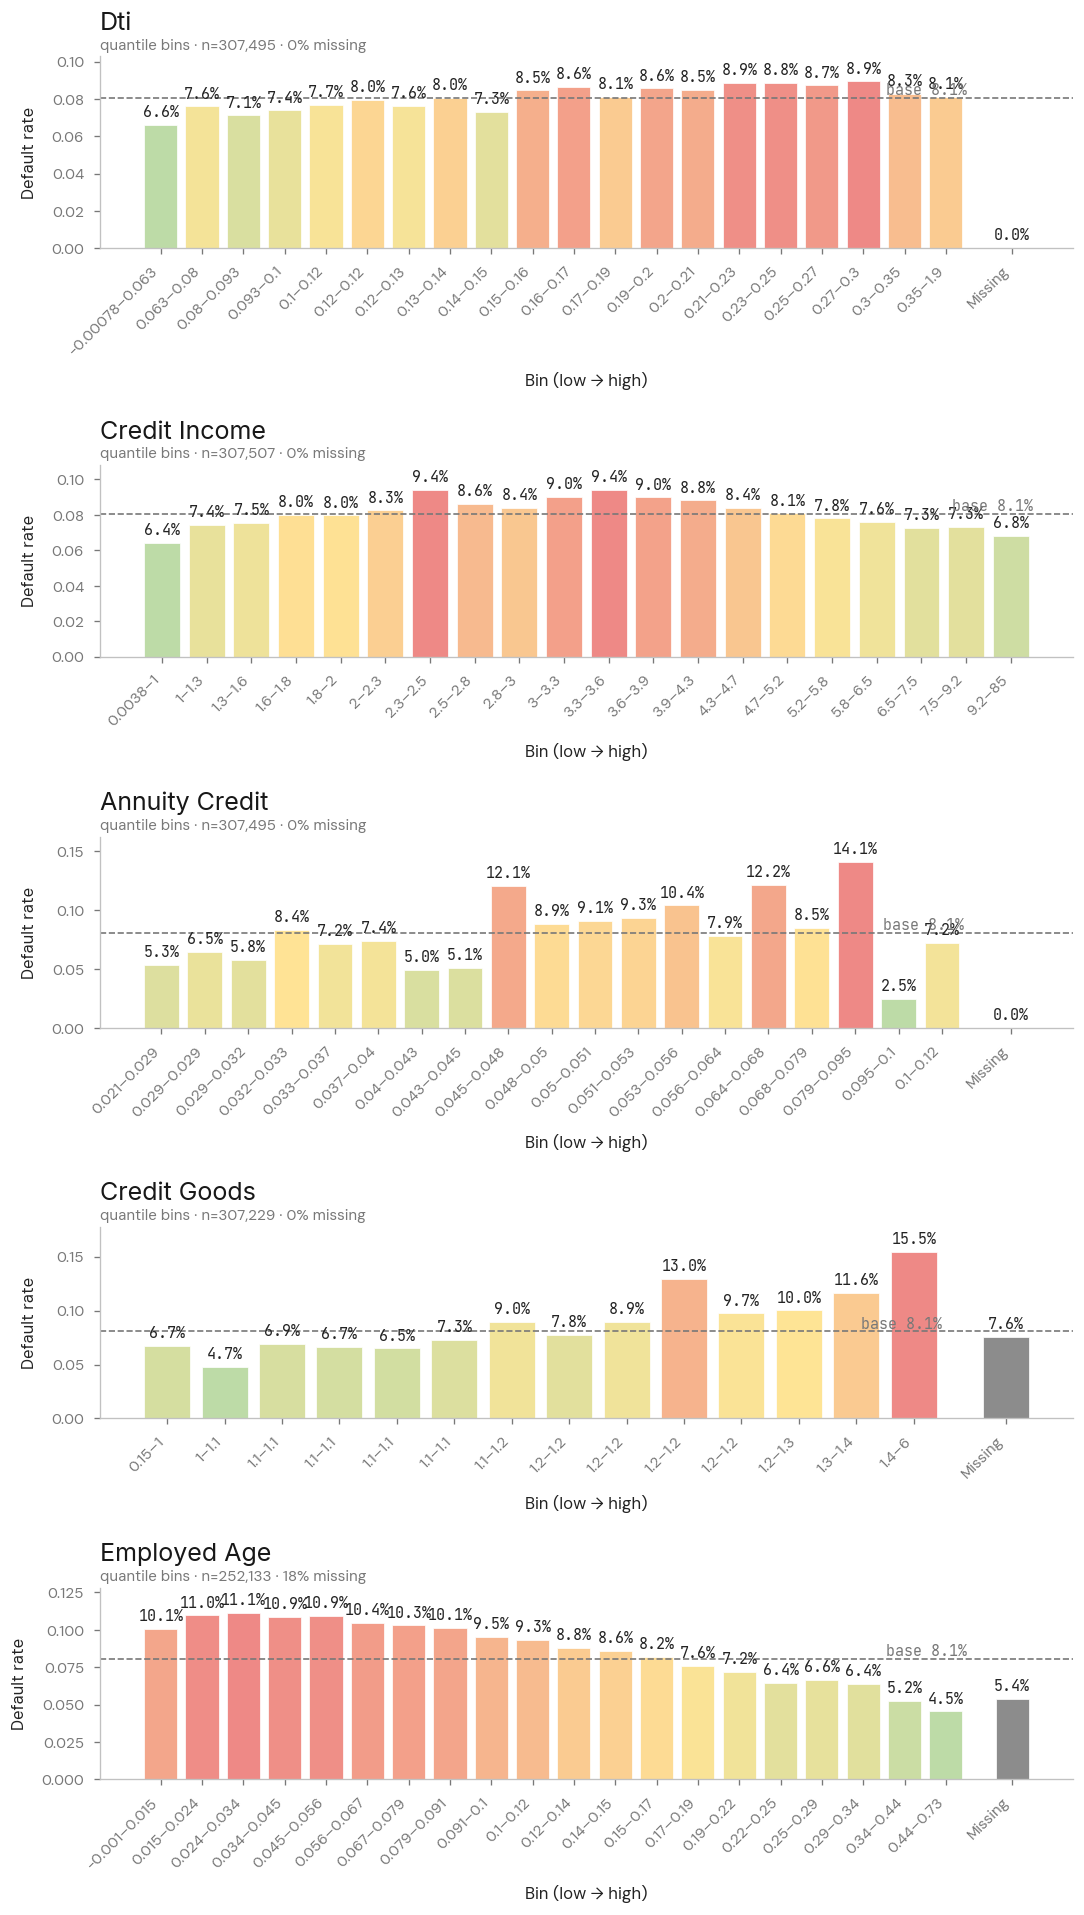

In [63]:
# Default rate across bins of each engineered ratio (same helper as §3).
from credit_utils.eda import default_rate_by_bin

fig, axes = default_rate_by_bin(
    df, ratio_cols, target='TARGET', ncols=1, bins=20, na_as_bin=True
)
plt.show()

**Observation.** Two ratios show clean, near-monotonic gradients: `EMPLOYED_AGE` falls 11% → 4.5% as the employed share of life rises (job stability — and its NaN/pensioner bin is low-risk at 5.4%), and `CREDIT_GOODS` rises 6.5% → 15.5% once the loan-to-value proxy pushes past ~1.2. `ANNUITY_CREDIT` carries real but non-monotonic signal — a threshold spike to 12–14% at the highest payment-intensity bins. The two **income-denominated** ratios are flat: `DTI` and `CREDIT_INCOME` hug the 8.1% base across every bin.

**Decision.**
- **Screen all five**, quantile-binned in §5. `EMPLOYED_AGE`, `CREDIT_GOODS`, `ANNUITY_CREDIT` are the expected keepers (indicative IV ≈ 0.07–0.09); `DTI` and `CREDIT_INCOME` are kept **deliberately despite weak signal**, so the IV table documents that income-based affordability ratios underperform here.
- **A real finding.** `DTI` — the textbook serviceability / NSR metric — is the *weakest* ratio. The likely cause is that `AMT_INCOME_TOTAL` is self-reported and noisy in this dataset, so any income-denominated ratio inherits that noise. The affordability signal instead lives in the credit-denominated ratios (`ANNUITY_CREDIT` ≈ term/burden, `CREDIT_GOODS` ≈ LTV) and in tenure (`EMPLOYED_AGE`). Worth surfacing in §6 and on the caveats slide.
- **Overlap to resolve at selection.** `CREDIT_GOODS` (IV ≈ 0.07) does not beat raw `AMT_GOODS_PRICE` (IV ≈ 0.09), and `AMT_CREDIT` ≈ `AMT_GOODS_PRICE`. Send **both** `CREDIT_GOODS` and raw `AMT_GOODS_PRICE` into the §5 screen and let feature selection drop the redundant one.

### 4.3 Outlier & Skew Treatment

**Decision: no winsorising for the screen.** The engineered ratios have fat right tails (`CREDIT_INCOME` to ~85, `CREDIT_GOODS` to ~6, `DTI` to ~1.9), but Section 5 bins every feature with **quantile (rank-based) cut-points**, which are invariant to monotonic outliers — an extreme value just lands in the top bin. Clipping would nudge bin membership at the margins without materially changing the WOE/IV screen.

**Parked for post-baseline tuning.** If a later model consumes the ratios as *raw continuous* inputs (e.g. a non-WOE gradient-boosted model, or a scorecard variant), revisit capping at the 1st–99th percentile — the tails would matter there.

### 4.4 Missing-Values Handling

No imputation for the screen — missingness is either informative (kept as its own bin) or negligible.

| Feature | Missing | Treatment |
|---|---|---|
| `EMPLOYED_AGE` | 18% | Missing-as-own-bin. The NaN group is the pensioner / unemployed sentinel (§2.3) and is genuinely low-risk (5.4% default) — informative, not imputed. |
| `CREDIT_GOODS` | ~0.1% | Missing-as-own-bin (trivial group; `AMT_GOODS_PRICE` absent). |
| `DTI`, `CREDIT_INCOME`, `ANNUITY_CREDIT` | 0% | None needed. |

WOE encoding in §5 treats each "Missing" bin like any other level, so an informative-missing feature keeps its signal rather than being dropped or mean-imputed.

## 5. WOE/IV Computation

**Purpose.** Turn the binning decisions from Section 3 into two things: a ranked view of *which* features drive default (**Information Value**), and model-ready **Weight of Evidence** encodings of those features. IV answers "how predictive?"; WOE is the monotonic re-expression a scorecard/logit consumes.

**Approach.** Hand-roll the WOE/IV mechanic first so the numbers aren't a black box, then optionally cross-check with `optbinning`. Bins and WOE values are derived on the **training split only** and applied to validation/test — fitting on the full data leaks the target.

**Leakage guards.**
- Exclude id columns (`SK_ID_CURR`) before ranking — a unique key yields spurious near-infinite IV.
- Carry the Section 3 Decisions (transforms, missing-as-its-own-bin) into the binning here rather than re-deciding.

Rhythm: **Predict → Task → Decision**, each Decision pointing forward to preprocessing/modelling.

### 5.1 Split & Binning Inputs

**Task.** Create the train/validation split (stratified on `TARGET`) and assemble the binned feature frame from the Section 3 decisions. Everything downstream fits on train, applies to val.

In [59]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, train_size=0.8, random_state=42, stratify=df["TARGET"])

In [ ]:
# §5.1 — ORG_BAND, fit on TRAIN only, applied to train/val (no leakage).
# Rate-bands are learned from train default rates, then .map()'d onto both splits,
# so validation never sees its own target when the bands are defined.

def fit_org_bands(train_df, col='ORGANIZATION_TYPE', target='TARGET',
                  edges=(0, 0.06, 0.08, 0.10, 1.0),
                  labels=('<6%', '6-8%', '8-10%', '>10%'),
                  keep_solo_min_count=500, solo_rate=0.10):
    """Learn {organisation_type -> band} from the TRAIN split only."""
    rate   = train_df.groupby(col)[target].mean()
    counts = train_df[col].value_counts()
    band = pd.cut(rate, bins=list(edges), labels=list(labels)).astype('object')
    hi = (rate > solo_rate) & (counts >= keep_solo_min_count)   # big high-risk levels stay solo
    band[hi] = rate.index[hi]
    return band.to_dict()

org_band_map = fit_org_bands(train)

# Apply to both splits; any org unseen in train folds into the base '8-10%' band.
BASE_BAND = '8-10%'
train['ORG_BAND'] = train['ORGANIZATION_TYPE'].map(org_band_map).fillna(BASE_BAND)
test['ORG_BAND']  = test['ORGANIZATION_TYPE'].map(org_band_map).fillna(BASE_BAND)

print("ORG_BAND levels (train):", train['ORG_BAND'].nunique())
train['ORG_BAND'].value_counts()

### 5.2 WOE / IV Helper

**Task.** One function: given a *binned* feature and the target, return the per-bin WOE table and the feature's total IV. Fit on train only.

WOE per bin = ln( (%goods in bin) / (%bads in bin) ). IV = Σ (%goods − %bads) × WOE. Add a small epsilon so empty bins don't divide by zero.

IV rule of thumb (Siddiqi): <0.02 unpredictive · 0.02–0.1 weak · 0.1–0.3 medium · 0.3–0.5 strong · >0.5 suspiciously strong → check for leakage.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def fit_bins(train_series, bins=10):
    """Learn quantile bin EDGES from the TRAIN series only.

    Returns edges with open ends (-inf / +inf) so that any val value beyond the
    train range still lands in the first/last bin instead of becoming NaN. Pass
    these edges to calc_woe_iv(..., edges=...) so validation is binned on the
    train cut-points, never re-quantiled on itself.
    """
    _, edges = pd.qcut(train_series, q=bins, duplicates="drop", retbins=True)
    edges = edges.copy()
    edges[0], edges[-1] = -np.inf, np.inf
    return edges


def calc_woe_iv(
    df: pd.DataFrame,
    feature: str,
    target: str,
    bins: int = 10,
    is_categorical: bool = False,
    edges=None,
    na_label: str = "Missing",
) -> tuple[pd.DataFrame, float]:
    """
    Compute Weight of Evidence (WOE) and Information Value (IV) for one
    feature against a binary target.

    Convention: target == 1 is BAD (default), target == 0 is GOOD.
    WOE = ln(dist_good / dist_bad); positive = lower risk, negative = higher.

    Train/val discipline
    --------------------
    * is_categorical -> raw levels are the bins; NaN becomes its own `na_label`.
    * numeric + edges is None -> bins are fit on THIS df via qcut (use on train).
    * numeric + edges given  -> THIS df is cut on those pre-fit edges (use on val
      with edges from fit_bins(train[feature])). Missing values are carried as
      their own `na_label` bin, so an informative-missing column is never dropped.

    Returns (woe_table, iv).
    """
    d = df[[feature, target]].copy()

    if is_categorical:
        d["bucket"] = d[feature].astype("object").fillna(na_label)
    elif edges is not None:
        b = pd.cut(d[feature], bins=edges)
        d["bucket"] = b.cat.add_categories([na_label]).fillna(na_label)
    else:
        b = pd.qcut(d[feature], q=bins, duplicates="drop")
        d["bucket"] = b.cat.add_categories([na_label]).fillna(na_label)

    g = d.groupby("bucket", observed=False)[target].agg(["count", "sum"])
    g.columns = ["total", "bad"]
    g["good"] = g["total"] - g["bad"]
    g = g[g["total"] > 0]                       # drop empty bins (unused categories)

    total_good, total_bad = g["good"].sum(), g["bad"].sum()
    g["dist_good"] = (g["good"] / total_good).replace(0, 1e-6)
    g["dist_bad"] = (g["bad"] / total_bad).replace(0, 1e-6)

    g["woe"] = np.log(g["dist_good"] / g["dist_bad"])
    g["iv_bin"] = (g["dist_good"] - g["dist_bad"]) * g["woe"]
    g["bad_rate"] = g["bad"] / g["total"]

    return g.reset_index(), g["iv_bin"].sum()


def plot_woe(woe_table: pd.DataFrame, feature: str, iv: float | None = None, ax=None):
    """
    Horizontal diverging bar chart of a WOE table - one bar per bin.
    Red = riskier than average (negative WOE), teal = safer (positive WOE).
    """
    t = woe_table.iloc[::-1].reset_index(drop=True)  # first bin plots on top
    labels = t["bucket"].astype(str)
    values = t["woe"]
    colors = ["#D1495B" if v < 0 else "#2A9D8F" for v in values]

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 0.55 * len(t) + 1.2))

    bars = ax.barh(labels, values, color=colors, height=0.6, zorder=3)

    span = max(abs(values.min()), abs(values.max()), 1e-6)
    inset = 0.05 * span
    for bar, v in zip(bars, values):
        x = bar.get_width() - inset if v >= 0 else bar.get_width() + inset
        ha = "right" if v >= 0 else "left"
        ax.text(x, bar.get_y() + bar.get_height() / 2, f"{v:+.2f}",
                 va="center", ha=ha, fontsize=9, fontweight="bold", color="white")

    ax.axvline(0, color="#94a3b8", linewidth=1)
    ax.set_xlabel("WOE  (← higher risk        lower risk →)")
    title = f"WOE by bin — {feature}"
    if iv is not None:
        title += f"   (IV = {iv:.3f})"
    ax.set_title(title, fontsize=12, fontweight="bold", loc="left")
    ax.spines[["top", "right", "left"]].set_visible(False)
    return ax

### 5.3 IV Across All Features

**Task.** Loop the binned features, collect each IV, build a table sorted high→low. This is the cross-feature ranking that used to live in the old "Target Relationship Scan".

**Observation:** _<fill after running — where does the IV cliff fall? any suspiciously-high features to leakage-check?>_

### 5.4 Top 10 Drivers

**Task.** The payoff table — top 10 features by IV, styled. Feeds the narrative in Section 6.

**Observation:** _<name the strongest drivers; sanity-check against the Section 3 bivariate reads>_

**Decision:** _<which features carry into modelling; anything dropped for low IV or leakage>_

In [61]:
# from python_style_util import style_df
# style_df(iv_table.head(10), gradient_cols=['IV'], gradient_cmap='Purples')


### 5.5 WOE Encoding

**Task.** Apply the train-fit WOE maps to produce WOE-transformed train/val frames for modelling. Same discipline as imputation: fit on train, `transform` val/test — never refit on val.

**Decision:** _<confirm WOE frames are the modelling input; note storage of the bin→WOE maps for scoring>_

In [62]:
# woe_maps = {}                          # {feature: {bin: woe}} learned on train
# for col in kept_features:
#     tbl, _ = woe_iv(X_train_binned[col], y_train)
#     woe_maps[col] = tbl['woe'].to_dict()
#
# def apply_woe(frame_binned, maps):
#     out = pd.DataFrame(index=frame_binned.index)
#     for col, m in maps.items():
#         out[col] = frame_binned[col].map(m)
#     return out
#
# X_train_woe = apply_woe(X_train_binned, woe_maps)
# X_val_woe   = apply_woe(X_val_binned,   woe_maps)   # applied, not refit


### 5.6 Cross-check with `optbinning` _(optional)_

Once the manual version is trusted, `OptimalBinning` gives monotonic/optimal bins plus IV out of the box and a sklearn `fit`/`transform` API. Use it to validate the hand-rolled IVs land in the same ballpark, not to replace the understanding.

```python
from optbinning import OptimalBinning
ob = OptimalBinning(name=col, dtype='numerical')
ob.fit(X_train[col].values, y_train.values)   # train only
ob.binning_table.build()                       # WOE + IV table
```

## 6. Findings Summary

*(Placeholder — write this last, once the Section 5 IV ranking is final. Goal: a stand-alone summary an auditor can read without scrolling the whole notebook.)*

**Headline drivers.** *&lt;top features by IV, each with the direction of the relationship and a one-line business read&gt;*

**Data-quality conclusions.** *&lt;disguised nulls handled (DAYS_EMPLOYED = 365243, CODE_GENDER = XNA); block-wise missingness groups (building_stats / social_circle / bureau_enquiries) and the mechanism concluded for each (MAR / MNAR)&gt;*

**Segment insights.** *&lt;any applicant segments carrying elevated default rate worth flagging&gt;*

**Modelling implications.** *&lt;which features carry forward, which are dropped and why (low IV / leakage), and the binning/encoding decisions locked in for Section 5&gt;*


## 7. Next Steps

*(Placeholder — concrete, checkable actions rather than prose.)*

- [ ] *&lt;feature engineering to carry into modelling — engineered ratios, sentinel / missing flags, collapsed building_stats triplets&gt;*
- [ ] *&lt;binning / WOE decisions still open from Section 3 (e.g. treat-missing-as-its-own-bin choices)&gt;*
- [ ] *&lt;open questions / validation checks — leakage check on suspiciously-high-IV features, monotonicity of default rate across bands&gt;*
- [ ] *&lt;items still outstanding on the Pre-Submission Fix List at the top of the notebook&gt;*


## 8. Assumptions, Limitations & Data Lineage

*(Placeholder — the section a model-validation reviewer specifically looks for. Keep it honest and specific.)*

**Key assumptions.** *&lt;e.g. application_train is representative of the through-the-door population; the TARGET definition of default; single-table scope for this EDA stage&gt;*

**Limitations & caveats.** *&lt;known biases, sampling, features excluded, any high-missingness features retained on caveat, anything the analysis could not resolve&gt;*

**Data lineage.** *&lt;source table(s) and snapshot / version date; row & column counts as loaded; rows dropped (e.g. 4 CODE_GENDER = XNA); transforms applied before analysis&gt;*

**Scope boundary.** *&lt;what is intentionally deferred to later stages — modelling, calibration, out-of-time validation&gt;*
